In [256]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

sys.path.insert(0, str(Path.cwd().parent))

from config import config
from data_loader.torch_dataloader import (
    Luna25BlockDataset,
    PatchExtractor,
    build_dataloader,
    clip_and_scale,
    get_device,
    voxel_to_world,
    world_to_voxel,
)
from domain_utils.medical_criteria import nodule_morphometry
from domain_utils.nodule_match import emparejar_nodulos
from domain_utils.visualizer_3d import explore_mask
from utils.bivaraite_boxplot import plot_segmented_boxplot
from utils.cat_num_dep import hub_pruebas_num_cat
from utils.fancy_barplot import fancy_bars
from utils.fancy_hist import fancy_hist
from utils.segmented_bars import segmented_bars
from utils.target_against_features import test_features_against_target
from utils.triple_plot import normality_report
from utils.vif_resume import vif_table
from utils.mutual_inf_plot import analizar_relevancia_caracteristicas

# Build the inital DataFrames

In [146]:
labels = pd.read_csv(config.LUNA25_LABELS)

In [147]:
data_nodules = pd.read_csv(
    config.NLST_CSVS / "nlst_780_ctab_idc_20210527.csv"
)  # info del nodulo

In [148]:
data_patients = pd.read_csv(
    config.NLST_CSVS / "nlst_780_prsn_idc_20210527.csv"
)  # info del paciente

In [149]:
# filas = []
# for ruta in sorted(config.NODULE_METADATA_DIR.glob("*.npy")):
#     m = np.load(ruta, allow_pickle=True).item()

#     spacing   = np.asarray(m["spacing"], dtype=float)    # (z, y, x) en mm
#     origin    = np.asarray(m["origin"], dtype=float)     # (z, y, x) en mm
#     transform = np.asarray(m["transform"], dtype=float)  # 3x3

#     filas.append({
#         "AnnotationID": ruta.stem,
#         "spacing_z": spacing[0],
#         "spacing_y": spacing[1],
#         "spacing_x": spacing[2],
#         "anisotropia": spacing[0] / spacing[1],
#         "origin_z": origin[0],
#         "origin_y": origin[1],
#         "origin_x": origin[2],
#         "transform_identidad": np.allclose(transform, np.eye(3)),
#     })

# meta = pd.DataFrame(filas)

# print(f"anotaciones: {len(meta)}")
# print(f"claves del dict: {list(m.keys())}")
# print(f"transform no identidad: {(~meta.transform_identidad).sum()}")
# print()
# print(meta[["spacing_z", "spacing_y", "spacing_x", "anisotropia"]].describe()) # noqa: E501

# meta.head()

# Cross information between nodules, patients and labels

## Verificar key de cruce

In [150]:
data_patients["gender"].unique()

array([1, 2])

In [151]:
data_nodules.columns

Index(['sct_ab_desc', 'sct_ab_num', 'sct_epi_loc', 'sct_long_dia',
       'sct_margins', 'sct_perp_dia', 'sct_pre_att', 'study_yr',
       'sct_slice_num', 'sct_found_after_comp', 'pid', 'dataset_version'],
      dtype='str')

In [152]:
labels["Gender"]

0         Male
1       Female
2         Male
3         Male
4       Female
         ...  
6158    Female
6159    Female
6160    Female
6161      Male
6162      Male
Name: Gender, Length: 6163, dtype: str

In [153]:
print("Ejemplo PatientID en LUNA:", labels["PatientID"].head().tolist())
print("Ejemplo pid en NLST:", data_nodules["pid"].head().tolist())

Ejemplo PatientID en LUNA: [100570, 106364, 127302, 128899, 215816]
Ejemplo pid en NLST: [100002, 100002, 100002, 100004, 100004]


In [154]:
# 1. Copia de trabajo de labels
df_labels = labels.copy()

# 2. Asegurar que el ID del paciente esté en el mismo formato
# (entero o string limpio)
df_labels["pid"] = (
    df_labels["PatientID"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)
data_patients["pid"] = data_patients["pid"].astype(int)

# 3. Mapear 'Gender' de LUNA25 al formato de NLST si es necesario
# NLST suele usar 1 para Male y 2 para Female (o 'M' / 'F').
# Ajustamos según corresponda:
gender_map = {"M": 1, "F": 2, "Male": 1, "Female": 2, 1: 1, 2: 2}
df_labels["gender_norm"] = df_labels["Gender"].map(gender_map)
data_patients["gender_norm"] = data_patients["gender"].map(gender_map)

# 4. Hacer el merge por el identificador del paciente ('pid')
df_merged = pd.merge(
    df_labels[["PatientID", "pid", "Age_at_StudyDate", "gender_norm"]],
    data_patients[["pid", "age", "gender_norm"]],
    on="pid",
    how="inner",
    suffixes=("_luna", "_nlst"),
)

# 5. Evaluar coincidencias de Edad y Género
df_merged["match_age"] = df_merged["Age_at_StudyDate"] == df_merged["age"]
df_merged["match_gender"] = (
    df_merged["gender_norm_luna"] == df_merged["gender_norm_nlst"]
)
df_merged["match_both"] = df_merged["match_age"] & df_merged["match_gender"]

# 6. Reporte de resultados
total_coincidencias = len(df_merged)
coinciden_edad = df_merged["match_age"].sum()
coinciden_genero = df_merged["match_gender"].sum()
coinciden_ambos = df_merged["match_both"].sum()

print(f"Total de registros cruzados por ID: {total_coincidencias}")
print(
    f"Coinciden en Edad: {coinciden_edad} ({coinciden_edad / total_coincidencias * 100:.2f}%)"  # noqa: E501
)
print(
    f"Coinciden en Género: {coinciden_genero} ({coinciden_genero / total_coincidencias * 100:.2f}%)"  # noqa: E501
)
print(
    f"Coinciden en Ambos: {coinciden_ambos} ({coinciden_ambos / total_coincidencias * 100:.2f}%)"  # noqa: E501
)

# Mostrar las primeras filas con discrepancias (si existen)
discrepancias = df_merged[~df_merged["match_both"]]
if not discrepancias.empty:
    print("\n--- Ejemplo de registros con discrepancias ---")
    print(
        discrepancias[
            [
                "pid",
                "Age_at_StudyDate",
                "age",
                "gender_norm_luna",
                "gender_norm_nlst",
            ]
        ].head()
    )

Total de registros cruzados por ID: 6163
Coinciden en Edad: 2116 (34.33%)
Coinciden en Género: 6163 (100.00%)
Coinciden en Ambos: 2116 (34.33%)

--- Ejemplo de registros con discrepancias ---
      pid  Age_at_StudyDate  age  gender_norm_luna  gender_norm_nlst
2  127302                61   60                 1                 1
3  128899                64   62                 1                 1
7  215969                60   58                 1                 1
8  112235                65   64                 1                 1
9  112235                66   64                 1                 1


pequeñas discrepancias en la edad (p. ej., una diferencia de 1 o 2 años), esto se debe a que `Age_at_StudyDate` en LUNA25 registra la edad exacta del paciente en el momento en que se tomó la tomografía en un año específico (`study_yr` 0, 1 o 2), mientras que la columna `age` en `data_patients` registra la edad inicial de ingreso al ensayo (baseline age).

**El resultado confirma con un 100% de coincidencia en género que los pacientes mapeados por el pid son exactamente los mismos en ambas bases de datos.**

In [155]:
# La edad del estudio debe ser igual o hasta 2 años mayor que la edad base
df_merged["valid_age_range"] = (
    df_merged["Age_at_StudyDate"] >= df_merged["age"]
) & (df_merged["Age_at_StudyDate"] <= df_merged["age"] + 2)

porcentaje_valido = (df_merged["valid_age_range"].sum() / len(df_merged)) * 100
print(
    f"Coincidencia considerando rondas de estudio (0-2 años): {porcentaje_valido:.2f}%"  # noqa: E501
)

Coincidencia considerando rondas de estudio (0-2 años): 100.00%


## Hacer el cruce

In [156]:
# 1. Preparar copias de trabajo
df_labels = labels.copy()
df_nodules = data_nodules.copy()
df_patients = data_patients.copy()

# 2. Normalizar el formato del ID del paciente ('pid')
df_labels["pid"] = (
    df_labels["PatientID"].astype(str).str.extract(r"(\d+)")[0].astype(int)
)
df_nodules["pid"] = df_nodules["pid"].astype(int)
df_patients["pid"] = df_patients["pid"].astype(int)

# 3. Calcular el año de estudio (study_yr: 0, 1, 2) en LUNA25
# Se obtiene la edad base del paciente de forma temporal solo para los de LUNA
df_labels = df_labels.merge(df_patients[["pid", "age"]], on="pid", how="left")
df_labels["study_yr"] = df_labels["Age_at_StudyDate"] - df_labels["age"]
df_labels.drop(columns=["age"], inplace=True)

df_nodules["study_yr"] = df_nodules["study_yr"].astype(int)

# 4. PRIMER CRUCE: cada nódulo de LUNA25 con SU PROPIA anomalía de NLST.
# No se puede cruzar solo por (pid, study_yr): LUNA25 tiene una fila por
# nódulo y ctab una por anomalía, así que ese cruce le daría a todos los
# nódulos del mismo paciente-año los mismos descriptores. emparejar_nodulos
# hace una asignación uno a uno usando lateralidad (CoordX vs el lóbulo) y
# altura anatómica (CoordZ vs sct_slice_num). Ver utils/nodule_match.py.
df_consolidado, reporte_cruce = emparejar_nodulos(
    df_labels,
    df_nodules,
    devolver_reporte=True,
)

# 5. SEGUNDO MERGE: Agregar la información del Paciente (NLST)
# how='left' mantiene el filtro estricto de solo pacientes en LUNA25
df_consolidado = pd.merge(
    df_consolidado,
    df_patients,
    on="pid",
    how="left",
    suffixes=("", "_patient_df"),
)

# Validaciones de control de calidad
pacientes_unicos_luna = df_labels["pid"].nunique()
pacientes_unicos_final = df_consolidado["pid"].nunique()

print(f"Pacientes únicos en LUNA25: {pacientes_unicos_luna}")
print(f"Pacientes únicos en el DataFrame final: {pacientes_unicos_final}")
print(f"Total de registros/filas en el df consolidado: {len(df_consolidado)}")
print("\nCalidad del emparejamiento nódulo <-> anomalía:")
print(reporte_cruce)

# Ningún nódulo comparte anomalía con otro del mismo paciente-año
_ok = df_consolidado[df_consolidado["match_estado"] == "ok"]
_rep = (
    _ok.groupby(["pid", "study_yr"])["sct_ab_num"]
    .apply(lambda s: s.duplicated().any())
    .sum()
)
print(f"Grupos con una anomalía repetida entre nódulos: {_rep} (debe ser 0)")

Pacientes únicos en LUNA25: 2120
Pacientes únicos en el DataFrame final: 2120
Total de registros/filas en el df consolidado: 6163

Calidad del emparejamiento nódulo <-> anomalía:
               filas  porcentaje
match_estado                    
ok              6002       97.39
sin_candidato    104        1.69
sin_lado          57        0.92
Grupos con una anomalía repetida entre nódulos: 0 (debe ser 0)


In [157]:
len(df_labels["PatientID"].unique())

2120

In [158]:
df_consolidado.head()

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,...,can_scr,canc_rpt_link,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed,gender_norm
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,...,1,1,2011.02.03/05.12.21,37.0,NaN,NaN,69.0,0,110.0,1
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,...,1,1,2011.02.03/05.12.21,0.0,NaN,NaN,73.0,0,110.0,2
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,...,1,1,2011.02.03/05.12.21,15.0,460.0,NaN,499.0,393,110.0,1
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,...,1,1,2011.02.03/05.12.21,14.0,366.0,891.0,1441.0,1091,400.0,1
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,...,1,1,2011.02.03/05.12.21,20.0,NaN,NaN,38.0,38,310.0,2


In [159]:
df_consolidado.shape

(6163, 66)

In [160]:
df_consolidado[df_consolidado["PatientID"] == 123244][
    ["PatientID", "study_yr", "AnnotationID"]
]

,PatientID,study_yr,AnnotationID
6157,123244,1,123244_1_20000102
6158,123244,2,123244_1_20010102


In [161]:
df_consolidado

,PatientID,SeriesInstanceUID,StudyDate,CoordX,CoordY,CoordZ,LesionID,AnnotationID,NoduleID,label,...,can_scr,canc_rpt_link,dataset_version,scr_days0,scr_days1,scr_days2,candx_days,canc_free_days,de_stag_7thed,gender_norm
0,100570,1.2.840.113654.2.55.32380467633296345717423514...,19990102,61.14,-163.28,-177.75,1,100570_1_19990102,100570_1,1,...,1,1,2011.02.03/05.12.21,37.0,NaN,NaN,69.0,0,110.0,1
1,106364,1.2.840.113654.2.55.16930993607533226779708566...,19990102,30.64,-95.96,-128.59,1,106364_1_19990102,106364_1,1,...,1,1,2011.02.03/05.12.21,0.0,NaN,NaN,73.0,0,110.0,2
2,127302,1.2.840.113654.2.55.13728437630416839550344528...,20000102,-82.53,-27.85,-209.46,1,127302_1_20000102,127302_1,1,...,1,1,2011.02.03/05.12.21,15.0,460.0,NaN,499.0,393,110.0,1
3,128899,1.2.840.113654.2.55.40415300708683206534849072...,20010102,-38.69,-8.78,-39.43,1,128899_1_20010102,128899_1,1,...,1,1,2011.02.03/05.12.21,14.0,366.0,891.0,1441.0,1091,400.0,1
4,215816,1.3.6.1.4.1.14519.5.2.1.7009.9004.241362276021...,19990102,32.89,-37.98,-100.04,1,215816_1_19990102,215816_1,1,...,1,1,2011.02.03/05.12.21,20.0,NaN,NaN,38.0,38,310.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,123244,1.2.840.113654.2.55.96785330641884045479008848...,20010102,50.88,55.09,1816.38,1,123244_1_20010102,123244_1,0,...,0,0,2011.02.03/05.12.21,45.0,411.0,775.0,NaN,2630,NaN,2
6159,104196,1.2.840.113654.2.55.67476228289351741200494264...,20000102,84.01,-94.42,1106.82,1,104196_1_20000102,104196_1,0,...,0,0,2011.02.03/05.12.21,0.0,497.0,931.0,NaN,2518,NaN,2
6160,104196,1.2.840.113654.2.55.24806580836056963319112187...,20010102,70.29,-85.76,1904.06,1,104196_1_20010102,104196_1,0,...,0,0,2011.02.03/05.12.21,0.0,497.0,931.0,NaN,2518,NaN,2
6161,204005,1.3.6.1.4.1.14519.5.2.1.7009.9004.291214500058...,19990102,128.81,11.64,-256.59,1,204005_1_19990102,204005_1,0,...,0,0,2011.02.03/05.12.21,0.0,377.0,720.0,NaN,2323,NaN,1


### Por qué el cruce es uno a uno y no por paciente-año

LUNA25 tiene **una fila por nódulo** (6.163 filas en 4.069 paciente-años) y la tabla `ctab` de NLST tiene **una fila por anomalía** (20.819 filas para estos pacientes). Cruzar solo por `(pid, study_yr)` y quedarse con una anomalía por año obliga a que todos los nódulos de ese paciente-año reciban descriptores idénticos: el 54,5% de las filas quedaría así, y el 72,9% de las anomalías candidatas se descartaría.

Medido contra la lateralidad —`sct_epi_loc` dice el lóbulo y el signo de `CoordX` dice el lado, criterio que acierta el **99,7%** en los pares sin ambigüedad— quedarse con "la anomalía de mayor diámetro" ponía la anomalía en el **pulmón equivocado en ~19% de las filas** (81,1% de acierto, frente a 79,3% eligiendo al azar y un techo de 99,2%). Además, el 20,3% de las anomalías que elegía ni siquiera eran nódulos: `sct_ab_desc` distinto de 51, el único código de nódulo/masa ≥4 mm para el que `sct_long_dia` está definido.

`emparejar_nodulos` asigna a cada nódulo **su propia** anomalía resolviendo una asignación uno a uno por paciente-año, con la lateralidad y el tipo de anomalía como restricciones duras y la altura anatómica (`CoordZ` contra `sct_slice_num`, que corren en sentidos opuestos) como desempate.

**Limitación honesta**: no existe una verdad de terreno por nódulo en estos datos. La lateralidad y el filtro por tipo están validados; el desempate vertical es una heurística razonada que no se puede verificar de forma directa, porque los únicos pares con respuesta cierta son los de un solo nódulo, donde ese desempate nunca llega a actuar. El cruce es *mucho mejor fundamentado* que el anterior, no *verificadamente correcto*.

El diámetro sigue siendo un primer vistazo: más adelante estas métricas se calcularán directamente sobre las imágenes.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`CoordX`** | Coordenada del centro del nódulo en el eje X (mm). | *Coordenada continua en mm.* |
| **`CoordY`** | Coordenada del centro del nódulo en el eje Y (mm). | *Coordenada continua en mm.* |
| **`CoordZ`** | Coordenada del centro del nódulo en el eje Z (corte/profundidad). | *Coordenada continua o número de corte.* |
| **`LesionID`** | Identificador asignado a la lesión individual. | *Identificador único numérico/alfanumérico.* |
| **`AnnotationID`** | ID de la anotación radiológica realizada sobre el nódulo. | *Identificador único numérico/alfanumérico.* |
| **`NoduleID`** | Identificador único del nódulo evaluado. | *Identificador único numérico/alfanumérico.* |
| **`label`** | Etiqueta objetivo (Ground Truth). | • `0`: Benigno<br>• `1`: Maligno |
| **`Age_at_StudyDate`** | Edad del participante en la fecha exacta del examen. | *Valor numérico continuo (años).* |
| **`Gender`** | Género registrado en LUNA25. | *Categoría de género del participante.* |
| **`sct_long_dia`** | Diámetro mayor/longitudinal del nódulo (mm). | • *Numérico*: Diámetro mayor en milímetros para nódulos o masas no calcificadas $\ge 4$ mm.<br>• `.N`: No aplica (la descripción no corresponde a nódulo/masa $\ge 4$ mm).<br>• `.S`: Imposible de determinar. |
| **`sct_margins`** | Características de los bordes o márgenes del nódulo. | • `1`: Espiculado / Estrellado (*Spiculated/Stellate*)<br>• `2`: Suave / Liso (*Smooth*)<br>• `3`: Mal definido (*Poorly defined*)<br>• `9`: Imposible de determinar (*Unable to determine*)<br>• `.N`: No aplica |
| **`sct_pre_att`** | Atenuación/densidad predominante del nódulo. | • `1`: Tejido blando (*Soft Tissue*)<br>• `2`: Vidrio deslustrado (*Ground glass*)<br>• `3`: Mixto (*Mixed*)<br>• `4`: Fluido / Agua (*Fluid/water*)<br>• `6`: Grasa (*Fat*)<br>• `7`: Otro (*Other*)<br>• `9`: Imposible de determinar (*Unable to determine*)<br>• `.M`: Faltante / Ausente (*Missing*)<br>• `.N`: No aplica |
| **`sct_slice_num`** | Número de corte donde se ubica la mayor dimensión de la anomalía en la TC. | • *Numérico*: Número del corte de TC que contiene el mayor diámetro del nódulo.<br>• `999`: Valor faltante (*Missing*).<br>• `.N`: No aplica. |
| **`race`** | Raza o etnia del participante. | • `1`: Blanco (*White*)<br>• `2`: Negro o Afroamericano (*Black or African-American*)<br>• `3`: Asiático (*Asian*)<br>• `4`: Indígena americano o nativo de Alaska (*American Indian or Alaskan Native*)<br>• `5`: Nativo de Hawái u otra isla del Pacífico (*Native Hawaiian or Other Pacific Islander*)<br>• `6`: Más de una raza (*More than one race*)<br>• `7`: El participante se negó a responder (*Participant refused to answer*)<br>• `95`: Formulario de datos faltante - no se espera que se complete (*Missing data form - form is not expected to be completed*)<br>• `96`: Faltante - sin respuesta (*Missing - no response*)<br>• `98`: Faltante - formulario enviado pero dejado en blanco (*Missing - form was submitted and the item was left blank*)<br>• `99`: Desconocido / rechaza responder (*Unknown/ decline to answer*) |
| **`cigsmok`** | Historial y consumo acumulado de tabaco. (0=Exfumador, 1=fumador)| *Variable categórica indicadora de hábito de fumar.* |
| **`loclhil` / `locrhil`** | Cáncer localizado en hilio izquierdo / derecho. | • `0`: Ausente / No localizado en hilio<br>• `1`: Presente / Localizado en hilio |
| **`locllow` / `locrlow`** | Cáncer en lóbulo inferior izquierdo / derecho. | • `0`: Ausente en este lóbulo<br>• `1`: Localizado en el lóbulo inferior |
| **`loclup` / `locrup`** | Cáncer en lóbulo superior izquierdo / derecho. | • `0`: Ausente en este lóbulo<br>• `1`: Localizado en el lóbulo superior |
| **`locrmid`** | Cáncer en lóbulo medio derecho. | • `0`: Ausente en lóbulo medio derecho<br>• `1`: Localizado en lóbulo medio derecho |
| **`locunk`** | Localización pulmonar desconocida. | • `0`: Localización conocida<br>• `1`: Localización no especificada / desconocida |

## Analisis de la muestra

In [162]:
key_variables = [
    "CoordX",
    "CoordY",
    "CoordZ",
    "LesionID",
    "AnnotationID",
    "NoduleID",
    "label",
    "Age_at_StudyDate",
    "Gender",
    "sct_long_dia",
    "sct_margins",
    "sct_pre_att",
    "sct_slice_num",
    "race",
    "cigsmok",
    "loclhil",
    "locrhil",
    "locllow",
    "locrlow",
    "loclup",
    "locrup",
    "locrmid",
    "locunk",
    # trazabilidad del cruce: distingue "sin pareja" de "pareja con nulo"
    "match_estado",
]

In [163]:
df_consolidado = df_consolidado[key_variables]

### Analisis de calidad de la consolidación de datos

#### Nulos

In [164]:
# Los nulos de las columnas sct_* tienen dos causas distintas que conviene
# no mezclar: el nódulo no encontró anomalía que emparejar, o sí la
# encontró pero esa anomalía trae el campo vacío.
sin_pareja = df_consolidado["match_estado"] != "ok"

nulos = pd.DataFrame(
    {
        "proporcion_nulos": df_consolidado.isnull().sum()
        / len(df_consolidado),
        "nulos_sin_pareja": (
            df_consolidado.isnull().apply(lambda c: (c & sin_pareja).sum())
        ),
        "nulos_con_pareja": (
            df_consolidado.isnull().apply(lambda c: (c & ~sin_pareja).sum())
        ),
    }
).sort_values(by="proporcion_nulos", ascending=False)

print(df_consolidado["match_estado"].value_counts().to_string())
nulos

match_estado
ok               6002
sin_candidato     104
sin_lado           57


,proporcion_nulos,nulos_sin_pareja,nulos_con_pareja
locrhil,0.909946,32,5576
locllow,0.909946,32,5576
locrlow,0.909946,32,5576
loclup,0.909946,32,5576
locrup,0.909946,32,5576
locrmid,0.909946,32,5576
locunk,0.909946,32,5576
loclhil,0.909946,32,5576
sct_long_dia,0.031478,161,33
sct_pre_att,0.026124,161,0


In [165]:
df_consolidado.drop(
    columns=[
        "locrhil",
        "locllow",
        "locrlow",
        "loclup",
        "locrup",
        "locrmid",
        "locunk",
        "loclhil",
    ],
    inplace=True,
)

Las variables locxxx en general tienen un 90% de valores nulos, por lo tanto se descarta su descripción en esta fase, por el contrario las variables de sct... (descriptores de forma del nodulo) solo tienen un 2% - 3% de valores nulos, por lo tanto se sigue considerando su analisis, variables de confusión como genero o raza si bien no son usadas por la red neuronal (que solo recibe imagenes) son descriptores utiles en esa fase de exploracióm y entendimiento de factores claves de malignidad en nodulos.

#### Duplicados

In [166]:
df_consolidado.duplicated().sum()

np.int64(0)

In [167]:
df_consolidado["sct_long_dia"].nunique()

58

## Analisis univariado de las variables numéricas y categóricas

In [168]:
# eliminar identificadores y la columna de trazabilidad del cruce, que ya
# cumplió su función en el análisis de nulos

df_consolidado.drop(
    columns=["LesionID", "AnnotationID", "NoduleID", "match_estado"],
    inplace=True,
)

In [169]:
df_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CoordX            6163 non-null   float64
 1   CoordY            6163 non-null   float64
 2   CoordZ            6163 non-null   float64
 3   label             6163 non-null   int64  
 4   Age_at_StudyDate  6163 non-null   int64  
 5   Gender            6163 non-null   str    
 6   sct_long_dia      5969 non-null   float64
 7   sct_margins       6002 non-null   float64
 8   sct_pre_att       6002 non-null   float64
 9   sct_slice_num     6002 non-null   float64
 10  race              6163 non-null   int64  
 11  cigsmok           6163 non-null   int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 577.9 KB


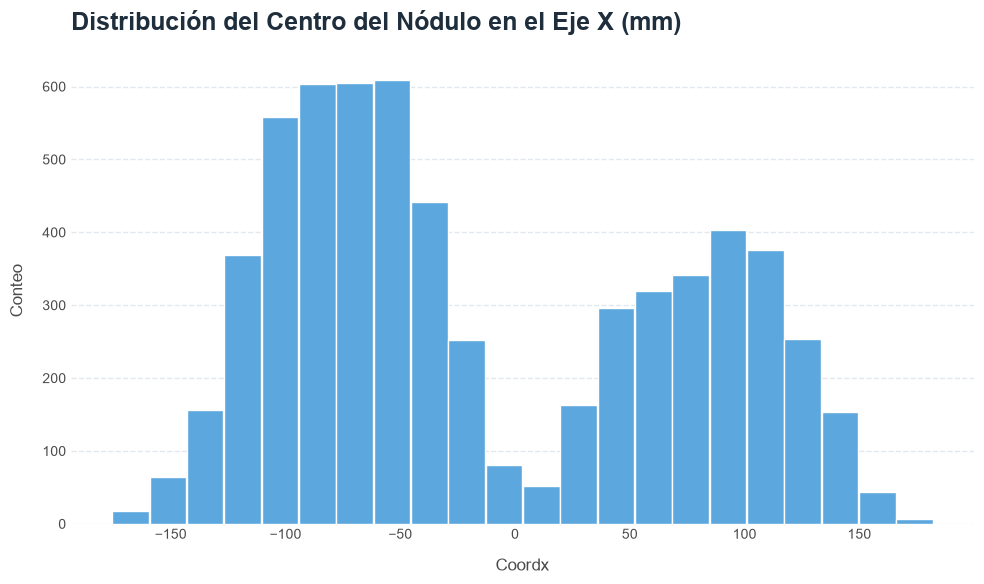

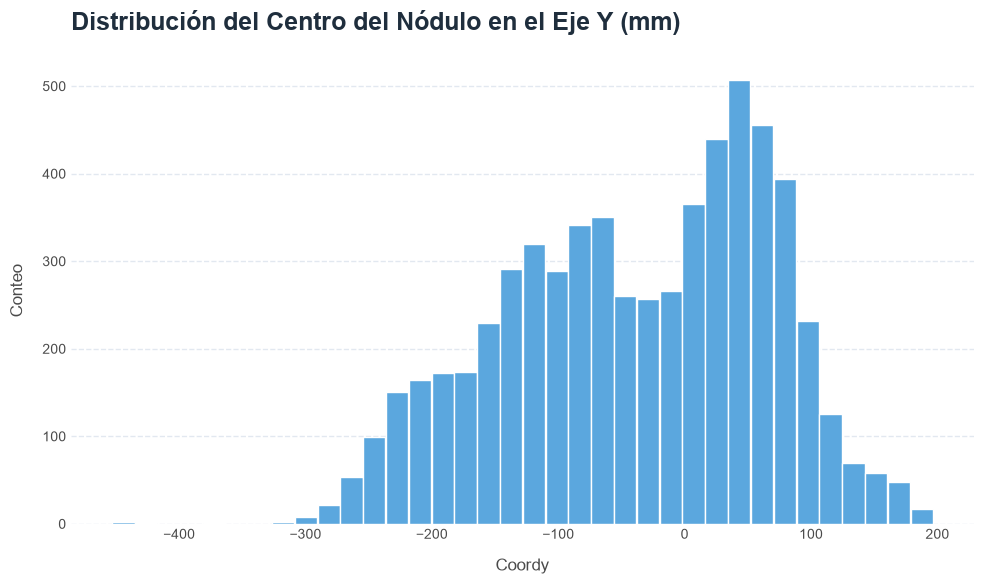

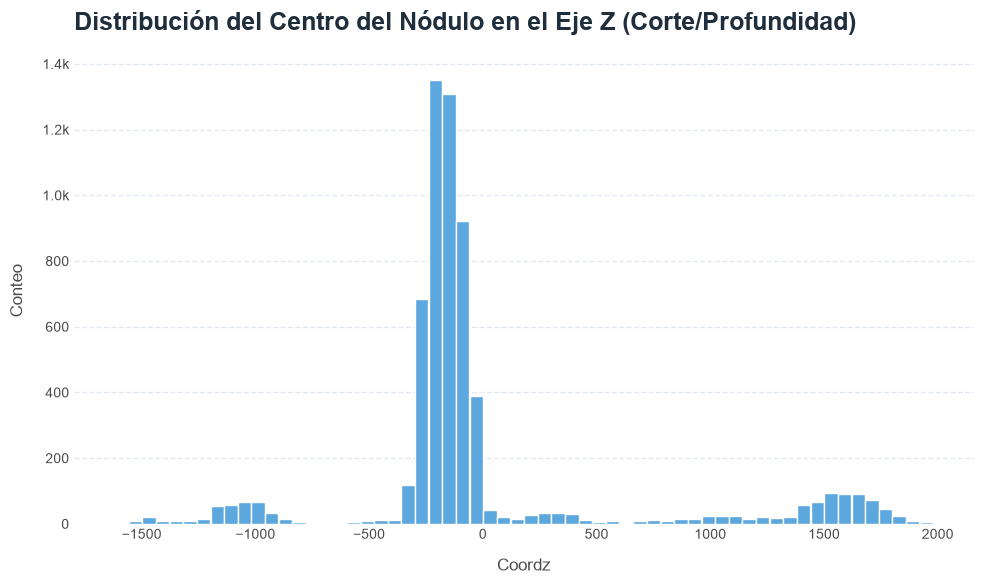

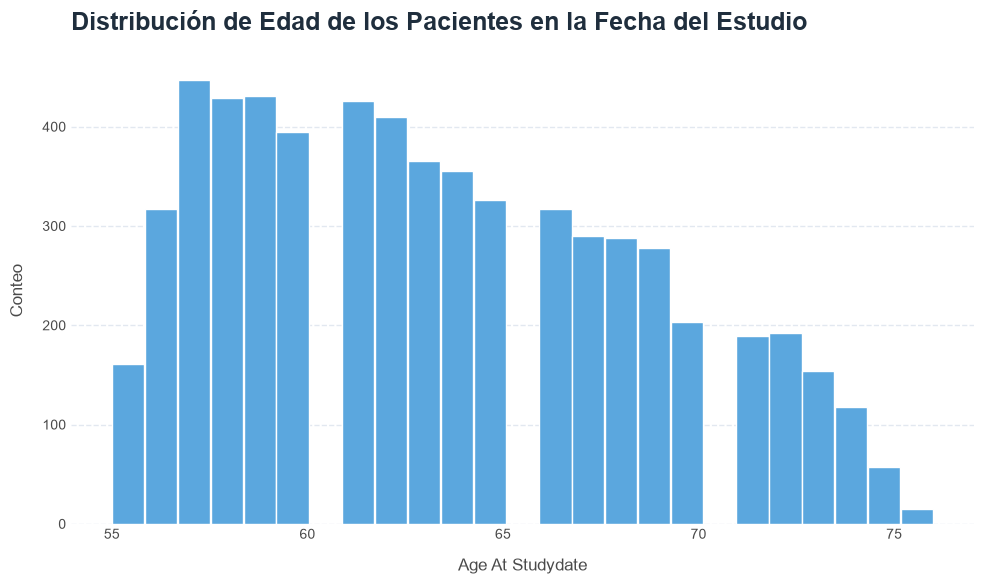

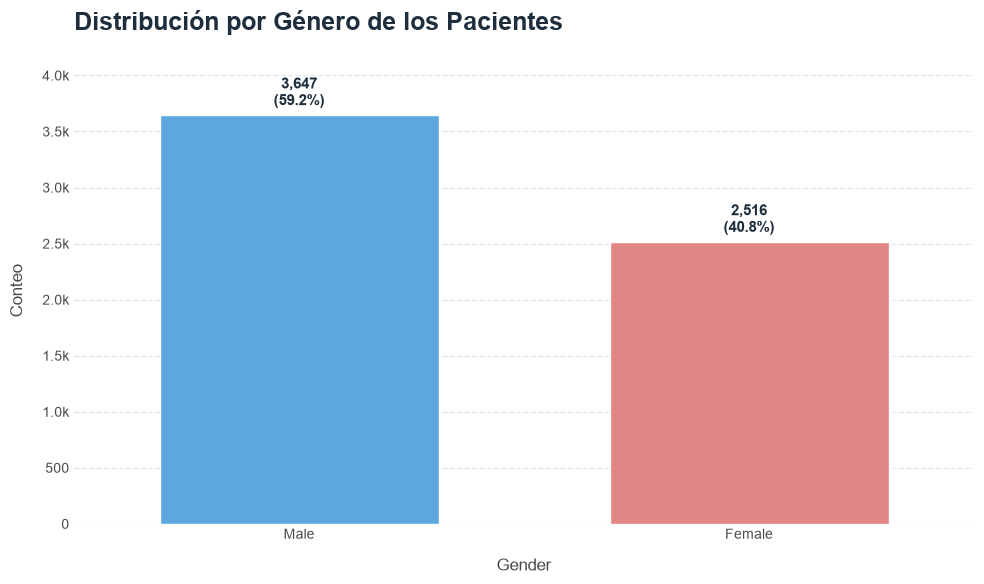

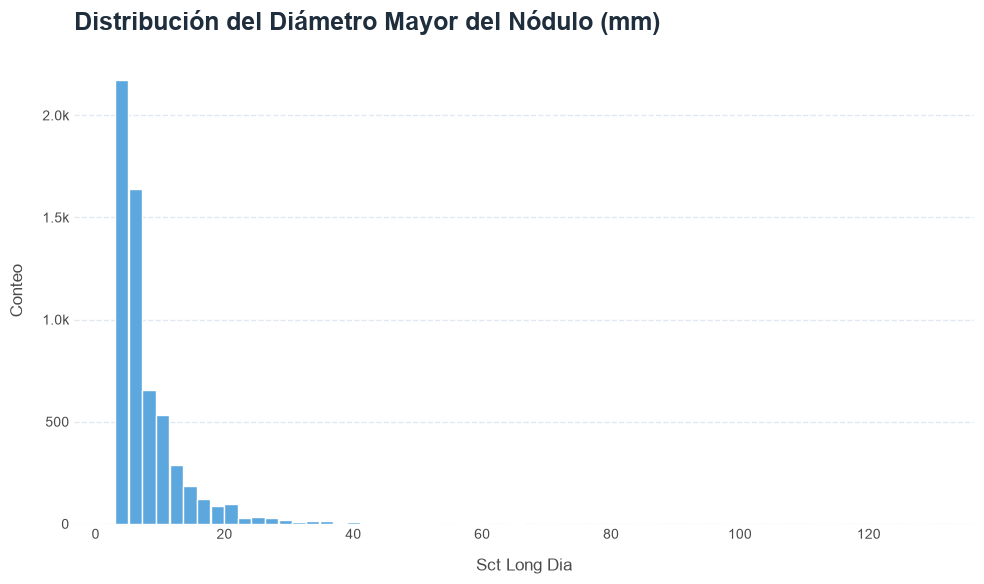

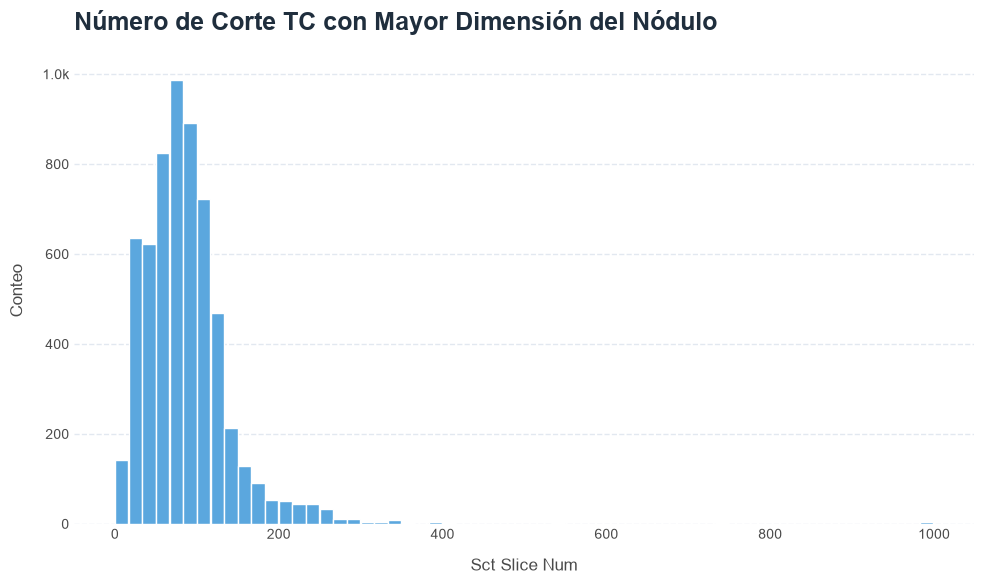

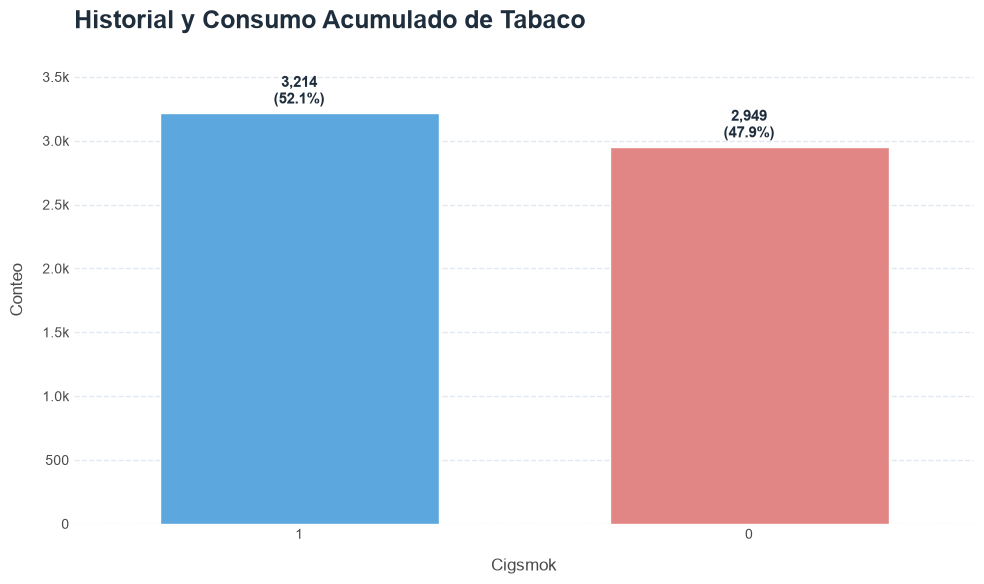

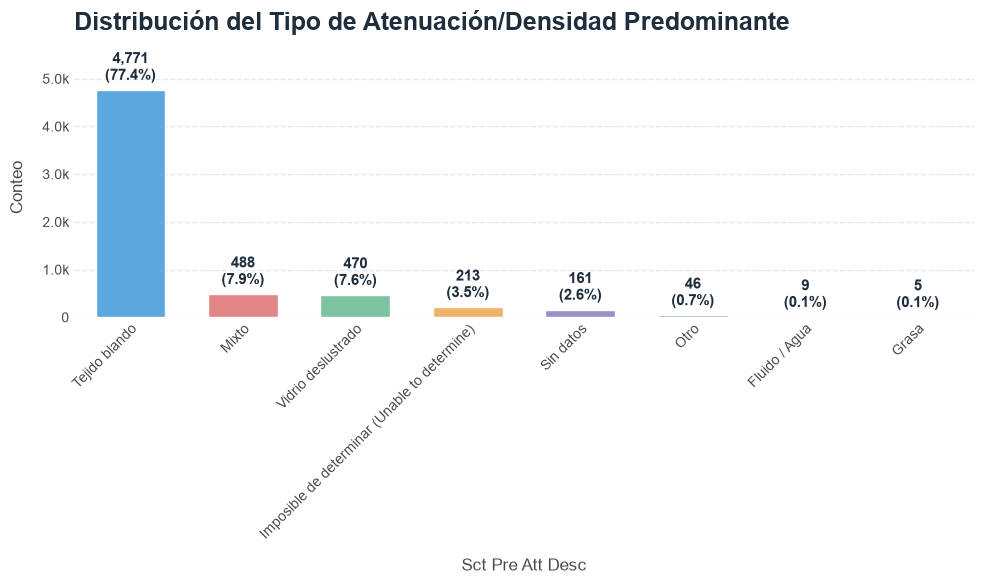

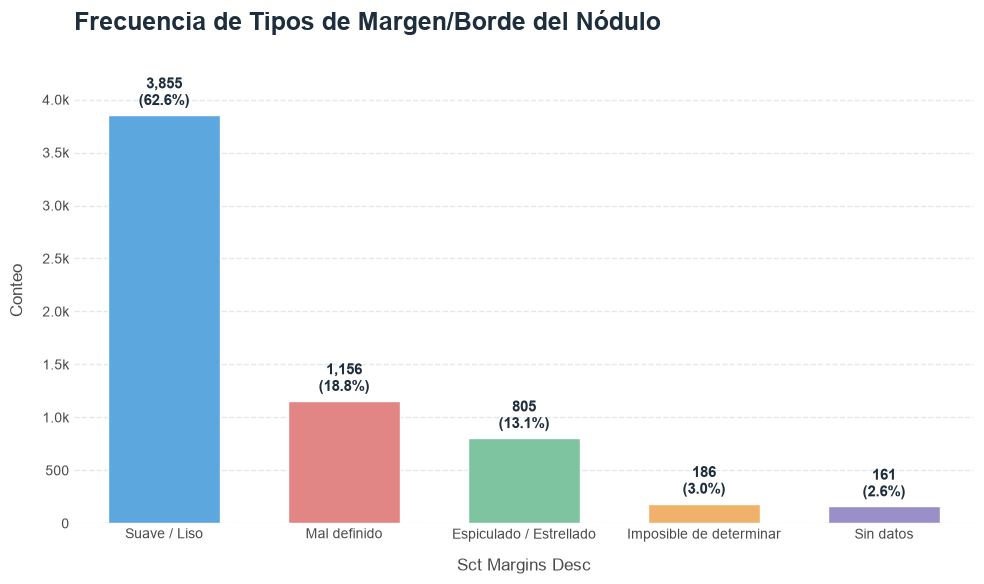

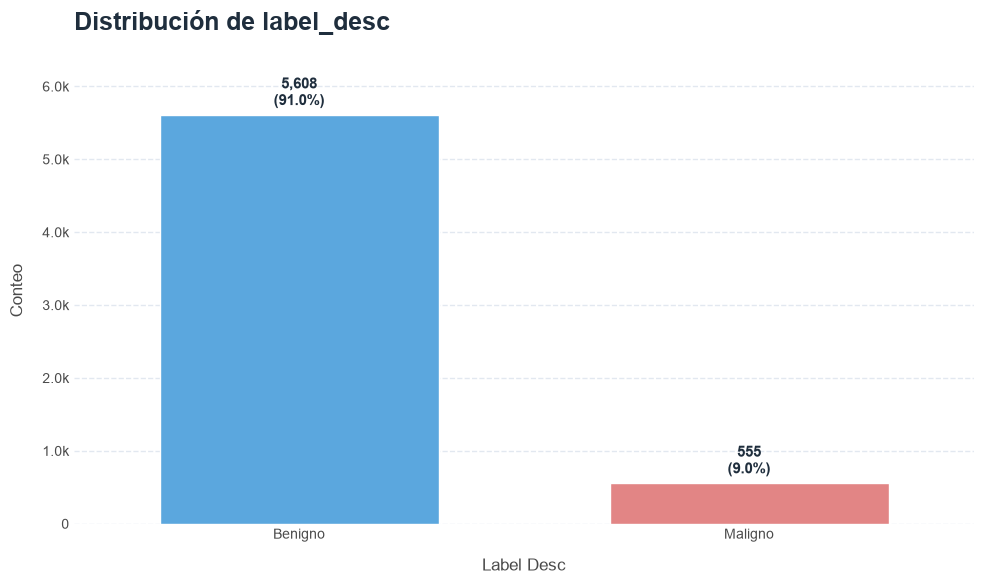

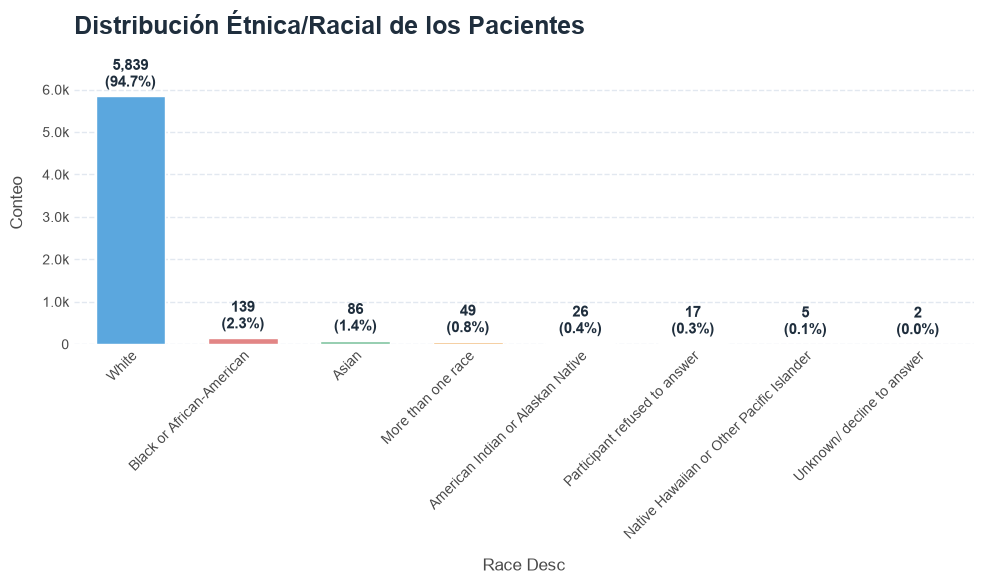

In [170]:
# ================= DICIONARIOS DE MAPEO =================

sct_titles = {
    # Coordenadas y Ubicación
    "CoordX": "Distribución del Centro del Nódulo en el Eje X (mm)",
    "CoordY": "Distribución del Centro del Nódulo en el Eje Y (mm)",
    "CoordZ": "Distribución del Centro del Nódulo en el Eje Z (Corte/Profundidad)",  # noqa: E501
    "sct_slice_num": "Número de Corte TC con Mayor Dimensión del Nódulo",
    # Identificadores y Meta-información
    "LesionID": "Frecuencia de Lesiones Registradas",
    "AnnotationID": "Conteo de Anotaciones Radiológicas",
    "NoduleID": "Identificador de Nódulos Evaluados",
    "label": "Diagnóstico de Nódulo Pulmonar (Ground Truth: Benigno vs. Maligno)",  # noqa: E501
    # Características Clínicas y Demográficas
    "Age_at_StudyDate": "Distribución de Edad de los Pacientes en la Fecha del Estudio",  # noqa: E501
    "Gender": "Distribución por Género de los Pacientes",
    "race_desc": "Distribución Étnica/Racial de los Pacientes",
    "cigsmok": "Historial y Consumo Acumulado de Tabaco",
    # Mediciones y Morfología SCT
    "sct_long_dia": "Distribución del Diámetro Mayor del Nódulo (mm)",
    "sct_margins_desc": "Frecuencia de Tipos de Margen/Borde del Nódulo",
    "sct_pre_att_desc": "Distribución del Tipo de Atenuación/Densidad Predominante",  # noqa: E501
    # Localización Tumoral (Hilio y Lóbulos)
    "loclhil": "Presencia de Cáncer en Hilio Izquierdo",
    "locrhil": "Presencia de Cáncer en Hilio Derecho",
    "locllow": "Presencia de Cáncer en Lóbulo Inferior Izquierdo",
    "locrlow": "Presencia de Cáncer en Lóbulo Inferior Derecho",
    "loclup": "Presencia de Cáncer en Lóbulo Superior Izquierdo",
    "locrup": "Presencia de Cáncer en Lóbulo Superior Derecho",
    "locrmid": "Presencia de Cáncer en Lóbulo Medio Derecho",
    "locunk": "Casos con Localización Pulmonar Desconocida",
}

# Diccionario para el tipo de atenuación/densidad predominante (sct_pre_att)
sct_pre_att_map = {
    1: "Tejido blando",
    2: "Vidrio deslustrado",
    3: "Mixto",
    4: "Fluido / Agua",
    6: "Grasa",
    7: "Otro",
    9: "Imposible de determinar (Unable to determine)",
    ".M": "Faltante / Ausente (Missing)",
    ".N": "No aplica",
}

# Diccionario para la descripción de bordes/márgenes (sct_margins)
sct_margins_map = {
    1: "Espiculado / Estrellado",
    2: "Suave / Liso",
    3: "Mal definido",
    9: "Imposible de determinar",
    ".N": "No aplica",
}

# Diccionario para la etiqueta objetivo / Ground Truth (label)
label_map = {0: "Benigno", 1: "Maligno"}

# Diccionario general para variables binarias de localización tumoral
# Aplica a: loclhil, locrhil, locllow, locrlow, loclup, locrup, locrmid, locunk
binary_location_map = {0: "Ausente", 1: "Presente"}

race_map = {
    1: "White",
    2: "Black or African-American",
    3: "Asian",
    4: "American Indian or Alaskan Native",
    5: "Native Hawaiian or Other Pacific Islander",
    6: "More than one race",
    7: "Participant refused to answer",
    95: "Missing data form - form is not expected to be completed",
    96: "Missing - no response",
    98: "Missing - form was submitted and the item was left blank",
    99: "Unknown/ decline to answer",
}

# ========= Mapear las variables categóricas a descripciones legibles =========

df_consolidado["sct_pre_att_desc"] = df_consolidado["sct_pre_att"].map(
    sct_pre_att_map
)
df_consolidado["sct_margins_desc"] = df_consolidado["sct_margins"].map(
    sct_margins_map
)
df_consolidado["label_desc"] = df_consolidado["label"].map(label_map)
df_consolidado["race_desc"] = df_consolidado["race"].map(race_map)

skipeable = ["sct_pre_att", "sct_margins", "label", "race"]

for col in df_consolidado.columns:
    if col in skipeable:
        continue
    # 1. Create a temporary series with NaNs filled
    # Use "Sin información" for strings/objects or -1 /
    # "Desconocido" for numeric/categorical
    if df_consolidado[col].dtype == "object" or pd.api.types.is_string_dtype(
        df_consolidado[col]
    ):
        col_series = df_consolidado[col].fillna("Sin datos")
    else:
        col_series = df_consolidado[col].fillna(
            -1
        )  # Or use another placeholder like 0 or 'Faltante'

    # 2. Check condition using the filled series
    is_string = col_series.dtype == "object" or pd.api.types.is_string_dtype(
        col_series
    )
    is_discrete_numeric = (
        pd.api.types.is_numeric_dtype(col_series) and col_series.nunique() < 20
    )

    if is_string or is_discrete_numeric:
        # Option A: Pass a temporal DataFrame with the filled column
        df_temp = df_consolidado.copy()
        df_temp[col] = col_series
        rota = 45 if df_temp[col].nunique() > 7 else 0
        fancy_bars(
            df_temp,
            col,
            title=sct_titles.get(col, f"Distribución de {col}"),
            figsize=(10, 6),
            labels="both",
            rot=rota,
        )
    elif df_consolidado[col].dtype in ["int64", "float64"]:
        fancy_hist(
            df_consolidado,
            col,
            title=sct_titles.get(col, f"Distribución de {col}"),
            figsize=(10, 6),
        )

En la muestra predominan las personas blancas, ademas tan solo el 9% de nodulos son malignos, configurando asi un problema desbalanceado, asi mismo solo el 13,4% de los nodulos son espiculados (lo cual es uno de los criterios mas usados para sospechar que un nodulo es maligno usando una TC), en la mayoria de registros se tiene que la clase de tejido predominante es tejido blando.

Dado este analisis se configura la siguiente pregunta "que relacion tiene la label benigno/maligno con las demas varaibles, con cules asocia o correlaciona de manera más significativa", esto se respondera usando pruebas de hipotesis y graficos bi variados en la siguiente etapa.

## Analisis multivariado 

In [171]:
df_consolidado.columns

Index(['CoordX', 'CoordY', 'CoordZ', 'label', 'Age_at_StudyDate', 'Gender',
       'sct_long_dia', 'sct_margins', 'sct_pre_att', 'sct_slice_num', 'race',
       'cigsmok', 'sct_pre_att_desc', 'sct_margins_desc', 'label_desc',
       'race_desc'],
      dtype='str')

In [172]:
features = list(
    set(df_consolidado.columns)
    - {
        "label",
        "sct_pre_att_desc",
        "sct_margins_desc",
        "label_desc",
        "race_desc",
    }
)

In [173]:
len(features)

11

In [174]:
test_features_against_target(
    df_consolidado,
    feature_variables=features,
    target_variable="label",
)

,feature,tipo_feature,target,tipo_target,n,n_grupos,prueba,estadistico,p_valor,normalidad,homocedasticidad,supuesto_ok,cramer_v,decision,conclusion,post_hoc
0,sct_slice_num,discreta,label,categorica,6002,2,U de Mann-Whitney,1.387450e+06,0.000000,no,sí,NaN,NaN,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
1,sct_long_dia,discreta,label,categorica,5969,2,U de Mann-Whitney,5.577580e+05,0.000000,no,no,NaN,NaN,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
2,CoordZ,continua,label,categorica,6163,2,U de Mann-Whitney,1.166318e+06,0.000000,no,sí,NaN,NaN,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
3,sct_margins,categorica,label,categorica,6002,8,Chi-cuadrado de Pearson,3.099374e+02,0.000000,NaN,NaN,sí,0.2272,Se rechaza H0,Dependencia: la distribución cambia entre cate...,1.0|1 (r=+13.48); 2.0|1 (r=-8.50); 9.0|1 (r=+5...
4,race,categorica,label,categorica,6161,14,Chi-cuadrado de Pearson,3.325750e+01,0.000009,NaN,NaN,no,0.0735,Se rechaza H0,Dependencia: la distribución cambia entre cate...,4|1 (r=+4.35); 5|1 (r=+2.31)
5,Age_at_StudyDate,discreta,label,categorica,6163,2,U de Mann-Whitney,1.427868e+06,0.001304,no,sí,NaN,NaN,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
6,sct_pre_att,categorica,label,categorica,6002,14,Chi-cuadrado de Pearson,1.593650e+01,0.014099,NaN,NaN,no,0.0515,Se rechaza H0,Dependencia: la distribución cambia entre cate...,3.0|1 (r=+2.44); 7.0|1 (r=+2.07)
7,CoordX,continua,label,categorica,6163,2,U de Mann-Whitney,1.475223e+06,0.042796,no,no,NaN,NaN,Se rechaza H0,Dependencia: la numérica difiere entre categorías,
8,Gender,categorica,label,categorica,6163,4,Chi-cuadrado de Pearson,3.589000e+00,0.058164,NaN,NaN,sí,0.0241,No se rechaza H0,Independencia: no hay evidencia de asociación,
9,CoordY,continua,label,categorica,6163,2,U de Mann-Whitney,1.484278e+06,0.071983,no,no,NaN,NaN,No se rechaza H0,Independencia: no hay evidencia de diferencia,


Las variables que tienen una dependencia estadísticamente significativa con la etiqueta de malignidad (label) son:

* sct_margins (borde del nódulo)
* sct_long_dia (diámetro mayor del nódulo)
* sctt_slice_num (corte con mayor dimensión del nódulo)
* race (significancia poco confiable, pues no cumple con el supuesto de que todos los esperados sean mayores a 5, y además tiene mucho desbalance en las categorías)
* CoordX (indica la lateralidad del nódulo)
* sct_pre_att (tipo densidad predominante, poco confiable, no cumple supuesto y muy desequilibrado)
* Age_at_StudyDate



### Analisis grafico de relaciones

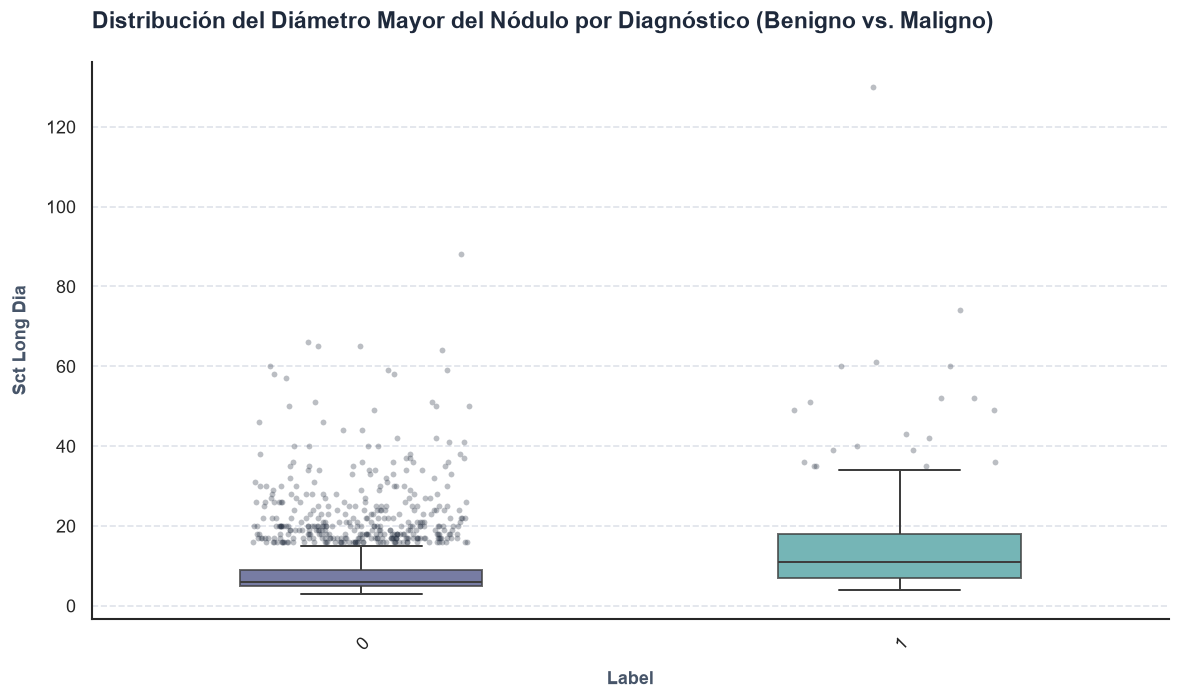

In [175]:
plot_segmented_boxplot(
    df_consolidado,
    cat_col="label",
    num_col="sct_long_dia",
    show_points=True,
    title="Distribución del Diámetro Mayor del Nódulo por Diagnóstico (Benigno vs. Maligno)",  # noqa: E501
)

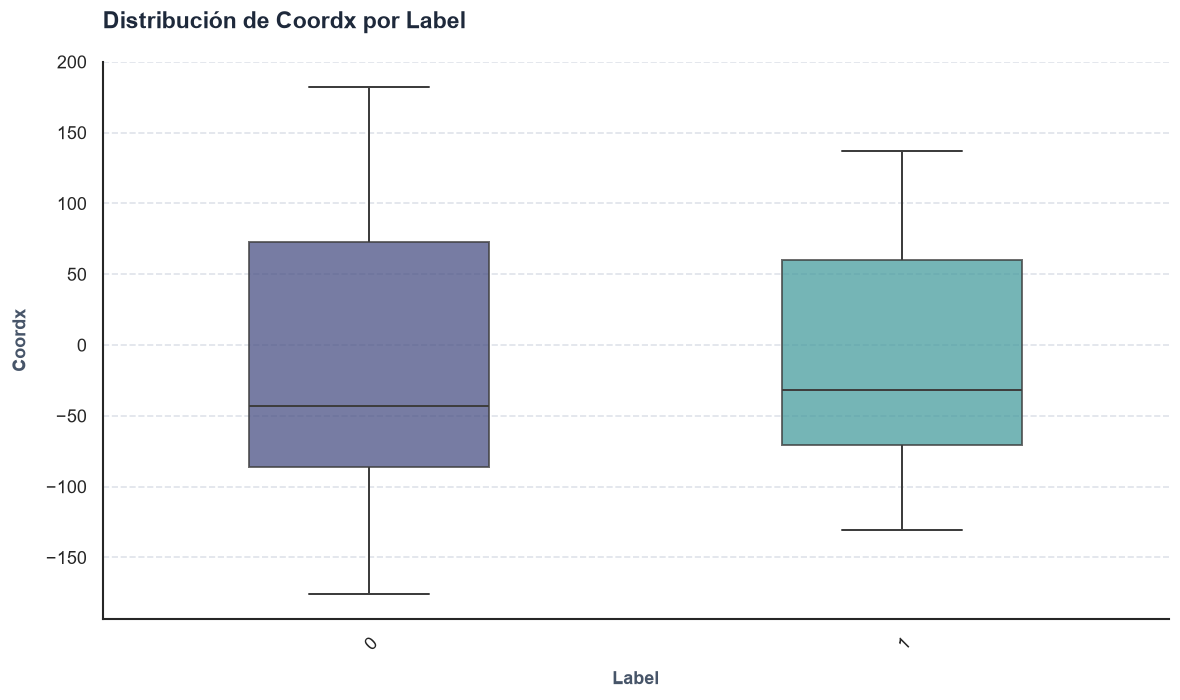

In [176]:
plot_segmented_boxplot(
    df_consolidado, cat_col="label", num_col="CoordX", show_points=True
)

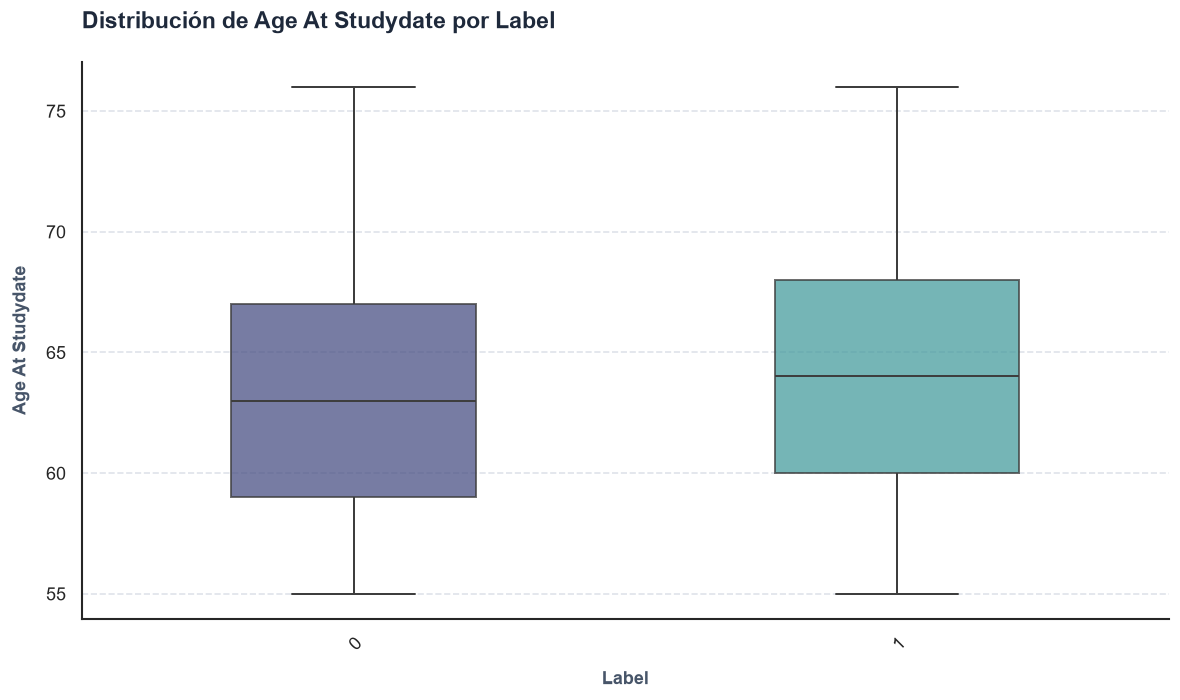

In [177]:
plot_segmented_boxplot(
    df_consolidado,
    cat_col="label",
    num_col="Age_at_StudyDate",
    show_points=True,
)

Graficamente no se logra apreciar una diferencia clara entre benignos y malignos en las variables numéricas (a pesar que las pruebas de hipotesis respaldan dicha diferencia), aunque **sí se observa que los nódulos malignos tienden a tener diámetros mayores**. Esto sugiere que, aunque las características numéricas pueden aportar información, no son suficientes por sí solas para diferenciar entre nódulos benignos y malignos de manera concluyente.

array([<Axes: title={'left': 'Label = 0  (n=5,576)'}, xlabel='Sct Margins Desc', ylabel='Porcentaje'>,
       <Axes: title={'left': 'Label = 1  (n=426)'}, xlabel='Sct Margins Desc'>],
      dtype=object)

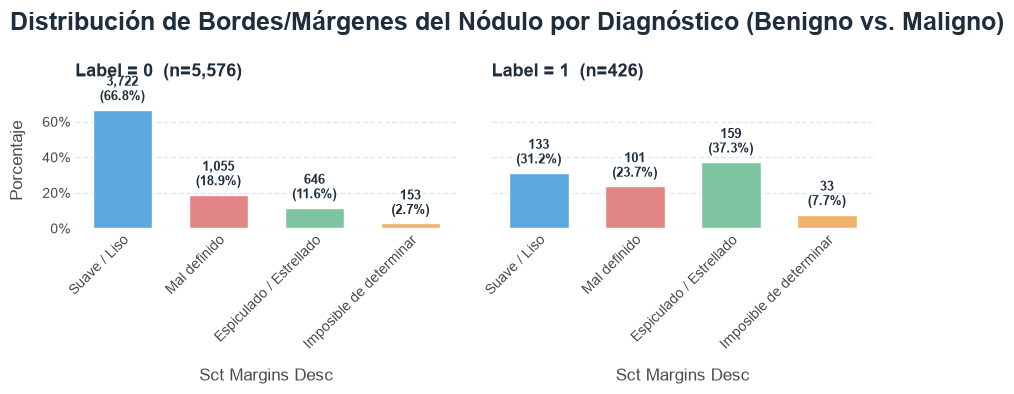

In [178]:
segmented_bars(
    df_consolidado,
    x="sct_margins_desc",
    segment="label",
    rot=45,
    title="Distribución de Bordes/Márgenes del Nódulo por Diagnóstico (Benigno vs. Maligno)",  # noqa: E501
    labels="both",
)

Aca se logra apreciar la primera diferencia notable entre los nódulos benignos y malignos: la mayoría de los nódulos malignos presentan bordes espiculados o estrellados, mientras que los benignos tienden a tener bordes suaves o lisos. Esto sugiere que la morfología del borde del nódulo puede ser un indicador importante para diferenciar entre nódulos benignos y malignos en estudios de imagen pulmonar.

Hay menos de 555 nodulos malignos ya que `sct_margins` tiene 161 nulos (algunos corresponden a malignos y otros a benignos, no interesa limpiar esto ya que solo se esta describniendo el problema y estas vars no se usaran en la base de datos).

In [179]:
df_consolidado[df_consolidado["label"] == 1].groupby(
    "sct_margins_desc"
).size().sort_values(ascending=False)

sct_margins_desc
Espiculado / Estrellado    159
Suave / Liso               133
Mal definido               101
Imposible de determinar     33
dtype: int64

In [180]:
df_consolidado["sct_margins"].isnull().sum()

np.int64(161)

array([<Axes: title={'left': 'Label = 0  (n=5,608)'}, xlabel='Race Desc', ylabel='Porcentaje'>,
       <Axes: title={'left': 'Label = 1  (n=555)'}, xlabel='Race Desc'>],
      dtype=object)

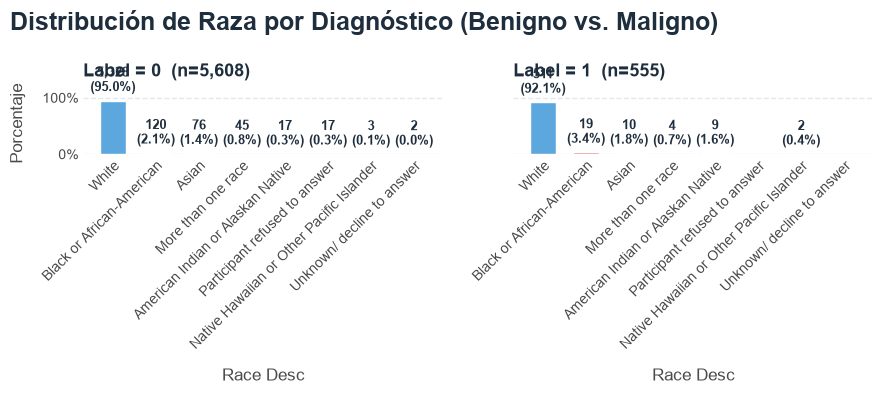

In [181]:
segmented_bars(
    df_consolidado,
    x="race_desc",
    segment="label",
    rot=45,
    title="Distribución de Raza por Diagnóstico (Benigno vs. Maligno)",
    labels="both",
)

Se observa graficamente que su significancia solo fue por desbalance de razas y por falta de supuestos.

array([<Axes: title={'left': 'Label = 0  (n=5,576)'}, xlabel='Sct Pre Att Desc', ylabel='Porcentaje'>,
       <Axes: title={'left': 'Label = 1  (n=426)'}, xlabel='Sct Pre Att Desc'>],
      dtype=object)

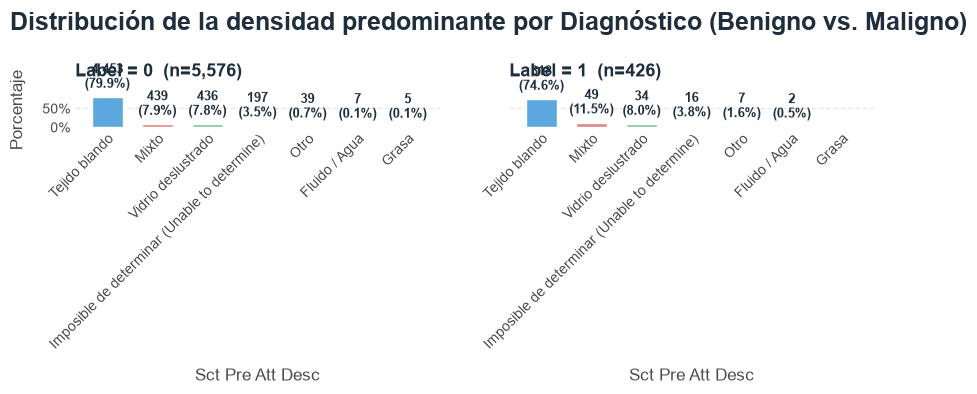

In [182]:
segmented_bars(
    df_consolidado,
    x="sct_pre_att_desc",
    segment="label",
    rot=45,
    title="Distribución de la densidad predominante por Diagnóstico (Benigno vs. Maligno)",  # noqa: E501
    labels="both",
)

Se observa graficamente que su significancia solo fue por desbalance de razas y por falta de supuestos. El ordenamiento se mantiene entre categorias de clase a clase

# Analisis de imagenes

In [183]:
BLOCK_SHAPE = (64, 128, 128)


# ===========================================================================
# 2. Estadísticos por nódulo, calculados en GPU
# ===========================================================================
@torch.no_grad()
def nodule_stats(
    csv_path=config.LUNA25_LABELS,
    data_dir=config.NODULE_BLOCKS_ROOT,
    coord_order="zyx",
    size_mm=50.0,
    size_px=64,
    radii_mm=(5.0, 10.0, 15.0),
    batch_size=32,
    num_workers=8,
    limit=None,
    out_csv="nodule_stats.csv",
):
    df = pd.read_csv(csv_path)
    if limit:
        df = df.head(limit)
    device = get_device()
    print(f"device={device}  n={len(df)}")
    loader = build_dataloader(
        data_dir,
        df,
        batch_size=batch_size,
        num_workers=num_workers,
        device=device,
        coord_order=coord_order,
        expected_shape=BLOCK_SHAPE,
    )
    extractor = PatchExtractor(
        size_px=size_px, size_mm=size_mm, mode="3D", padding_mode="border"
    ).to(device)

    # malla de distancia radial en mm, se construye una sola vez
    vs = size_mm / size_px
    ax = (
        torch.arange(size_px, device=device, dtype=torch.float32)
        - (size_px - 1) / 2
    ) * vs
    rr = torch.sqrt(
        sum(g**2 for g in torch.meshgrid(ax, ax, ax, indexing="ij"))
    )
    masks = {r: (rr <= r) for r in radii_mm}
    shell = (rr > max(radii_mm)) & (rr <= max(radii_mm) + 5.0)
    rows, t0, seen = [], time.time(), 0
    pbar = tqdm(
        loader,
        total=len(loader),
        desc="nódulos",
        unit="batch",
        dynamic_ncols=True,
    )
    for batch in pbar:
        batch = batch.to(device)
        patch = extractor(
            batch.image, batch.spacing, batch.transform, batch.center_vox
        )  # (B,1,64,64,64) en HU
        p = patch[:, 0]
        block = batch.image[:, 0].flatten(1)
        rec = {
            "AnnotationID": batch.annotation_id,
            "PatientID": batch.patient_id,
            "label": batch.label.cpu().numpy(),
            "spacing_z": batch.spacing[:, 0].cpu().numpy(),
            "spacing_y": batch.spacing[:, 1].cpu().numpy(),
            "spacing_x": batch.spacing[:, 2].cpu().numpy(),
            # bloque completo: control de calidad de la carga
            "block_mean": block.mean(1).cpu().numpy(),
            "block_std": block.std(1).cpu().numpy(),
            "block_min": block.min(1).values.cpu().numpy(),
            "block_max": block.max(1).values.cpu().numpy(),
            # patch remuestreado a espaciado isotrópico
            "patch_mean": p.flatten(1).mean(1).cpu().numpy(),
            "patch_std": p.flatten(1).std(1).cpu().numpy(),
        }
        for r, m in masks.items():
            v = p[:, m]
            rec[f"mean_r{r:g}mm"] = v.mean(1).cpu().numpy()
            rec[f"std_r{r:g}mm"] = v.std(1).cpu().numpy()
            # fracción de tejido sólido dentro de la esfera
            rec[f"solid_frac_r{r:g}mm"] = (
                (v > -300).float().mean(1).cpu().numpy()
            )
        rec["mean_shell"] = (
            p[:, shell].mean(1).cpu().numpy()
        )  # Esto representa la densidad del parénquima pulmonar
        # sano que rodea a la lesión.
        # contraste nódulo - entorno: proxy simple de solidez
        rec["contrast"] = rec[f"mean_r{min(radii_mm):g}mm"] - rec["mean_shell"]
        rows.append(pd.DataFrame(rec))
        seen += len(batch)
        pbar.set_postfix(nodulos=seen, refresh=False)
        if seen % (batch_size * 20) == 0:
            el = time.time() - t0
            tqdm.write(
                f"  {seen}/{len(df)}  {el:.0f}s  ({seen / el:.0f} nódulos/s)"
            )
    pbar.close()
    out = pd.concat(rows, ignore_index=True)
    out.to_csv(out_csv, index=False)
    print(f"\n{len(out)} filas -> {out_csv}")
    print(
        out[["patch_mean", "mean_r5mm", "mean_shell", "contrast"]]
        .describe()
        .round(1)
    )
    return out

In [184]:
output_csv_general_carc = config.TABLES_DIR / "nodule_stats_general.csv"
output_csv_shape_carc = config.TABLES_DIR / "nodule_stats_shape.csv"
if not os.path.exists(output_csv_general_carc):
    analisis_inicial_imagenes = nodule_stats(out_csv=output_csv_general_carc)
else:
    analisis_inicial_imagenes = pd.read_csv(output_csv_general_carc)

In [185]:
if not os.path.exists(output_csv_shape_carc):
    analisis_forma_imagenes = nodule_morphometry(out_csv=output_csv_shape_carc)
else:
    analisis_forma_imagenes = pd.read_csv(output_csv_shape_carc)

In [186]:
analisis_forma_imagenes

,AnnotationID,PatientID,label,bg_lung_hu,seg_threshold_hu,seg_n_vox,seg_leak_frac,seg_seed_forced,seg_converged,volume_mm3,...,hu_range_p10_p90,hu_max,frac_air,frac_ggo,frac_soft,frac_calcified,solid_fraction,volume_solid_mm3,contrast_hu,diam_equiv_solid_mm
0,100570_1_19990102,100570,1,-908.03033,-700.00000,65274.0,0.094295,0,1,15936.03500,...,670.53340,278.720600,0.0,0.291311,0.708475,0.000214,0.708689,11293.701000,752.24884,27.836369
1,106364_1_19990102,106364,1,-900.07080,-700.00000,7423.0,0.061700,0,1,1812.25590,...,719.04144,119.675674,0.0,0.666981,0.333019,0.000000,0.333019,603.515600,509.17520,10.484877
2,127302_1_20000102,127302,1,-909.49445,-700.00000,26798.0,0.128816,0,1,6542.48050,...,660.12024,106.993140,0.0,0.535861,0.464139,0.000000,0.464139,3036.621000,585.11475,17.966522
3,128899_1_20010102,128899,1,-866.22064,-666.22064,41255.0,0.162841,0,1,10072.02100,...,571.48956,540.387500,0.0,0.287068,0.700448,0.012483,0.712932,7180.664000,660.72766,23.936209
4,215816_1_19990102,215816,1,-901.89710,-700.00000,18621.0,0.056710,0,1,4546.14260,...,664.70120,131.878340,0.0,0.630740,0.369261,0.000000,0.369261,1678.710900,526.82530,14.745487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,123244_1_20010102,123244,0,-909.50450,-700.00000,1860.0,0.052151,0,1,454.10156,...,326.94028,-53.628174,0.0,0.934409,0.065591,0.000000,0.065591,29.785156,344.25890,3.845922
6159,104196_1_20000102,104196,0,-861.46747,-661.46747,78124.0,0.183580,0,1,19073.24200,...,481.27884,954.504940,0.0,0.065127,0.750000,0.184873,0.934873,17831.055000,914.58563,32.413517
6160,104196_1_20010102,104196,0,-884.68520,-684.68520,75632.0,0.184618,0,1,18464.84400,...,480.34335,1041.136100,0.0,0.067485,0.739925,0.192590,0.932515,17218.750000,942.08670,32.038170
6161,204005_1_19990102,204005,0,-874.01666,-674.01666,64781.0,0.181843,0,1,15815.67400,...,386.94983,1022.406000,0.0,0.049197,0.768914,0.181890,0.950803,15037.598000,957.93066,30.623863


In [187]:
analisis_inicial_imagenes

,AnnotationID,PatientID,label,spacing_z,spacing_y,spacing_x,block_mean,block_std,block_min,block_max,...,std_r5mm,solid_frac_r5mm,mean_r10mm,std_r10mm,solid_frac_r10mm,mean_r15mm,std_r15mm,solid_frac_r15mm,mean_shell,contrast
0,100570_1_19990102,100570,1,2.00,0.625000,0.625000,-699.39480,378.75485,-1024.0,561.0,...,61.444565,0.994485,-92.67333,269.30667,0.837946,-342.09890,404.06122,0.545072,-685.81915,719.735500
1,106364_1_19990102,106364,1,2.00,0.507812,0.507812,-567.53820,465.89860,-1024.0,2247.0,...,299.892580,0.711397,-702.49440,291.86206,0.132091,-813.13184,200.28650,0.046905,-795.93610,609.496800
2,127302_1_20000102,127302,1,2.50,0.703125,0.703125,-844.92114,200.10689,-1024.0,179.0,...,93.696976,0.977941,-465.15335,347.32224,0.383806,-730.82400,294.40530,0.135453,-827.73940,814.827900
3,128899_1_20010102,128899,1,2.50,0.644531,0.644531,-462.17355,487.65256,-1024.0,1478.0,...,151.793270,0.044118,-652.51904,258.88070,0.140897,-646.24600,310.89700,0.205166,-672.35380,124.272950
4,215816_1_19990102,215816,1,2.00,0.621094,0.621094,-459.84518,447.98860,-1024.0,1075.0,...,109.623100,0.959559,-535.54030,335.45935,0.288998,-744.11490,264.86850,0.104942,-822.85470,796.625900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6158,123244_1_20010102,123244,0,2.00,0.564453,0.564453,-446.57860,506.53302,-1024.0,1943.0,...,196.519090,0.054228,-787.42053,213.88962,0.063129,-679.44860,345.77860,0.206897,-513.37616,-222.343750
6159,104196_1_20000102,104196,0,2.00,0.625000,0.625000,-361.61578,495.10034,-1024.0,1663.0,...,476.968140,0.387868,-378.29380,521.17737,0.428179,-357.15134,488.62466,0.494094,-321.43930,-61.328033
6160,104196_1_20010102,104196,0,2.00,0.605469,0.605469,-407.58720,517.99445,-1024.0,1576.0,...,369.811700,0.350184,-433.64166,502.27634,0.403019,-385.40335,498.55316,0.471762,-340.67270,-144.203800
6161,204005_1_19990102,204005,0,1.25,0.664062,0.664062,-635.32043,441.74603,-1024.0,1185.0,...,363.603760,0.393382,-475.88086,447.93000,0.395700,-443.39026,478.05020,0.425774,-395.55154,-49.792510


In [188]:
analisis_inicial_imagenes.info()

<class 'pandas.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AnnotationID      6163 non-null   str    
 1   PatientID         6163 non-null   int64  
 2   label             6163 non-null   int64  
 3   spacing_z         6163 non-null   float64
 4   spacing_y         6163 non-null   float64
 5   spacing_x         6163 non-null   float64
 6   block_mean        6163 non-null   float64
 7   block_std         6163 non-null   float64
 8   block_min         6163 non-null   float64
 9   block_max         6163 non-null   float64
 10  patch_mean        6163 non-null   float64
 11  patch_std         6163 non-null   float64
 12  mean_r5mm         6163 non-null   float64
 13  std_r5mm          6163 non-null   float64
 14  solid_frac_r5mm   6163 non-null   float64
 15  mean_r10mm        6163 non-null   float64
 16  std_r10mm         6163 non-null   float64
 17  solid_

In [189]:
# PatientID llega como str si el DataFrame se acaba de calcular
# (torch_dataloader lo castea con str()) y como int64 si se releyó del CSV.
# Se normalizan las claves antes de unir para que casen en ambos casos.
for _df in (analisis_inicial_imagenes, analisis_forma_imagenes):
    _df["AnnotationID"] = _df["AnnotationID"].astype(str)
    _df["PatientID"] = _df["PatientID"].astype("int64")

analisis_imagenes = analisis_inicial_imagenes.merge(
    analisis_forma_imagenes,
    on=["AnnotationID", "PatientID", "label"],
    validate="one_to_one",
)

# Unir por las tres claves comprueba de paso que ambas tablas vengan de la
# misma corrida: si una quedó desfasada, aquí se perderían filas.
assert len(analisis_imagenes) == len(analisis_inicial_imagenes), (
    "las tablas no casan fila a fila; regenera los CSV"
)

# La segmentación falló en ~43% de los nódulos (seg_n_vox == 0) y deja NaN en
# las 15 columnas de densidad. Se marca para no arrastrar esos vacíos en
# silencio aguas abajo.
analisis_imagenes["seg_ok"] = analisis_imagenes["seg_n_vox"] > 0

analisis_imagenes.to_csv(
    config.TABLES_DIR / "nodule_stats_merged.csv", index=False
)

print(analisis_imagenes.shape)
print(f"segmentación válida: {analisis_imagenes.seg_ok.mean():.1%}")
analisis_imagenes.head()

(6163, 61)
segmentación válida: 99.8%


,AnnotationID,PatientID,label,spacing_z,spacing_y,spacing_x,block_mean,block_std,block_min,block_max,...,hu_max,frac_air,frac_ggo,frac_soft,frac_calcified,solid_fraction,volume_solid_mm3,contrast_hu,diam_equiv_solid_mm,seg_ok
0,100570_1_19990102,100570,1,2.0,0.625000,0.625000,-699.39480,378.75485,-1024.0,561.0,...,278.720600,0.0,0.291311,0.708475,0.000214,0.708689,11293.7010,752.24884,27.836369,True
1,106364_1_19990102,106364,1,2.0,0.507812,0.507812,-567.53820,465.89860,-1024.0,2247.0,...,119.675674,0.0,0.666981,0.333019,0.000000,0.333019,603.5156,509.17520,10.484877,True
2,127302_1_20000102,127302,1,2.5,0.703125,0.703125,-844.92114,200.10689,-1024.0,179.0,...,106.993140,0.0,0.535861,0.464139,0.000000,0.464139,3036.6210,585.11475,17.966522,True
3,128899_1_20010102,128899,1,2.5,0.644531,0.644531,-462.17355,487.65256,-1024.0,1478.0,...,540.387500,0.0,0.287068,0.700448,0.012483,0.712932,7180.6640,660.72766,23.936209,True
4,215816_1_19990102,215816,1,2.0,0.621094,0.621094,-459.84518,447.98860,-1024.0,1075.0,...,131.878340,0.0,0.630740,0.369261,0.000000,0.369261,1678.7109,526.82530,14.745487,True


## Diccionario de variables — `analisis_imagenes`

Tabla de **6.163 filas × 61 columnas**, una fila por nódulo. Resulta de unir
`nodule_stats_general.csv` (celda 61) con `nodule_stats_shape.csv` (celda 62)
por `AnnotationID`, `PatientID` y `label`.

Ambos bloques se calculan sobre parches remuestreados a espaciado isótropo,
pero **no del mismo tamaño**: los estadísticos generales usan 64³ vóxeles en
50 mm (0,781 mm/vóxel) y la morfometría usa 80³ en 50 mm (0,625 mm/vóxel). Todas
las densidades están en unidades Hounsfield (HU). Los cortes de densidad son
`aire < −750`, `sólido > −300`, `calcificación > 200`.

### Claves e identificadores

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`AnnotationID`** | Identificador de la anotación; clave primaria de la tabla. | *Cadena `paciente_lesion_fecha`, p. ej. `100570_1_19990102`. 6.163 valores únicos.* |
| **`PatientID`** | Identificador del participante NLST. | *Entero. 2.120 pacientes, varios nódulos por paciente.* |
| **`label`** | Etiqueta objetivo (Ground Truth). | • `0`: Benigno (5.608)<br>• `1`: Maligno (555) |

### Geometría de adquisición

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`spacing_z`** | Espaciado entre cortes del volumen original (mm). | *Continua, 0,50 – 3,20 mm. Es el eje anisótropo.* |
| **`spacing_y`** | Espaciado en el eje Y del volumen original (mm). | *Continua, 0,461 – 0,977 mm.* |
| **`spacing_x`** | Espaciado en el eje X del volumen original (mm). | *Continua, 0,461 – 0,977 mm.* |

### Control de calidad del bloque crudo

Estadísticos sobre el bloque `.npy` completo (64×128×128) tal como está en disco,
antes de recortar. Sirven para detectar cargas defectuosas.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`block_mean`** | Densidad media del bloque completo. | *Continua (HU). Rango observado −1.115 a −76.* |
| **`block_std`** | Desviación estándar del bloque completo. | *Continua (HU).* |
| **`block_min`** | Densidad mínima del bloque. | *Continua (HU). Llega a −6.055, por debajo del mínimo físico del aire (−1.024): indica relleno fuera del campo reconstruido.* |
| **`block_max`** | Densidad máxima del bloque. | *Continua (HU). Llega a 6.100, por encima del rango físico habitual.* |

### Densidad del parche y esferas concéntricas

Medidas sobre el parche isótropo de 64³. Las esferas son concéntricas al centro
anotado del nódulo.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`patch_mean`** | Densidad media de todo el parche de 50 mm. | *Continua (HU).* |
| **`patch_std`** | Desviación estándar de todo el parche. | *Continua (HU). Un `0` indica parche constante, es decir, carga degenerada.* |
| **`mean_r5mm`** | Densidad media dentro de la esfera de radio 5 mm. | *Continua (HU). La más cercana al núcleo de la lesión.* |
| **`std_r5mm`** | Desviación estándar dentro de la esfera de 5 mm. | *Continua (HU). Proxy de heterogeneidad interna.* |
| **`solid_frac_r5mm`** | Fracción de vóxeles sólidos (> −300 HU) en la esfera de 5 mm. | *Proporción 0 – 1.* |
| **`mean_r10mm`** | Densidad media dentro de la esfera de radio 10 mm. | *Continua (HU).* |
| **`std_r10mm`** | Desviación estándar dentro de la esfera de 10 mm. | *Continua (HU).* |
| **`solid_frac_r10mm`** | Fracción de vóxeles sólidos (> −300 HU) en la esfera de 10 mm. | *Proporción 0 – 1.* |
| **`mean_r15mm`** | Densidad media dentro de la esfera de radio 15 mm. | *Continua (HU).* |
| **`std_r15mm`** | Desviación estándar dentro de la esfera de 15 mm. | *Continua (HU).* |
| **`solid_frac_r15mm`** | Fracción de vóxeles sólidos (> −300 HU) en la esfera de 15 mm. | *Proporción 0 – 1.* |
| **`mean_shell`** | Densidad media de la corona **(15, 20] mm**: el parénquima que rodea la lesión. | *Continua (HU). Debería rondar −850 (pulmón sano); la mediana observada es −413, señal de que muchos parches no están centrados en pulmón.* |
| **`contrast`** | `mean_r5mm − mean_shell`: realce del núcleo sobre su entorno. | *Continua (HU). Proxy simple de solidez.* |

### Control de calidad de la segmentación

La segmentación se hace por umbral anclado al parénquima local más crecimiento
de región acotado a 20 mm de radio. **LUNA25 no trae máscara de referencia**, así
que estas columnas son imprescindibles para filtrar.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`bg_lung_hu`** | Densidad del parénquima sano: mediana de la corona **[18, 24] mm** restringida a vóxeles < −400 HU. | *Continua (HU). El valor exacto `−850,0` es el sustituto por defecto cuando la corona quedó vacía (1.641 filas, 26,6 %).* |
| **`seg_threshold_hu`** | Umbral aplicado: `bg_lung_hu + 200`, acotado a [−700, −450]. | *Continua (HU). Se acumula en los topes: 1.942 filas en −700 y 1.641 en −650.* |
| **`seg_n_vox`** | Número de vóxeles de la máscara total. | *Entero 0 – 137.376. El máximo equivale a la esfera completa de 20 mm, es decir, fuga total.* |
| **`seg_leak_frac`** | Fracción de la máscara que toca el límite de 20 mm. | *Proporción 0 – 1. Por encima de 0,05 sugiere fuga hacia vaso o pleura.* |
| **`seg_seed_forced`** | La semilla central quedó por debajo del umbral y hubo que forzarla. | • `0`: Semilla válida<br>• `1`: Semilla forzada (2.634 filas). Coincide exactamente con las máscaras vacías. |
| **`seg_converged`** | El crecimiento de región convergió antes del tope de iteraciones. | • `0` / `1`. **Se escribe por lote, no por nódulo**: todas las filas de un mismo batch comparten el valor, así que no es un indicador fiable a nivel de fila. |
| **`seg_ok`** | Marca de fila utilizable, definida como `seg_n_vox > 0`. | • `True`: 57,3 %<br>• `False`: 42,7 % (máscara vacía). *Añadida en la celda de unión, no proviene de los CSV.* |

### Tamaño de la lesión

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`volume_mm3`** | Volumen de la máscara total. | *Continua (mm³). `0` en las 2.634 filas sin segmentación.* |
| **`diam_equiv_mm`** | Diámetro de la esfera de igual volumen. | *Continua (mm).* |
| **`diam_long_mm`** | Eje mayor del elipsoide equivalente (tensor de inercia). | *Continua (mm).* |
| **`diam_mid_mm`** | Eje intermedio del elipsoide equivalente. | *Continua (mm).* |
| **`diam_short_mm`** | Eje menor del elipsoide equivalente. | *Continua (mm).* |
| **`diam_mean_axes_mm`** | Promedio de eje mayor y menor. | *Continua (mm). Es lo más cercano al diámetro medio que usan Fleischner y Lung-RADS.* |

### Irregularidad del margen

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`surface_mm2`** | Área de superficie por la fórmula del coárea. | *Continua (mm²).* |
| **`sphericity`** | Esfericidad: `π^(1/3)·(6V)^(2/3) / S`. | *Continua. `1` es una esfera perfecta; baja al alargarse o espicularse.* |
| **`elongation`** | `diam_short_mm / diam_long_mm`. | *Proporción 0 – 1. Separa "irregular" de simplemente "alargado".* |
| **`radial_roughness`** | Dispersión relativa del radio de los vóxeles de borde respecto al centroide. | *Continua. Se confunde con la elongación: interpretar siempre junto a `elongation`.* |
| **`radial_p10_mm`** | Percentil 10 del radio de los vóxeles de borde. | *Continua (mm).* |
| **`radial_p90_mm`** | Percentil 90 del radio de los vóxeles de borde. | *Continua (mm).* |
| **`opening_loss_1mm`** | Fracción de volumen que no sobrevive a una apertura morfológica de radio 1 mm. | *Proporción 0 – 1. Las espículas son finas y desaparecen; el cuerpo del nódulo no.* |
| **`opening_loss_2mm`** | Ídem con radio 2 mm. | *Proporción 0 – 1. Depende del tamaño: normalizar con `diam_equiv_mm`.* |
| **`opening_loss_3mm`** | Ídem con radio 3 mm. | *Proporción 0 – 1.* |
| **`closing_solidity_2mm`** | `V / V_cerrado`: aproximación a la solidez del casco convexo. | *Proporción 0 – 1. Baja con la lobulación y la espiculación.* |

### Consistencia y densidad de la lesión

Todas estas columnas se calculan **dentro** de la máscara, así que valen `NaN` en
las 2.634 filas sin segmentación.

| Variable | Descripción | Significado de Codificaciones / Valores |
| :--- | :--- | :--- |
| **`hu_mean`** | Densidad media dentro de la máscara. | *Continua (HU). `NaN` si la máscara está vacía.* |
| **`hu_std`** | Desviación estándar dentro de la máscara. | *Continua (HU).* |
| **`hu_p10`** | Percentil 10 de densidad dentro de la máscara. | *Continua (HU).* |
| **`hu_p50`** | Mediana de densidad dentro de la máscara. | *Continua (HU).* |
| **`hu_p90`** | Percentil 90 de densidad dentro de la máscara. | *Continua (HU).* |
| **`hu_range_p10_p90`** | `hu_p90 − hu_p10`: recorrido intercuantílico de densidad. | *Continua (HU). Proxy de heterogeneidad.* |
| **`hu_max`** | Densidad máxima dentro de la máscara. | *Continua (HU).* |
| **`frac_air`** | Fracción de vóxeles con densidad de aire (< −750 HU). | ⚠️ *Vale `0` en todas las filas por construcción: el umbral de segmentación nunca baja de −700, así que ningún vóxel de la máscara puede quedar bajo −750. **No aporta información**.* |
| **`frac_ggo`** | Fracción en ventana de vidrio esmerilado ([−750, −300) HU). | *Proporción 0 – 1.* |
| **`frac_soft`** | Fracción en ventana de tejido blando ([−300, 200) HU). | *Proporción 0 – 1.* |
| **`frac_calcified`** | Fracción calcificada (≥ 200 HU). | *Proporción 0 – 1. La calcificación es el patrón benigno clásico.* |
| **`solid_fraction`** | Fracción del volumen que es sólida (> −300 HU). | *Proporción 0 – 1. `1` = sólido, `0` = vidrio esmerilado puro, intermedio = subsólido. ⚠️ Vale `0`, no `NaN`, cuando la máscara está vacía.* |
| **`volume_solid_mm3`** | Volumen del componente sólido. | *Continua (mm³).* |
| **`contrast_hu`** | `hu_mean − bg_lung_hu`: realce de la lesión sobre el parénquima. | *Continua (HU). Siempre positiva por construcción (la máscara exige densidad sobre el umbral).* |
| **`diam_equiv_solid_mm`** | Diámetro de la esfera de igual volumen que el componente sólido. | *Continua (mm).* |

### Advertencias antes de analizar

1. **`seg_ok` no basta.** Entre las máscaras no vacías, 1.904 (30,9 % del total)
   saturan en 137.376 vóxeles, es decir, ocupan la esfera de búsqueda entera. Solo
   un ~4 % de los nódulos cae en un rango de tamaño plausible.
2. **`frac_air` es constante `0`** y `seg_converged` está escrita por lote:
   ninguna de las dos sirve como variable a nivel de nódulo.

In [190]:
# Guardar el conteo de nulos
nulos_por_columna = analisis_imagenes.isnull().sum()

# 1. Mostrar solo las columnas con más de 0 nulos sin truncar el output
with pd.option_context("display.max_rows", None):
    print("Columnas con valores nulos (> 0):")
    display(
        nulos_por_columna[nulos_por_columna > 0].sort_values(ascending=False)
    )

# 2. Contar e imprimir únicamente cuántas columnas tienen 0 nulos
columnas_sin_nulos = (nulos_por_columna == 0).sum()
print(f"\nCantidad de columnas con 0 nulos: {columnas_sin_nulos}")

Columnas con valores nulos (> 0):


radial_roughness    12
radial_p10_mm       12
radial_p90_mm       12
hu_mean             12
hu_std              12
hu_p10              12
hu_p50              12
hu_p90              12
hu_range_p10_p90    12
hu_max              12
frac_air            12
frac_ggo            12
frac_soft           12
frac_calcified      12
contrast_hu         12
dtype: int64


Cantidad de columnas con 0 nulos: 46


In [191]:
csv_path = config.LUNA25_LABELS
data_dir = config.NODULE_BLOCKS_ROOT

df_analisis = pd.read_csv(csv_path)

device = get_device()
loader = build_dataloader(
    data_dir,
    df_analisis,
    batch_size=1,
    num_workers=8,
    device=device,
    coord_order="zyx",
    expected_shape=BLOCK_SHAPE,
)
extractor = PatchExtractor(
    size_px=64, size_mm=50, mode="3D", padding_mode="border"
).to(device)

## Mostrar una sola imagen

In [192]:
# Convertir el DataLoader a un iterador
data_iter = iter(loader)

# Obtener el primer batch
batch = next(data_iter)

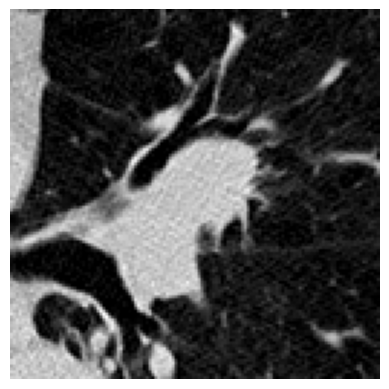

In [193]:
img_3d = batch.image.squeeze()

# Si el tensor está en GPU, muévelo a CPU y conviértelo a NumPy
if hasattr(img_3d, "cpu"):
    img_3d = img_3d.cpu().numpy()

# Visualiza un corte central a lo largo de la primera dimensión (profundidad)
slice_idx = img_3d.shape[0] // 2
plt.imshow(img_3d[slice_idx], cmap="gray")
plt.axis("off")
plt.show()

In [194]:
# Mover los tensores del batch al dispositivo (cuda:0)
image = batch.image.to(device)
spacing = batch.spacing.to(device)
transform = batch.transform.to(device)
center_vox = batch.center_vox.to(device)

# Ejecutar el extractor (o extractor(...) en lugar de extractor.forward)
out = extractor.forward(image, spacing, transform, center_vox)

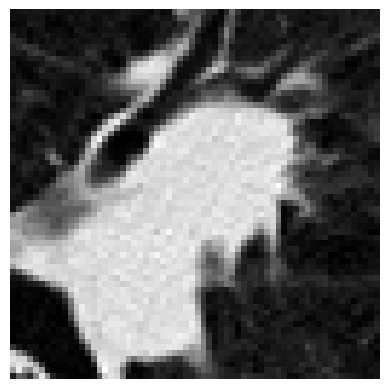

In [195]:
img_3d = out.squeeze()

# Si el tensor está en GPU, muévelo a CPU y conviértelo a NumPy
if hasattr(img_3d, "cpu"):
    img_3d = img_3d.cpu().numpy()

# Visualiza un corte central a lo largo de la primera dimensión (profundidad)
slice_idx = img_3d.shape[0] // 2
plt.imshow(img_3d[slice_idx], cmap="gray")
plt.axis("off")
plt.show()

In [196]:
img_3d.shape

(64, 64, 64)

## Comparar caracteristicas

In [197]:
analisis_imagenes["seg_ok"].value_counts(normalize=True).to_frame(
    name="proporcion"
).T

seg_ok,True,False
proporcion,0.998053,0.001947


In [198]:
nulos_por_columna_filt = (
    analisis_imagenes[analisis_imagenes["seg_ok"] == False]  # noqa: E712
    .isna()
    .sum()
    .sort_values(ascending=False)
)
con_nulos = nulos_por_columna_filt[nulos_por_columna_filt > 0]
display(con_nulos.to_frame(name="nulos"))
print(
    f"Cantidad de columnas con nulos en nódulos con segmentación fallida: {len(con_nulos)}"  # noqa: E501
)

,nulos
hu_p50,12
hu_mean,12
hu_range_p10_p90,12
hu_max,12
frac_air,12
frac_ggo,12
frac_soft,12
frac_calcified,12
contrast_hu,12
hu_p90,12


Cantidad de columnas con nulos en nódulos con segmentación fallida: 15


In [199]:
nulos_por_columna_filt = (
    analisis_imagenes[analisis_imagenes["seg_ok"] == True]  # noqa: E712
    .isna()
    .sum()
    .sort_values(ascending=False)
)
con_nulos = nulos_por_columna_filt[nulos_por_columna_filt > 0]
display(con_nulos.to_frame(name="nulos"))
print(
    f"Cantidad de columnas con nulos en nódulos con segmentación fallida (en seg ok = True): {len(con_nulos)}"  # noqa: E501
)

,nulos


Cantidad de columnas con nulos en nódulos con segmentación fallida (en seg ok = True): 0


In [200]:
size_prev = analisis_imagenes.shape[0]

In [201]:
analisis_imagenes.dropna(inplace=True)

In [202]:
analisis_imagenes.isna().sum().sum()

np.int64(0)

In [203]:
size_post = analisis_imagenes.shape[0]

In [204]:
reduccion_pct = ((size_prev - size_post) / size_prev) * 100
print(f"Reducción: {reduccion_pct:.2f}%")

Reducción: 0.19%


La reduccion de nodulos que no fueron posibles de segmentar es insignificante, por lo que se sigue sin ningun problema con el analisis de caracteristicas morfologicas detectadas

In [205]:
interesting_cols = config.INTERESTING_COLS

In [206]:
analisis_imagenes["frac_air"].value_counts(normalize=True).to_frame(
    name="proporcion"
).T

frac_air,0.0
proporcion,1.0


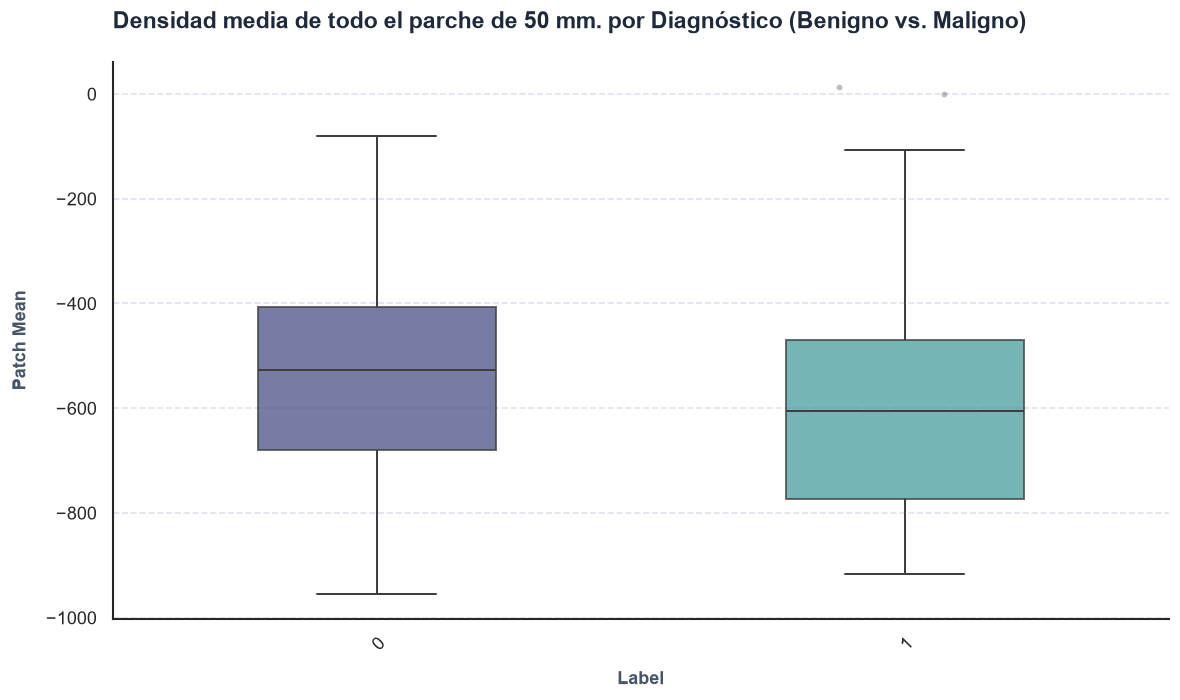

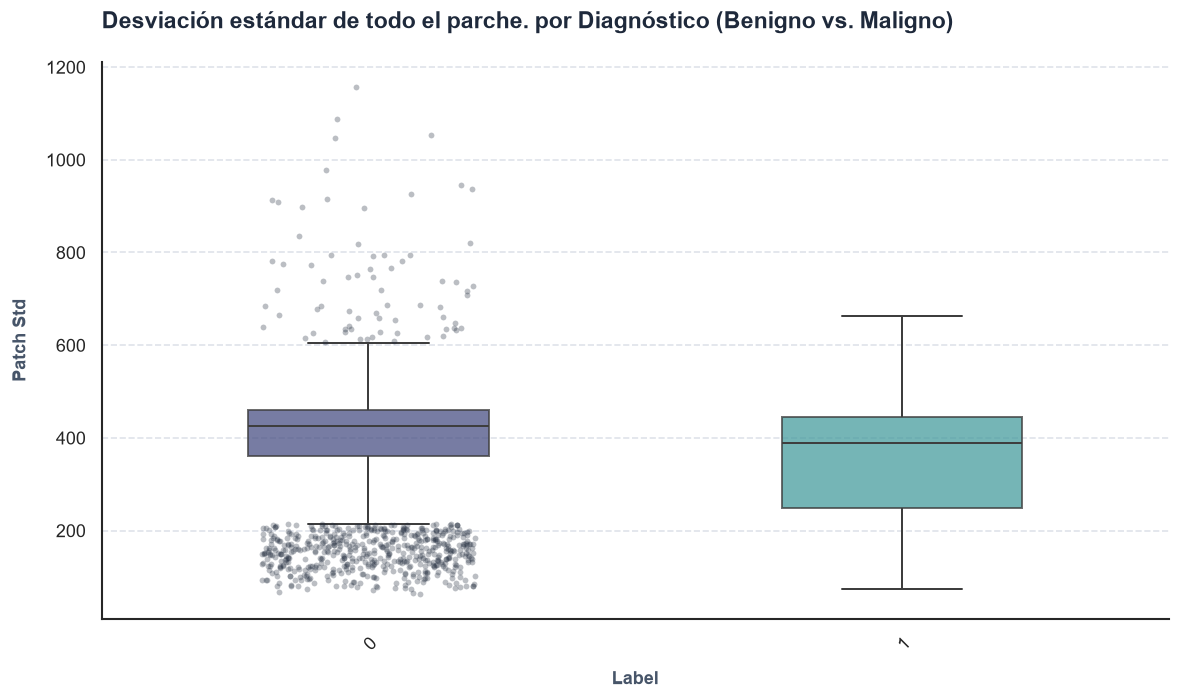

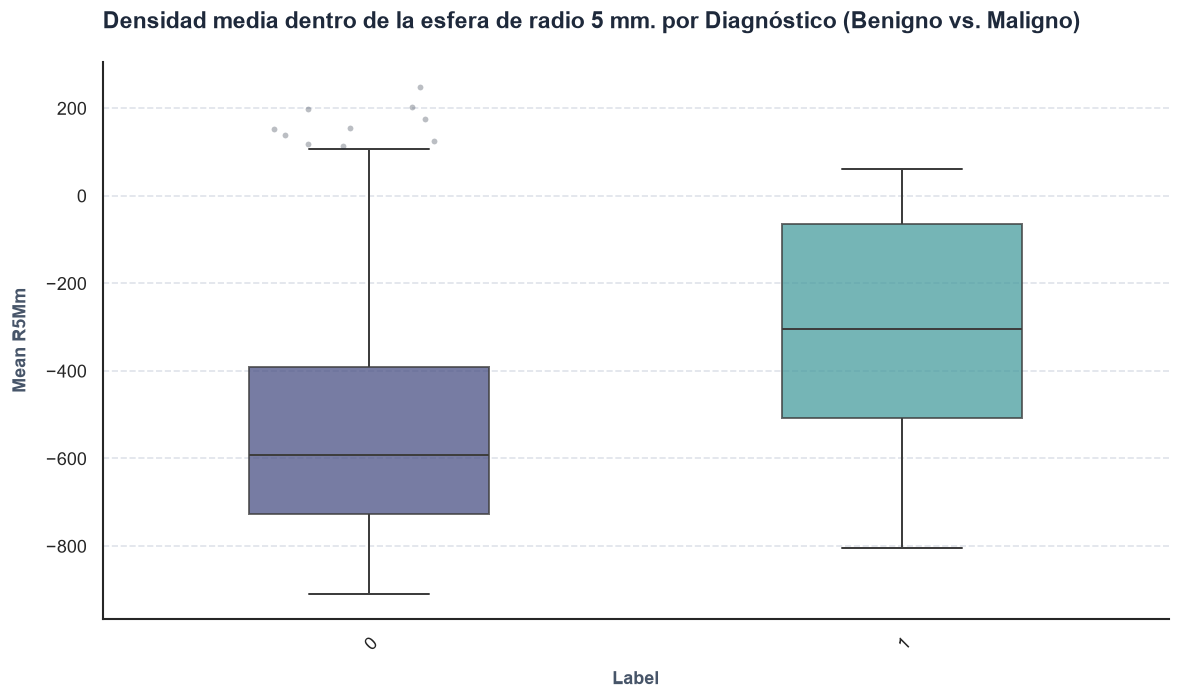

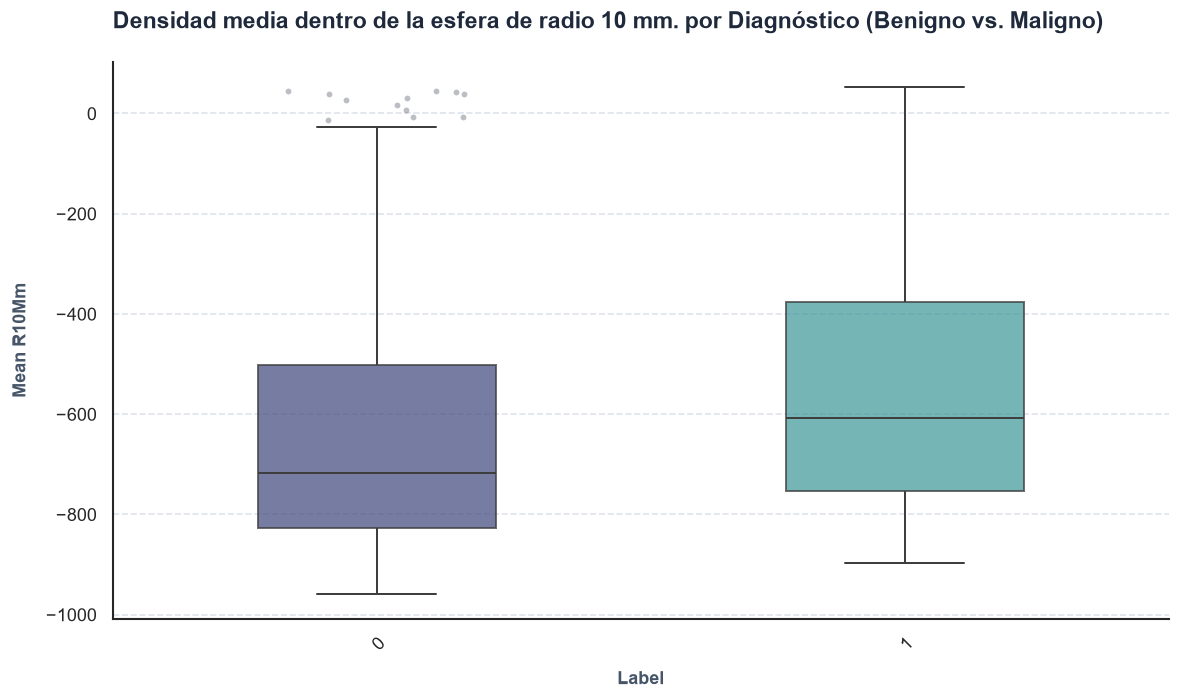

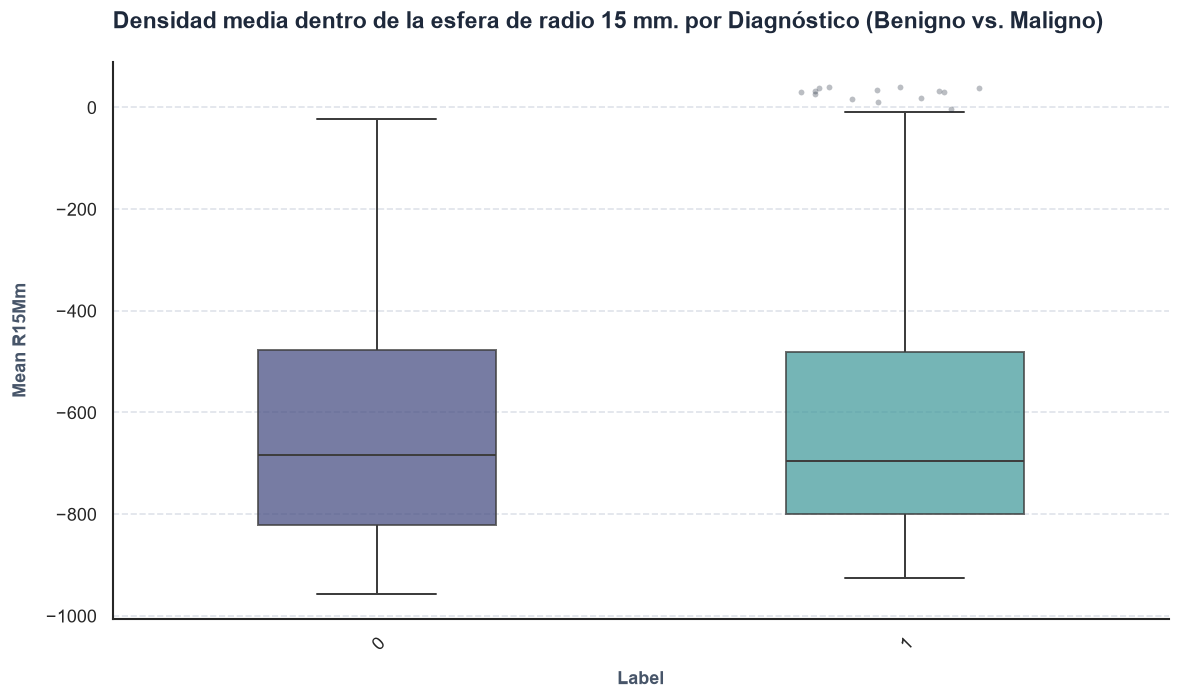

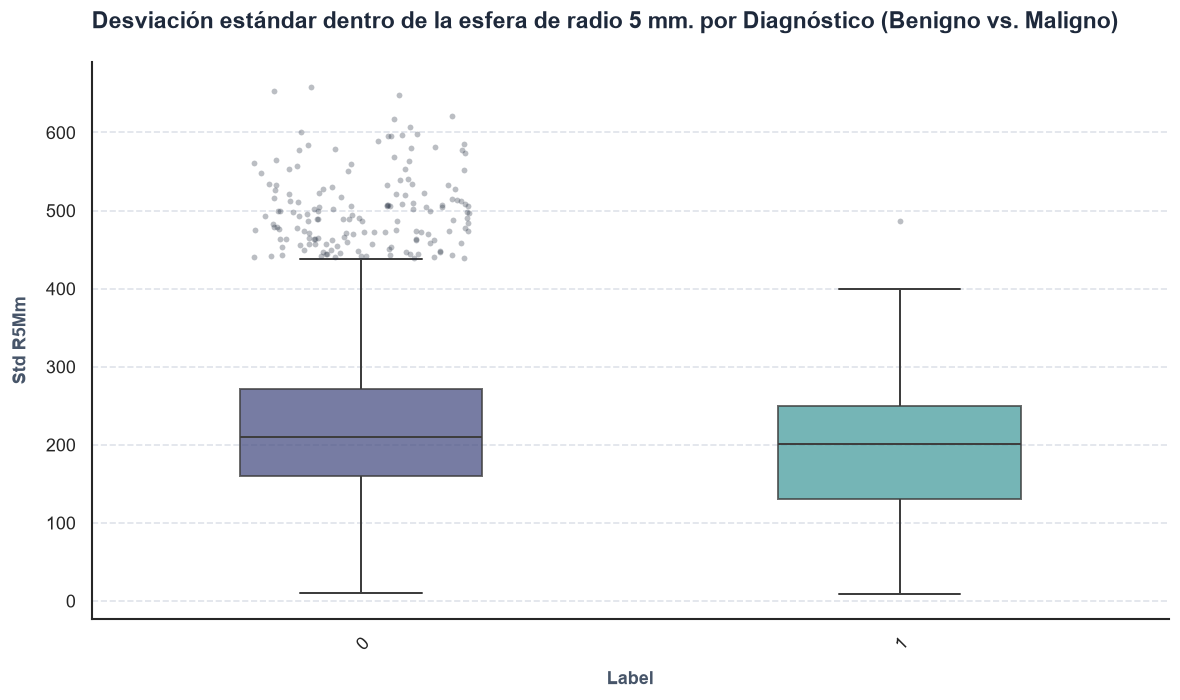

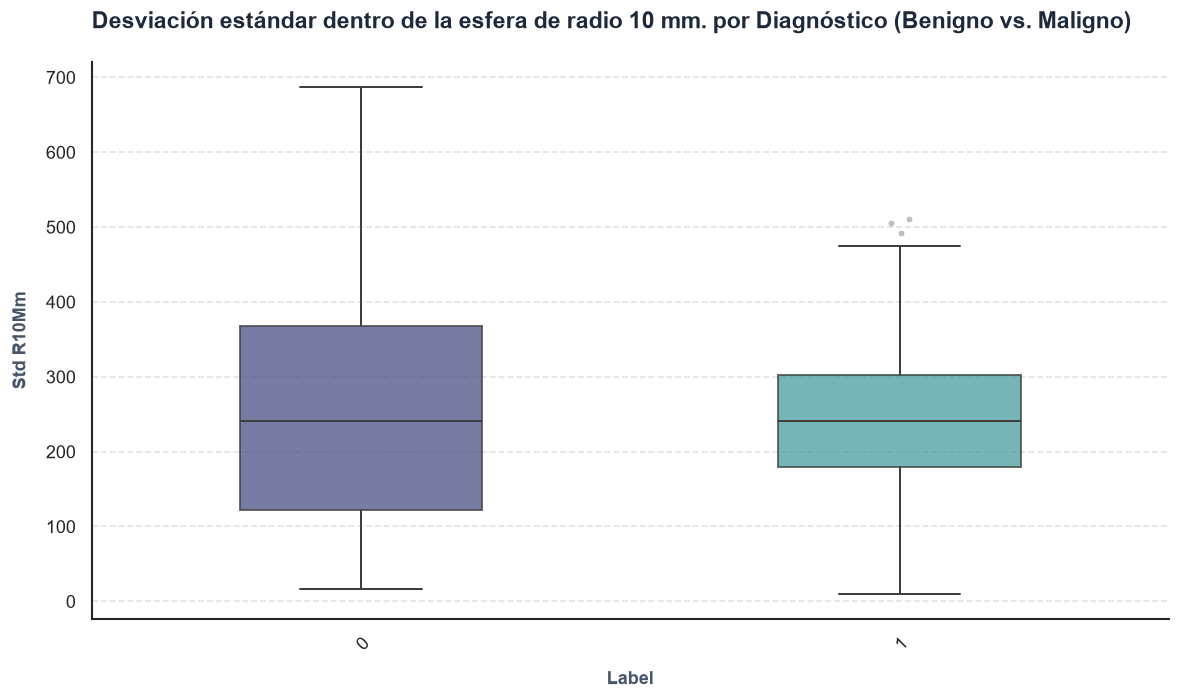

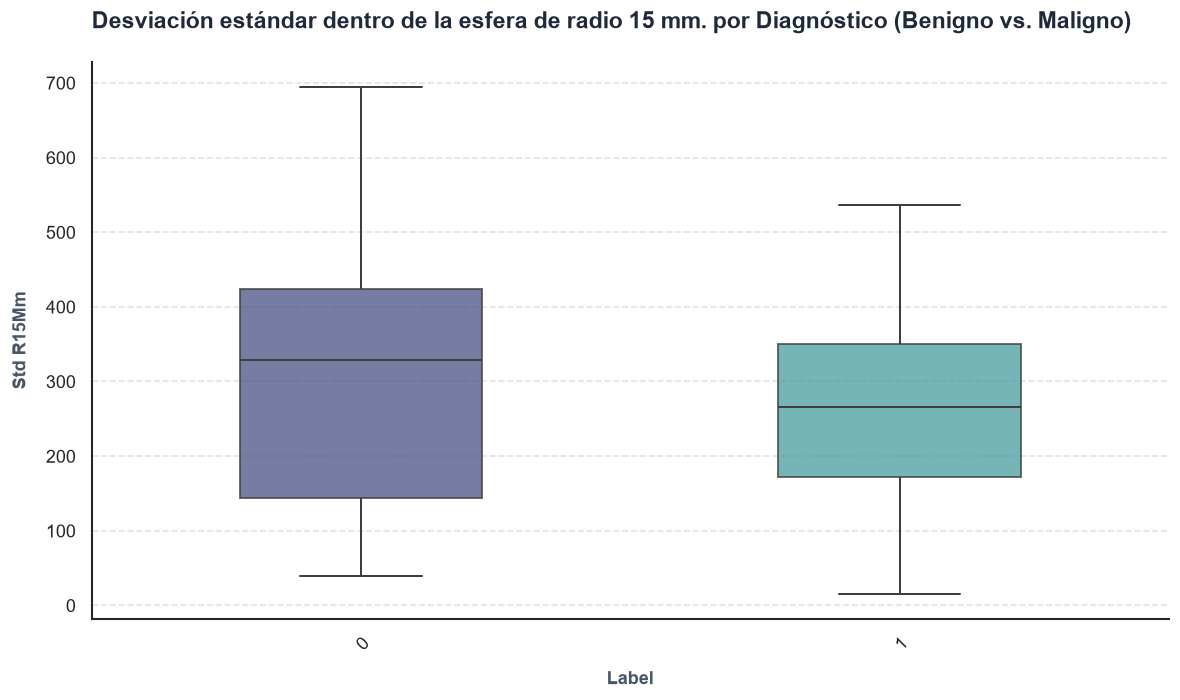

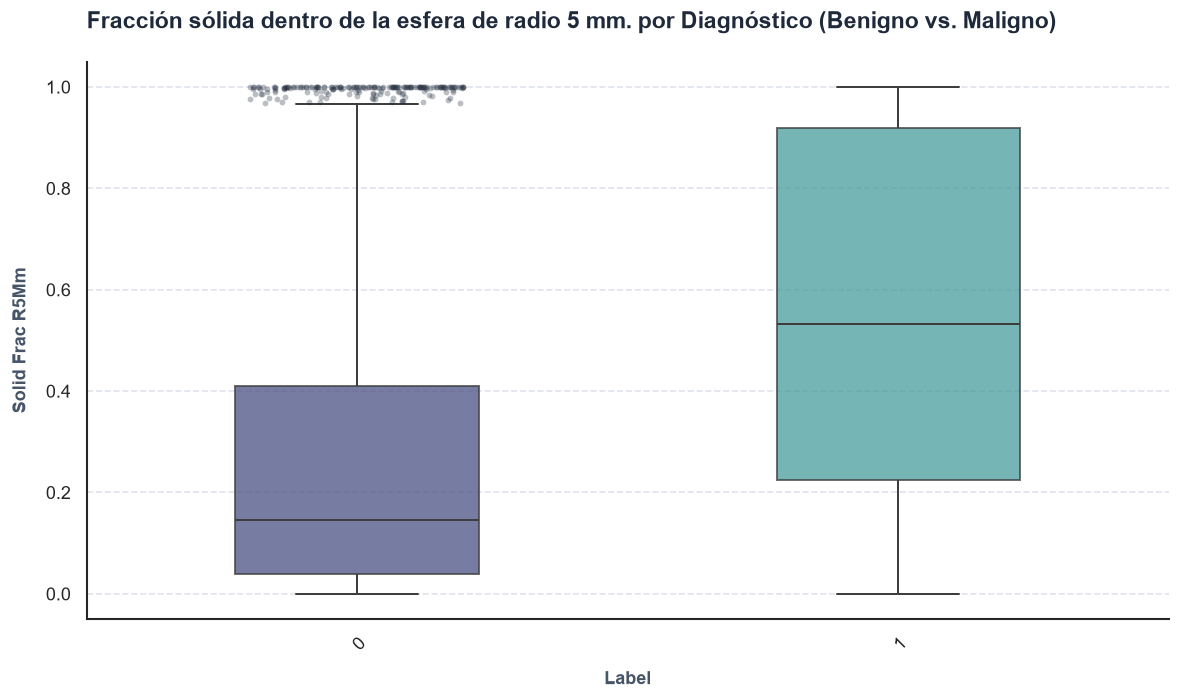

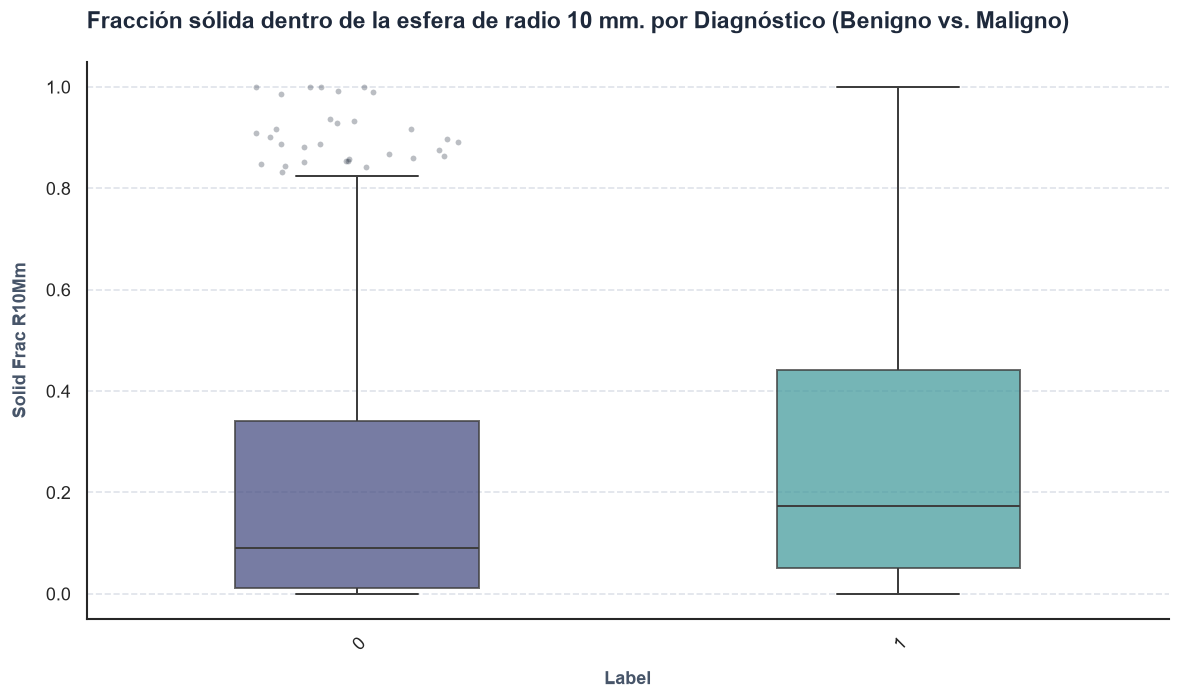

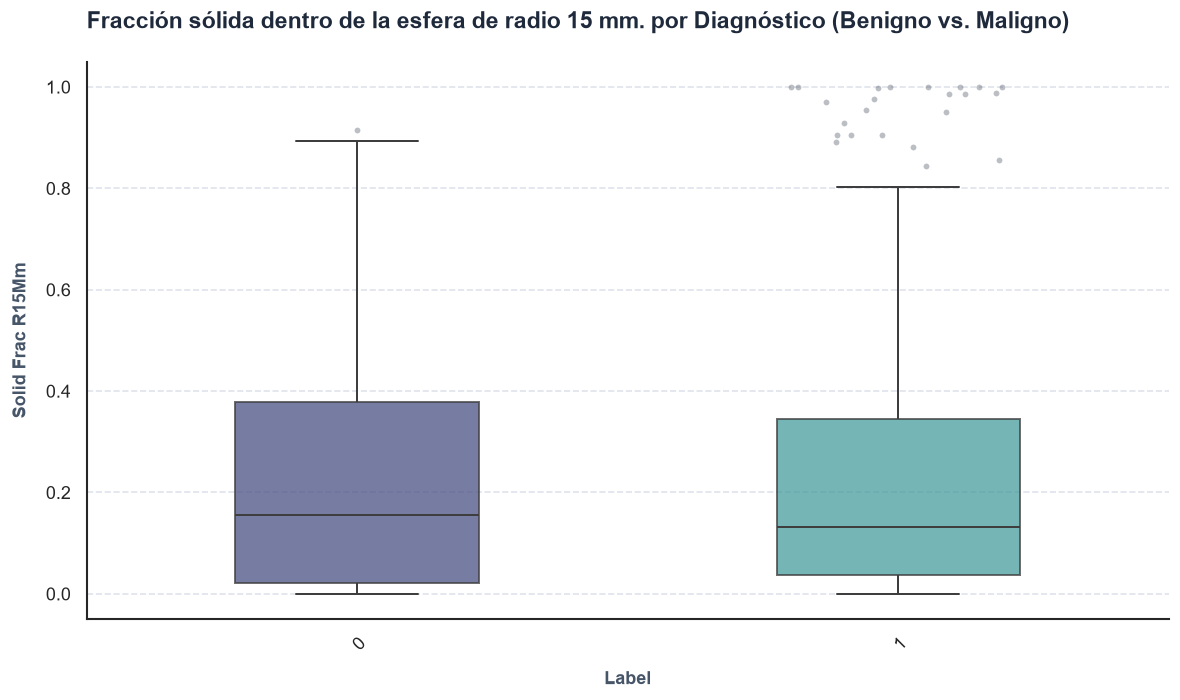

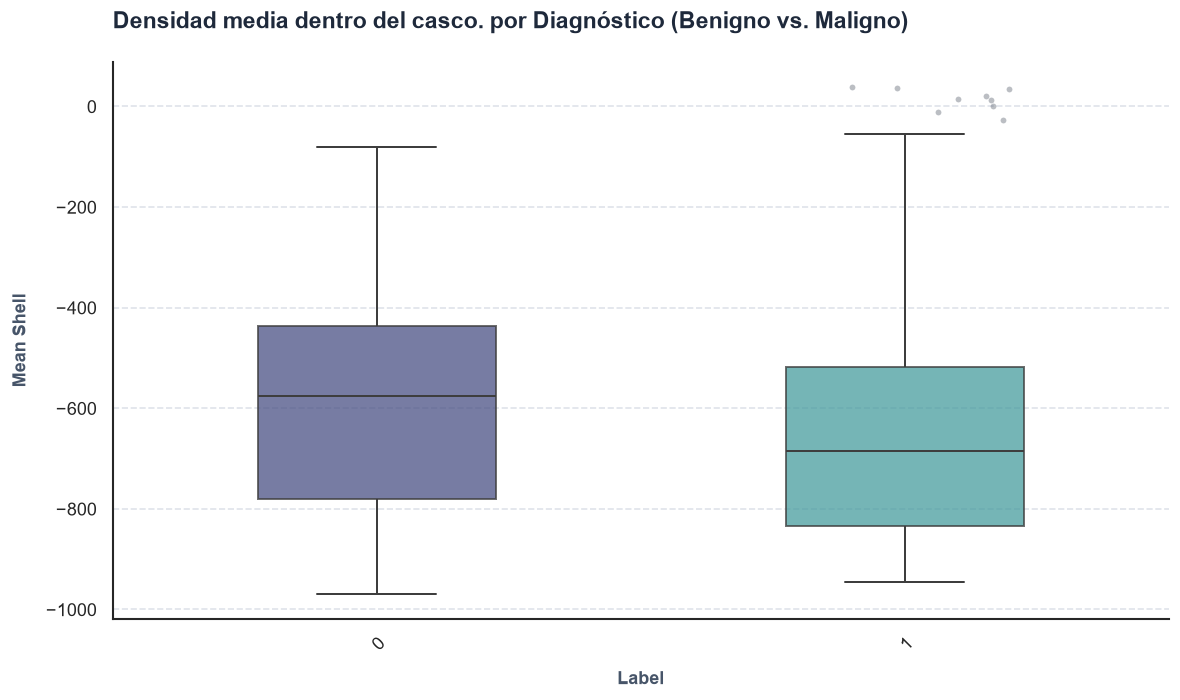

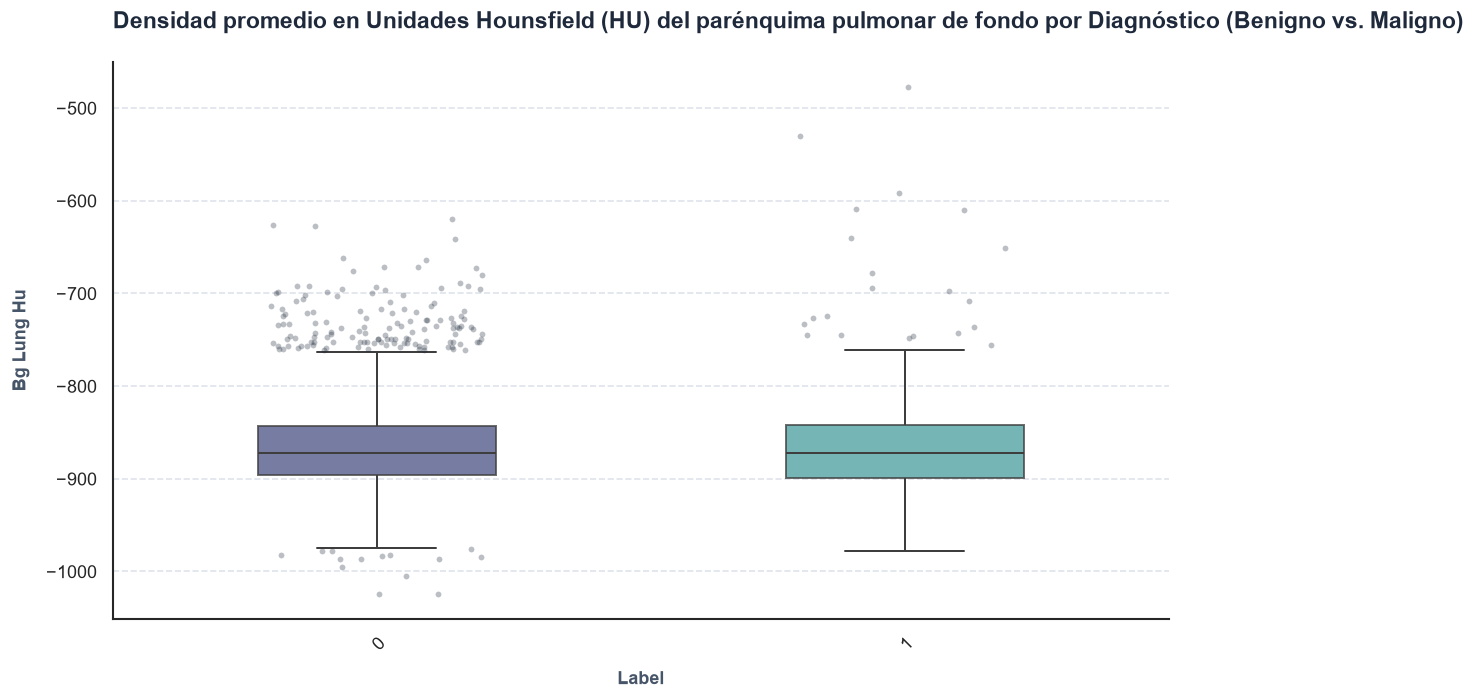

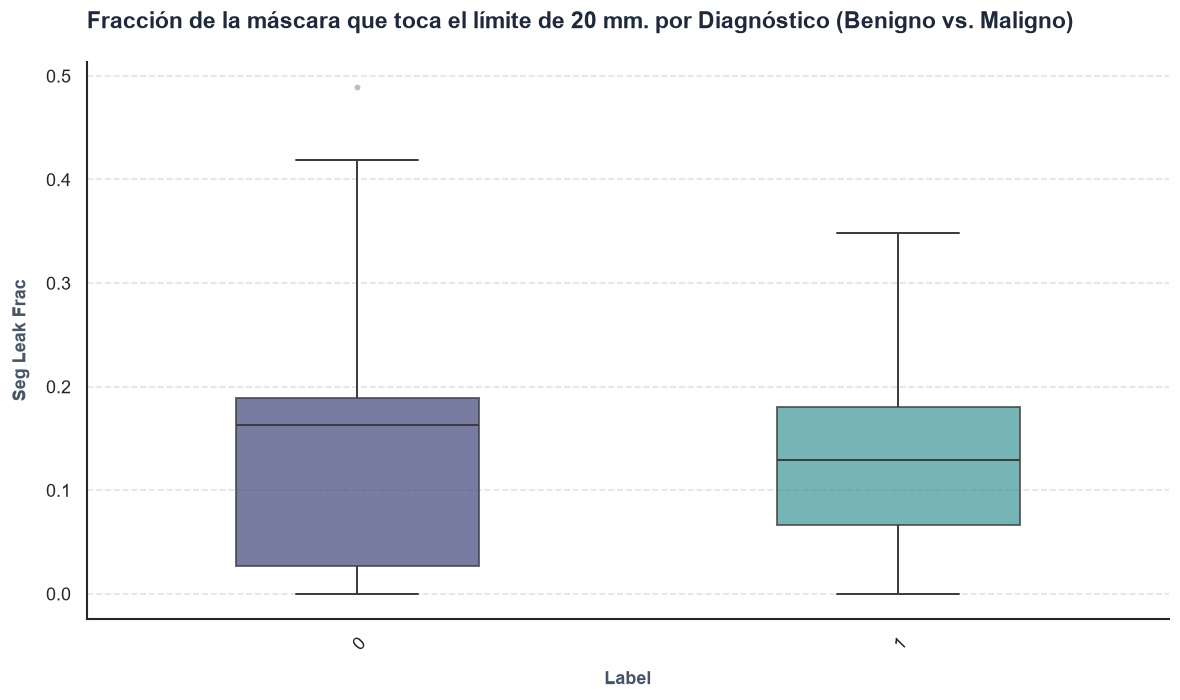

Columna seg_ok es constante, se omite.


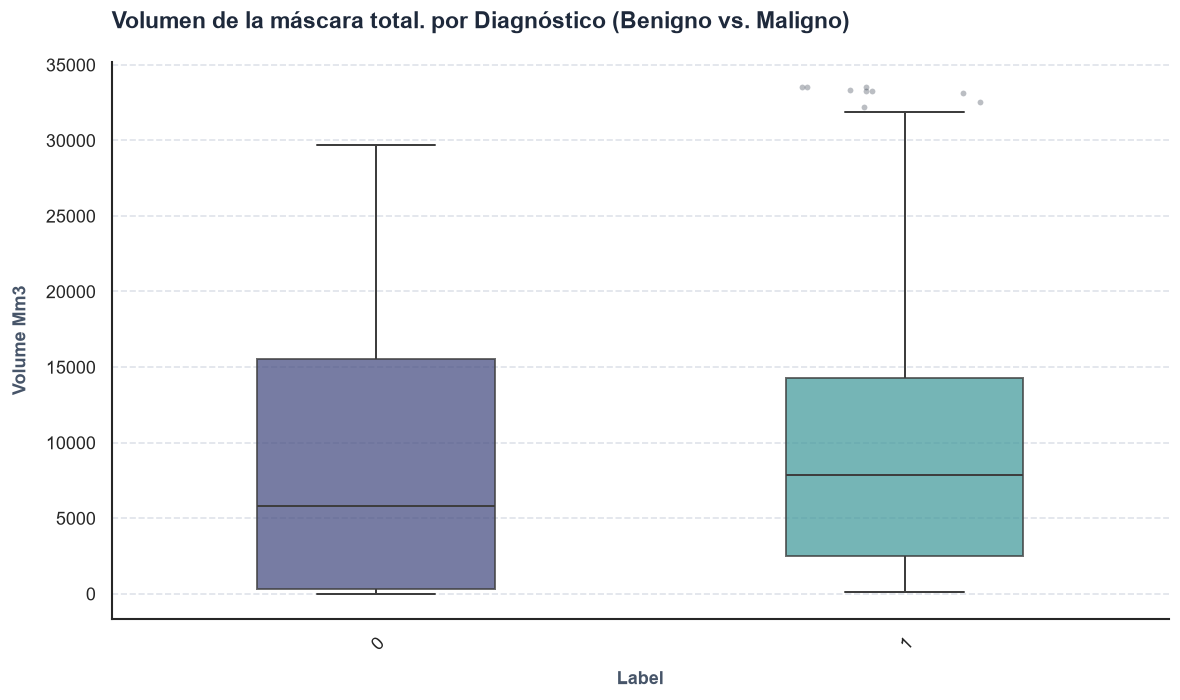

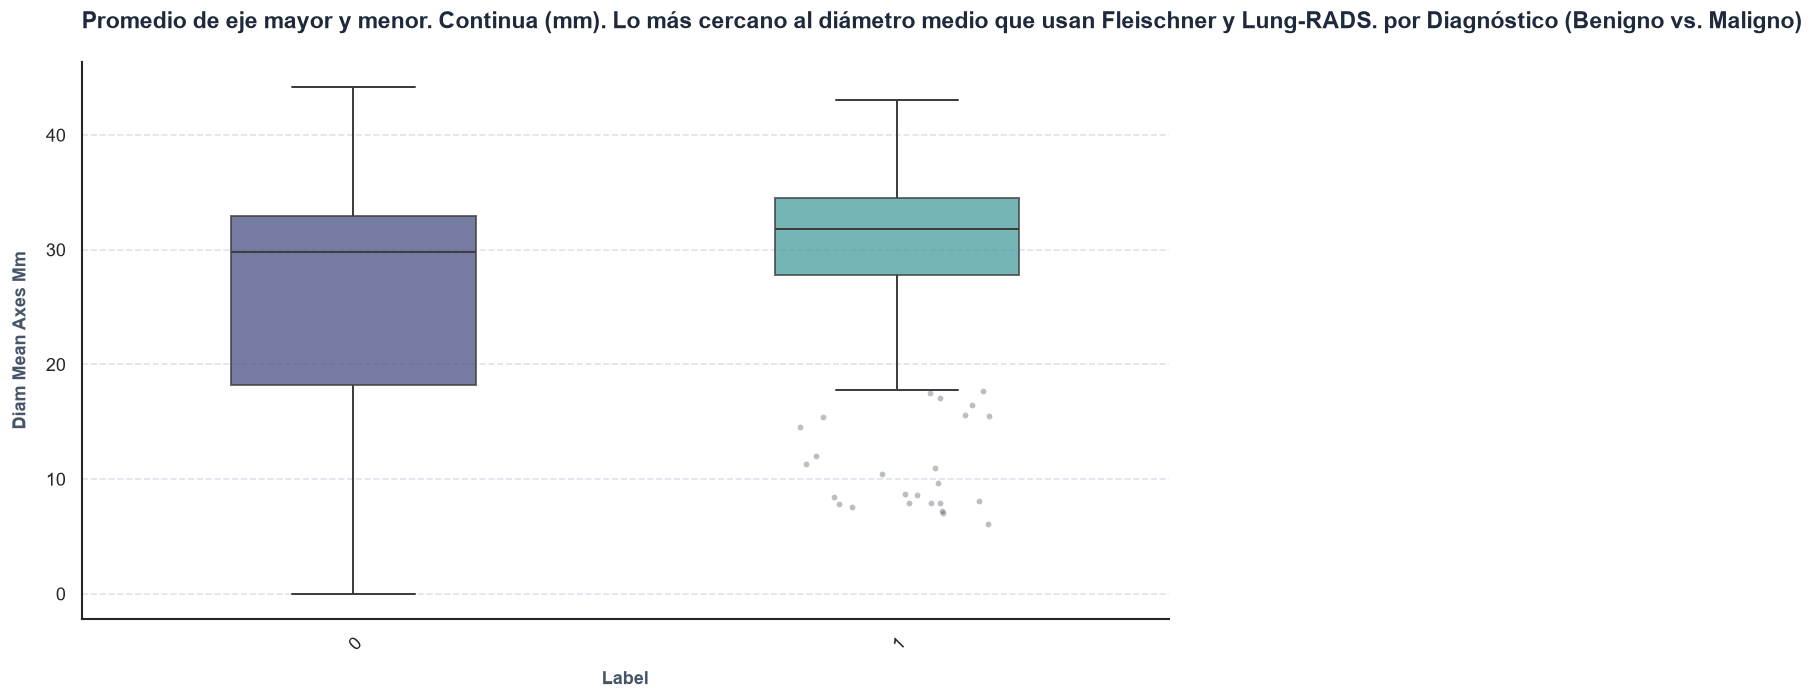

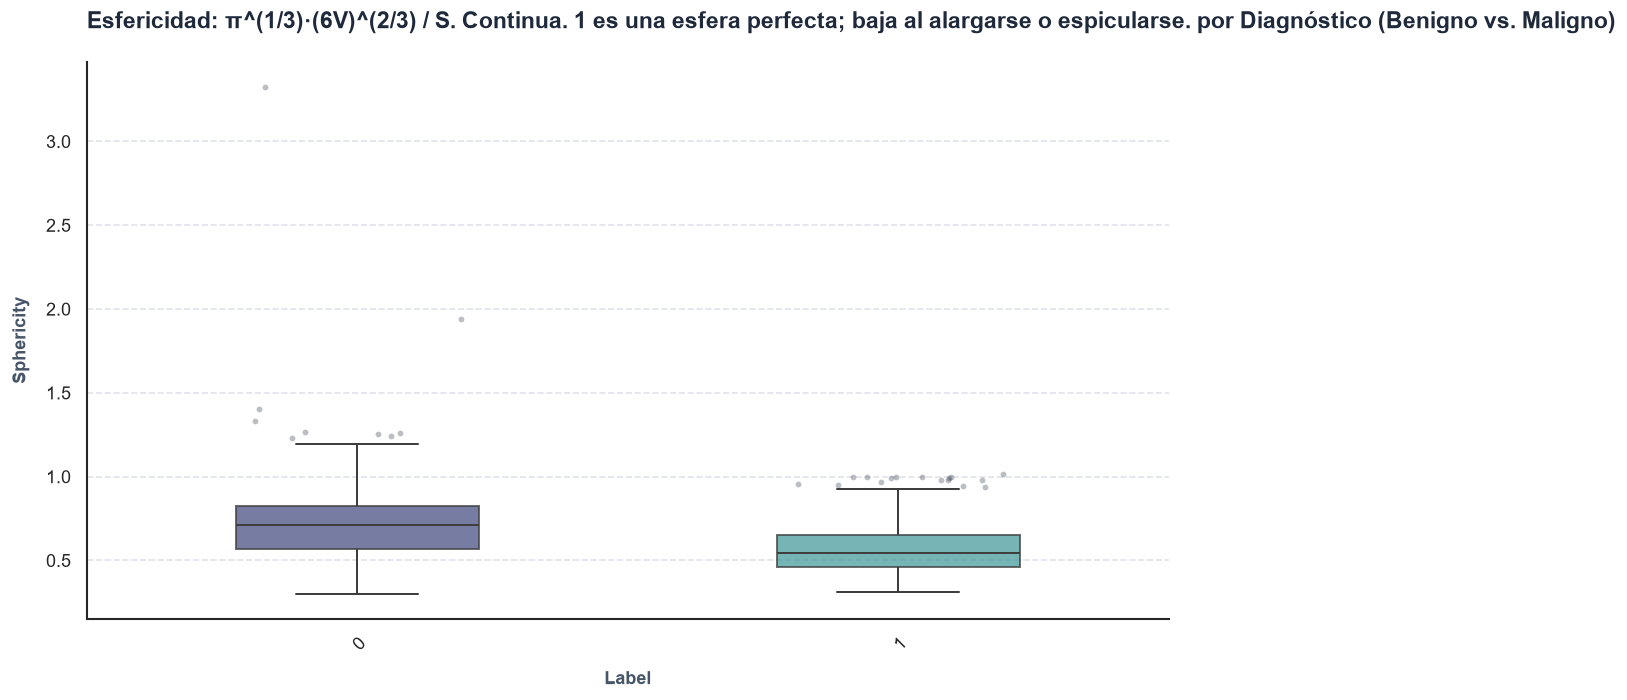

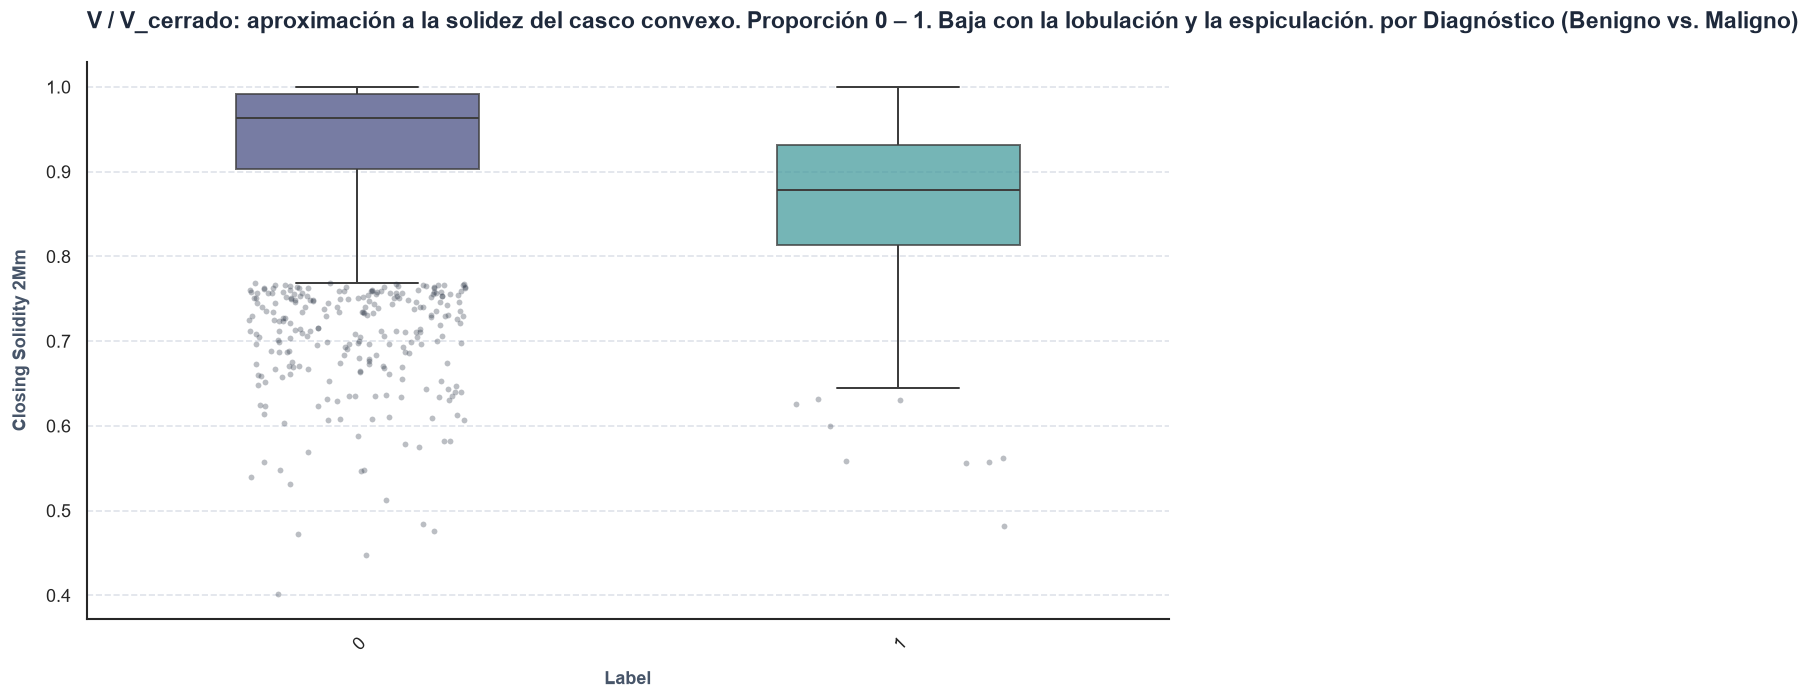

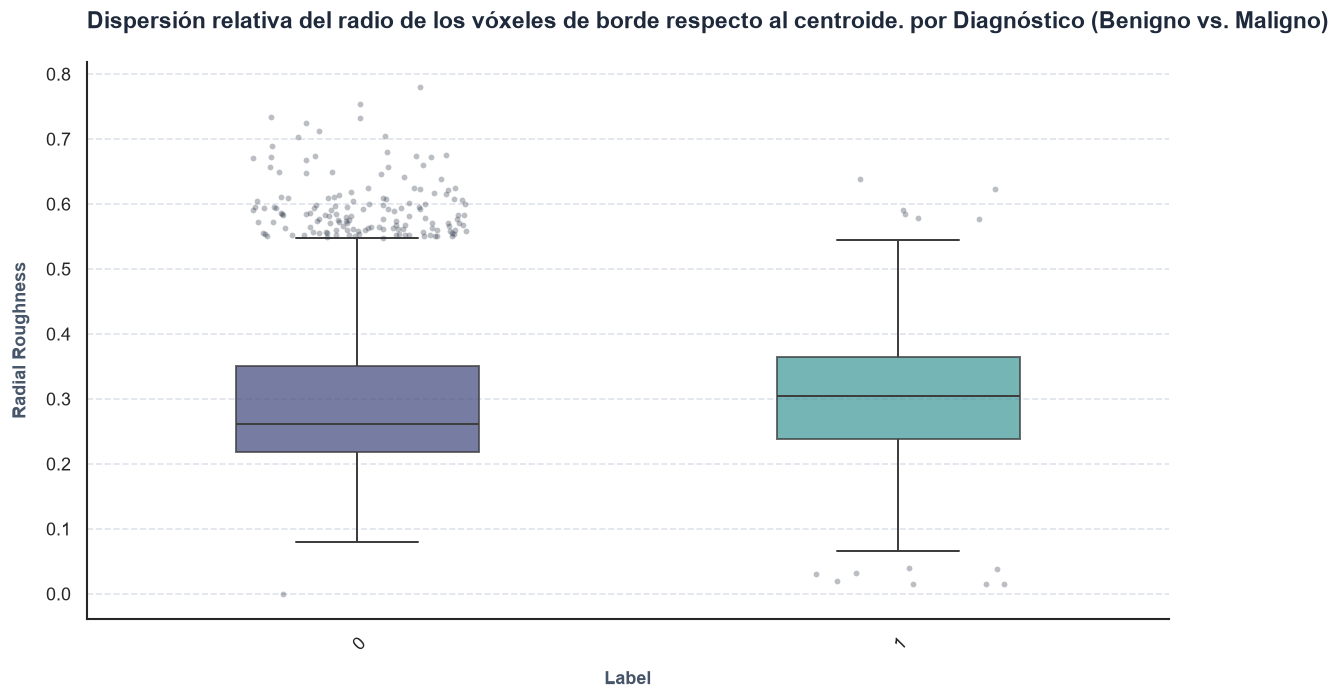

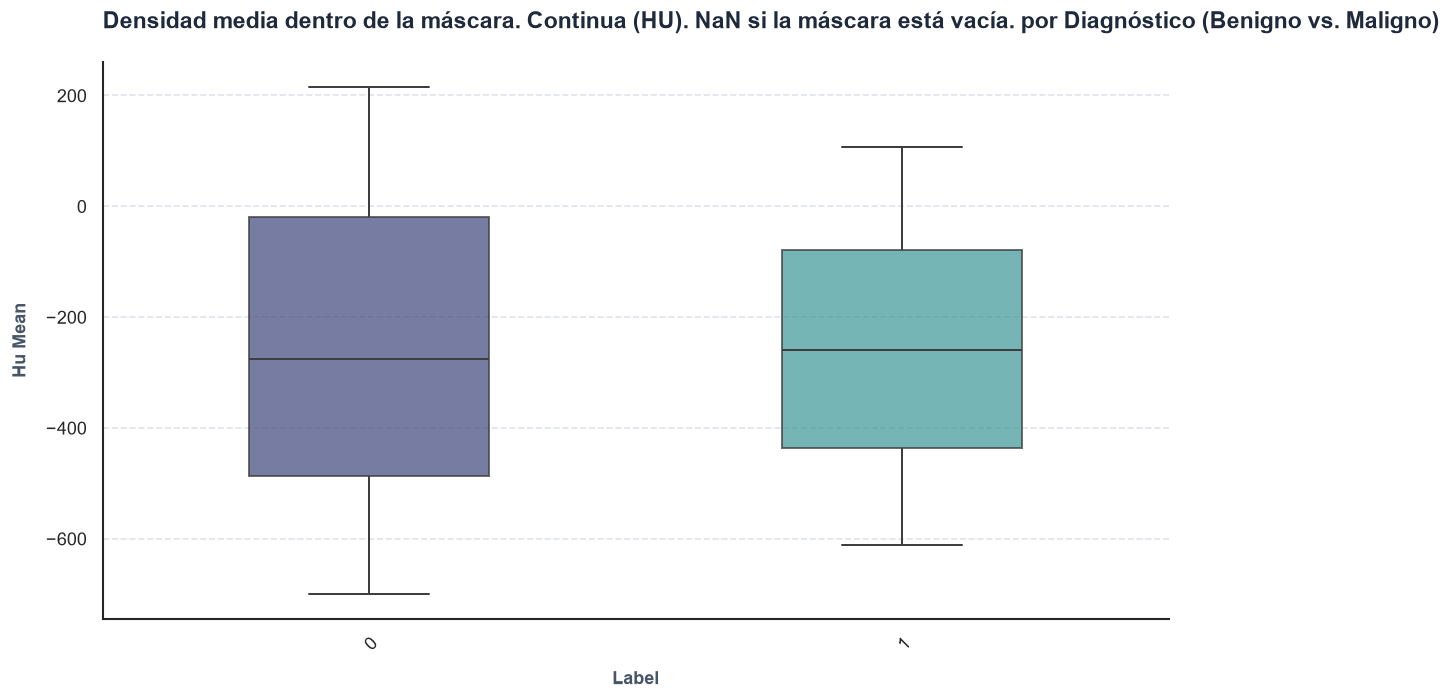

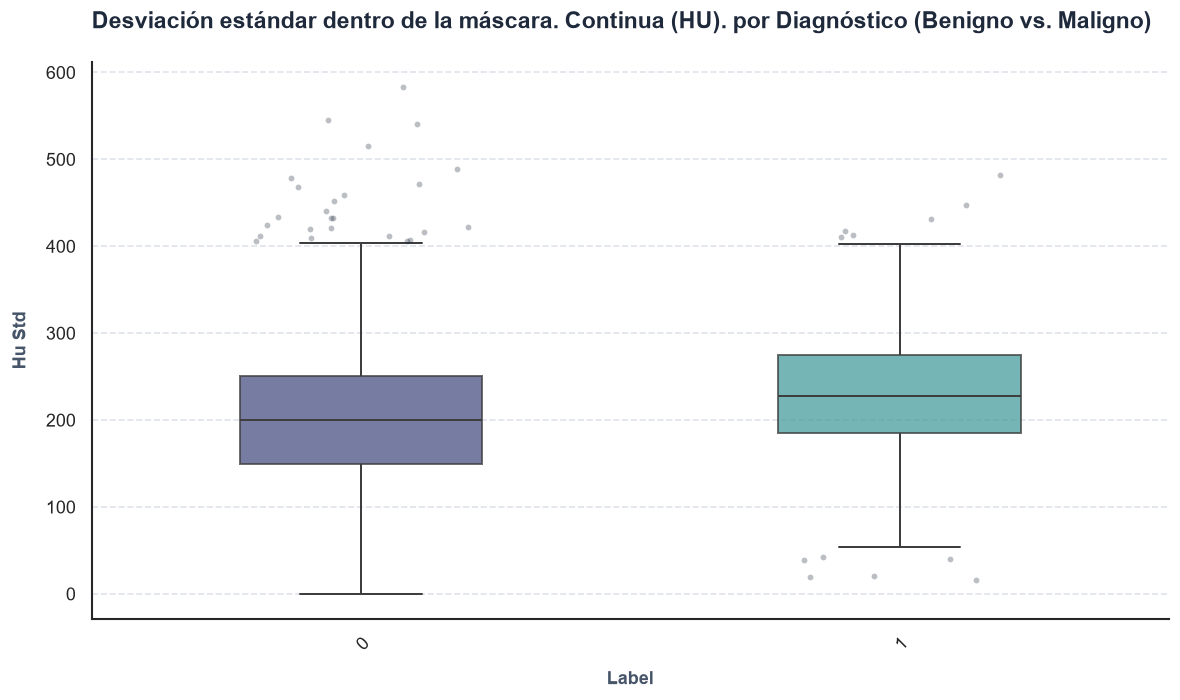

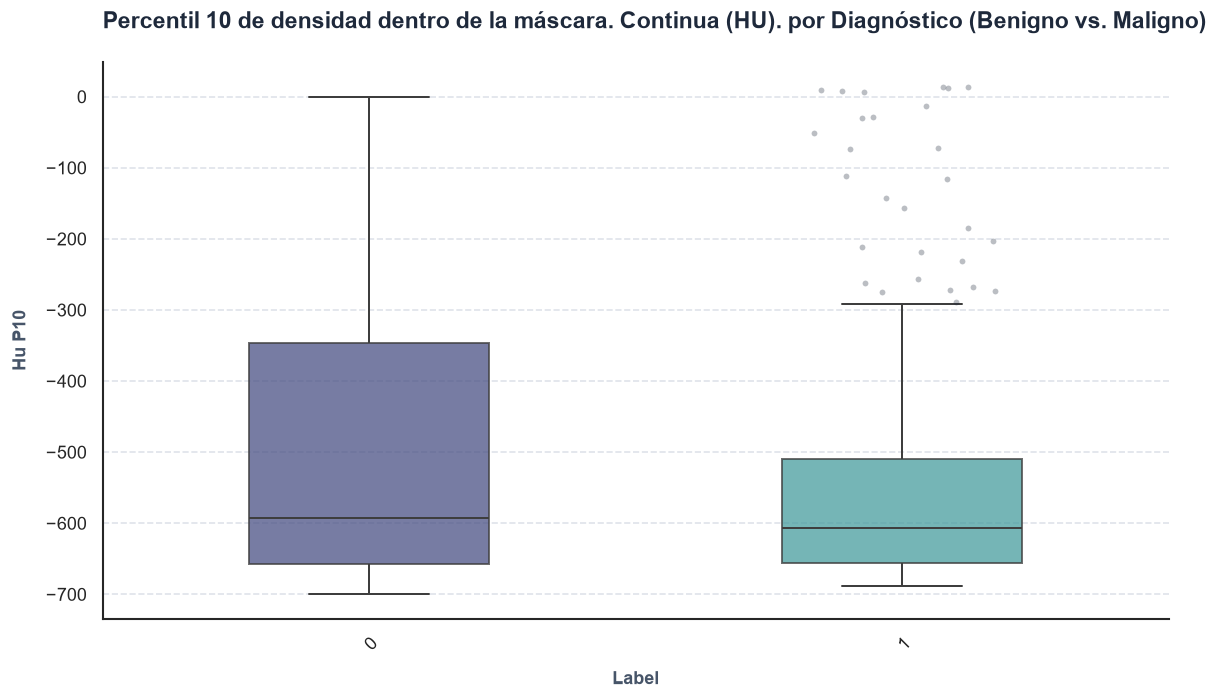

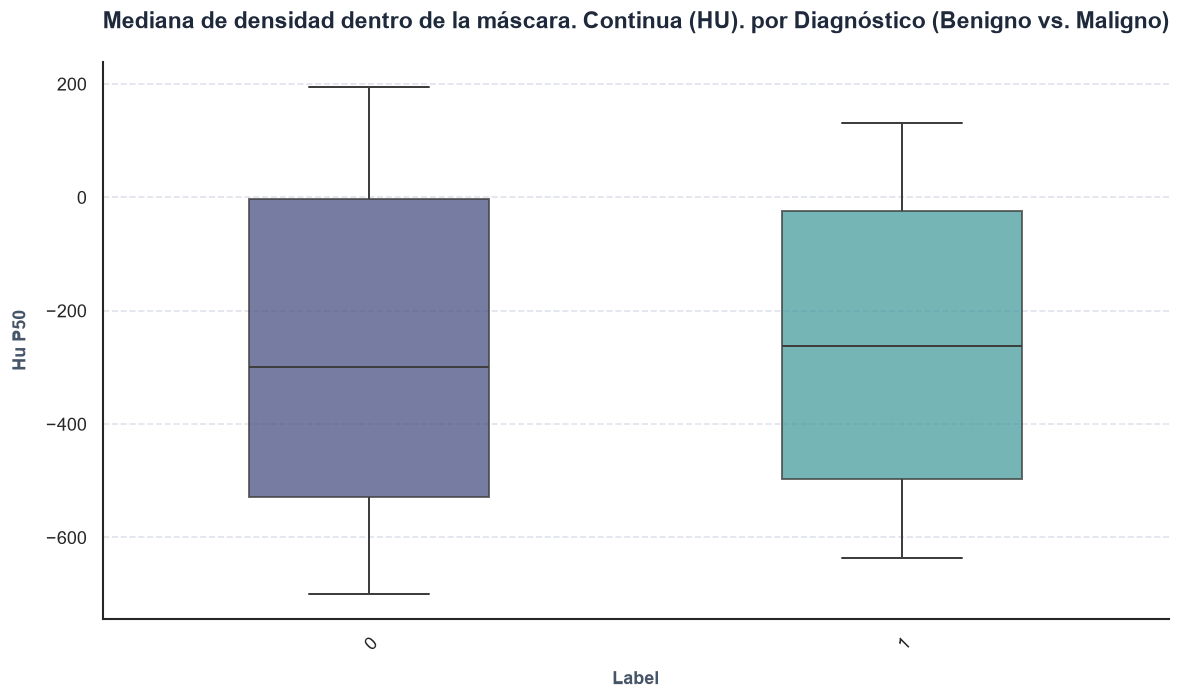

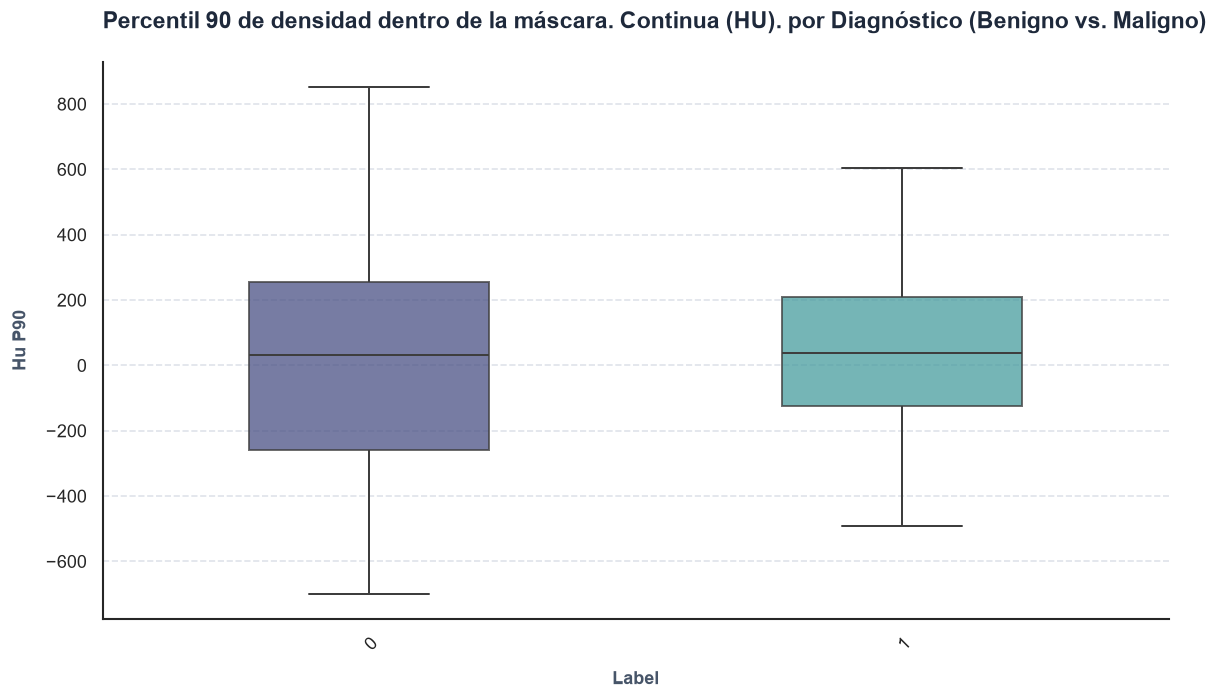

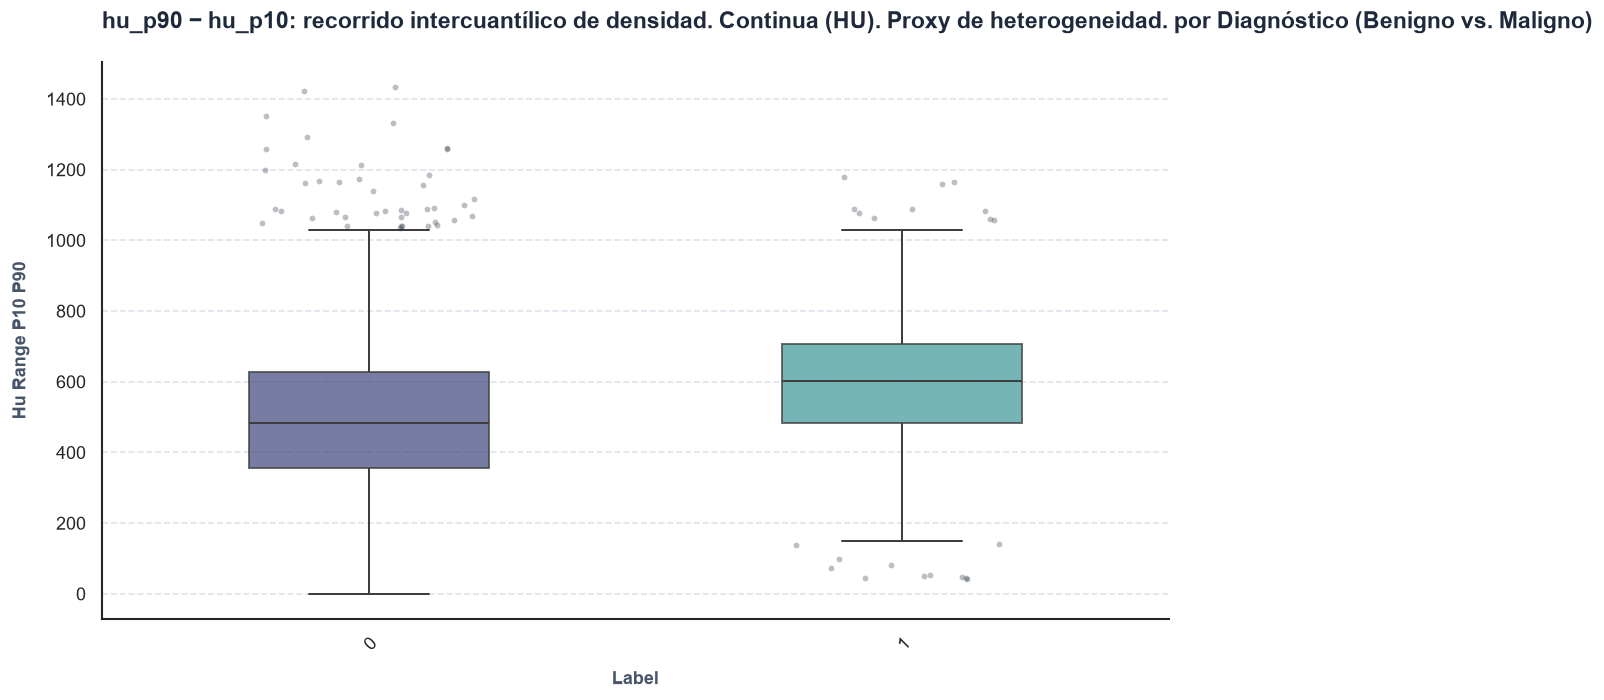

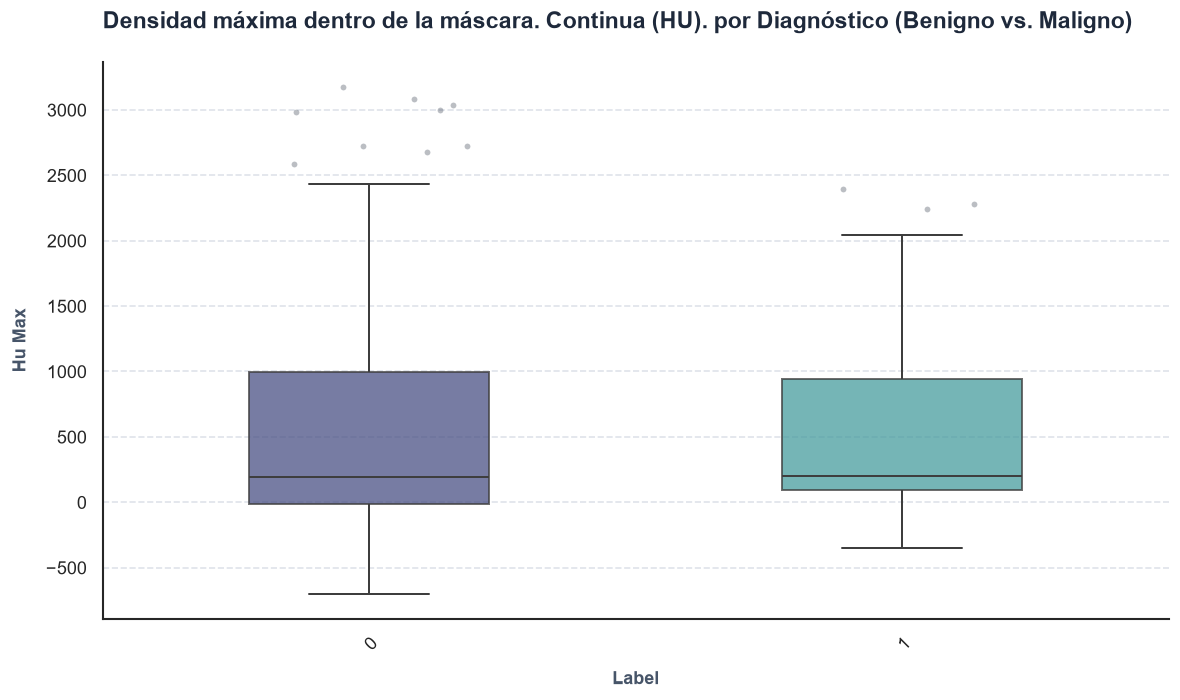

Columna frac_air es constante, se omite.


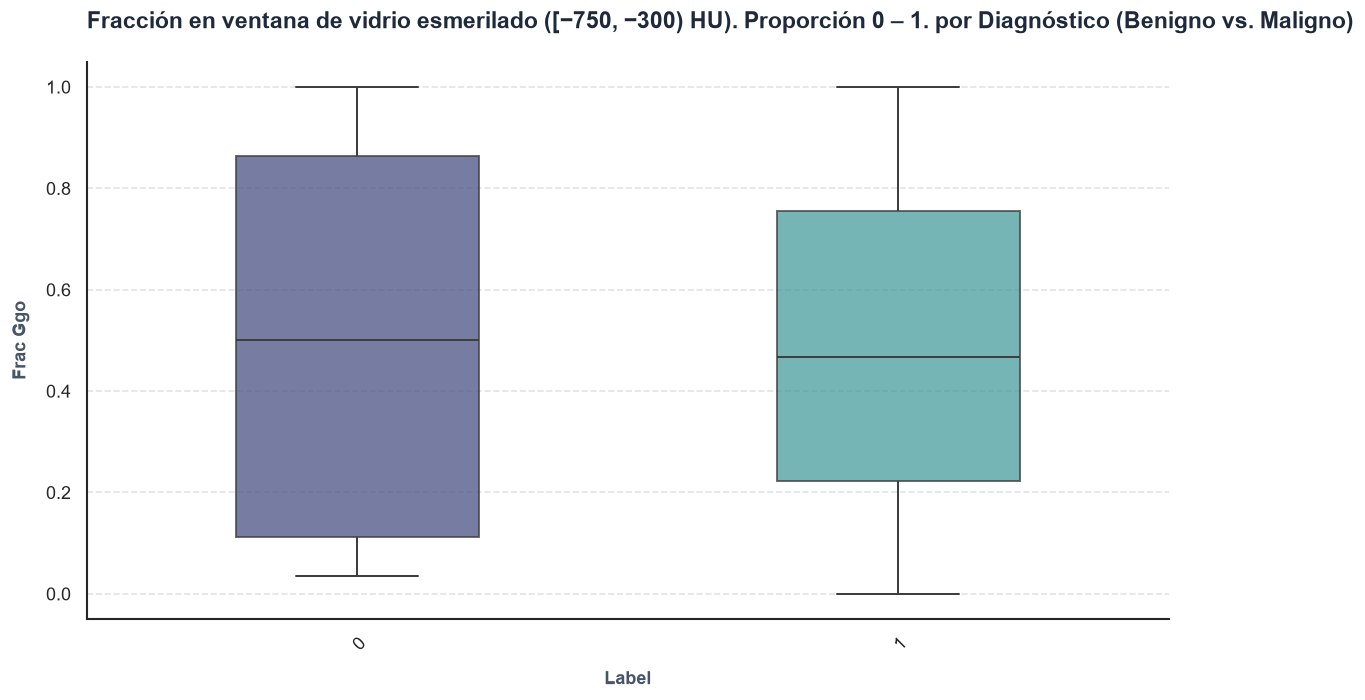

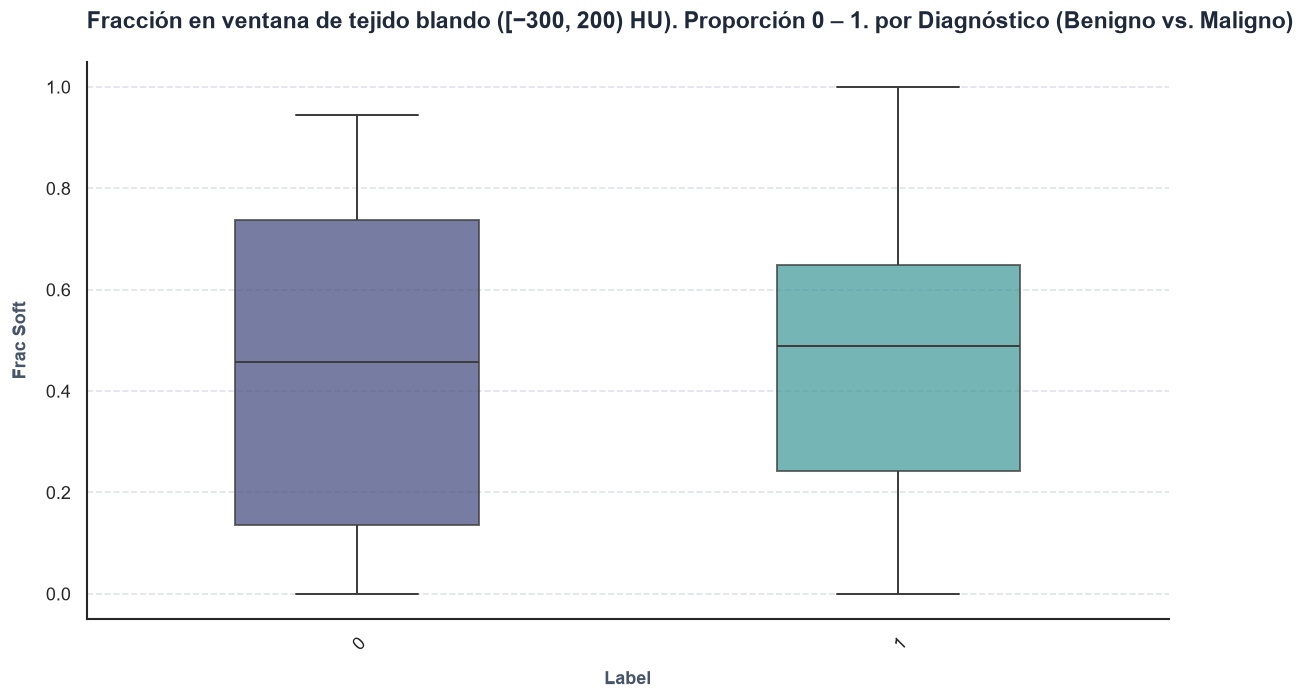

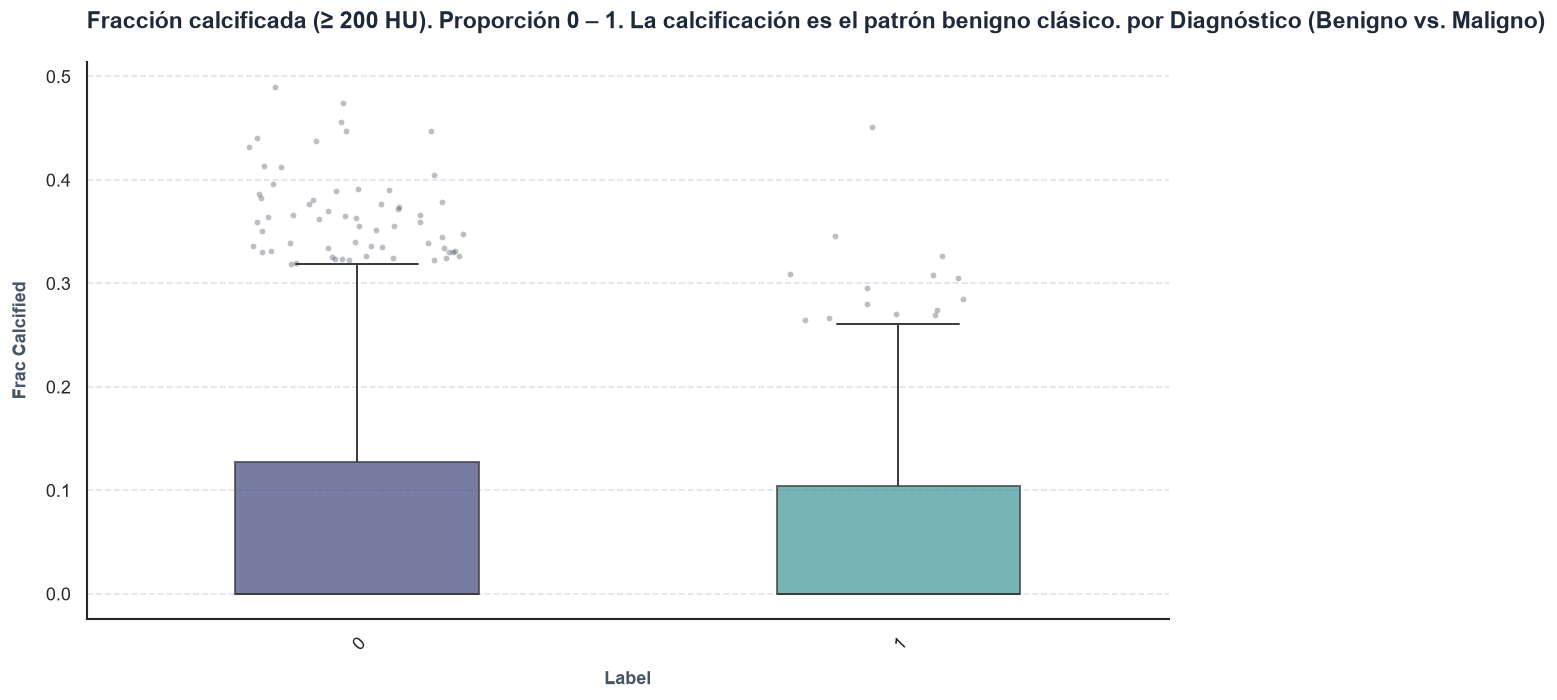

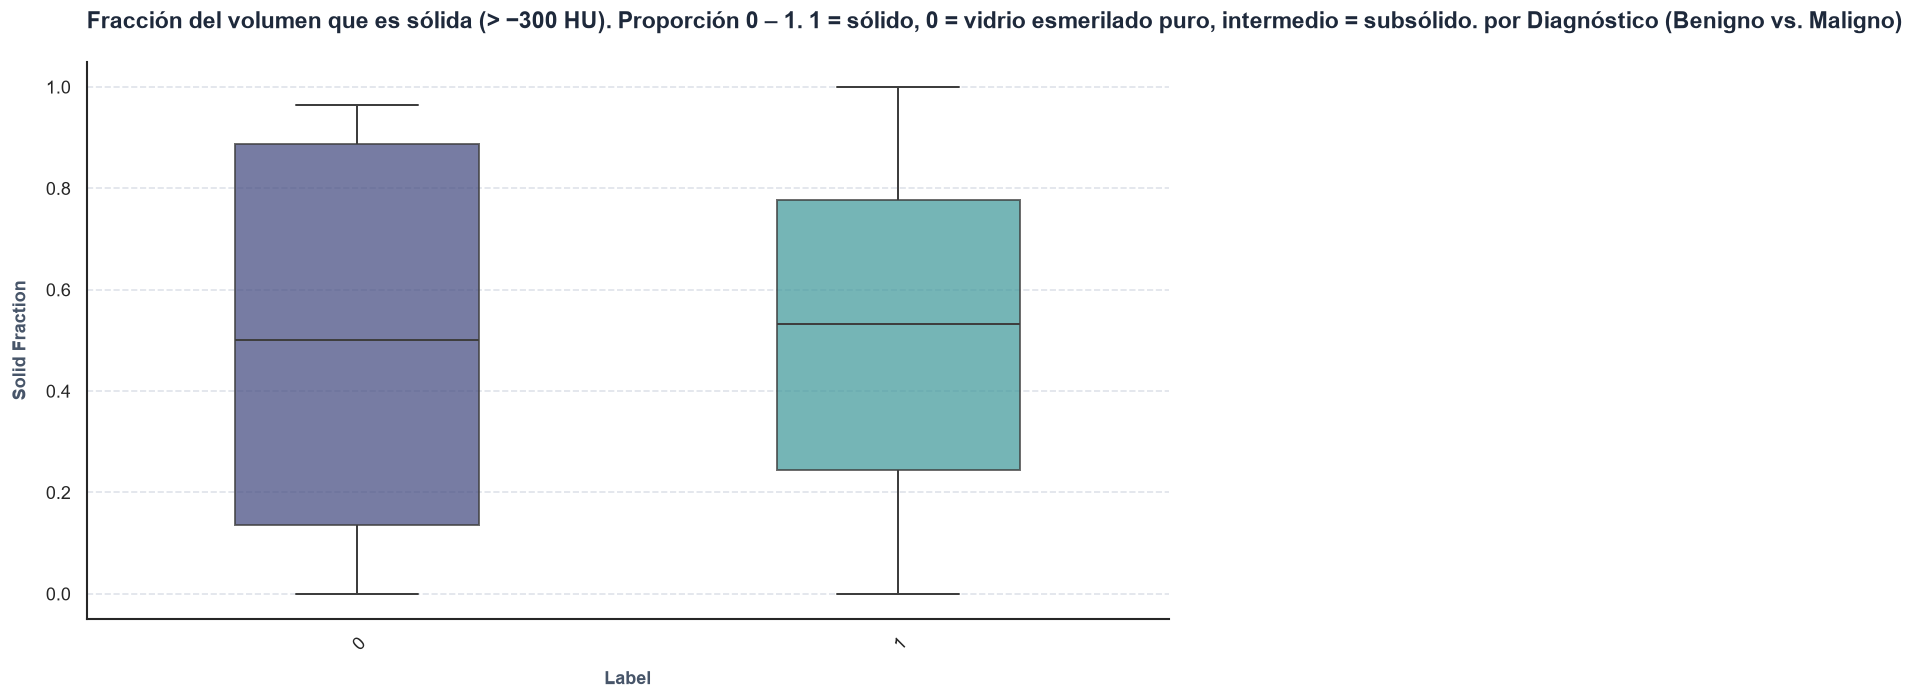

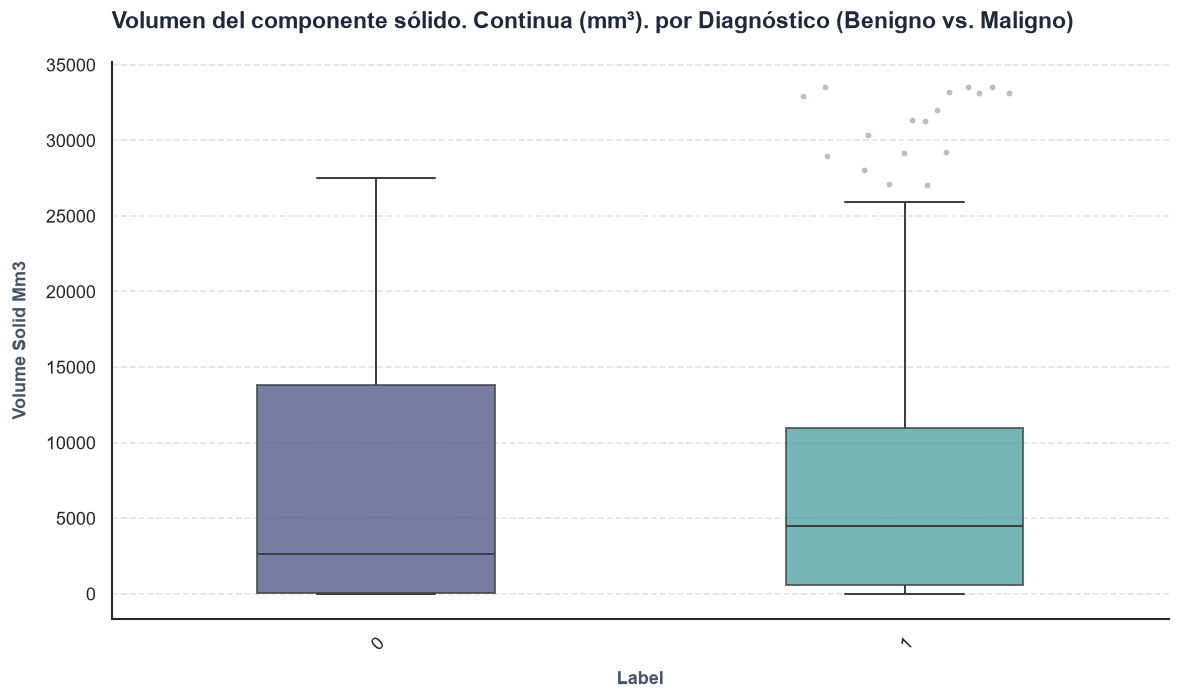

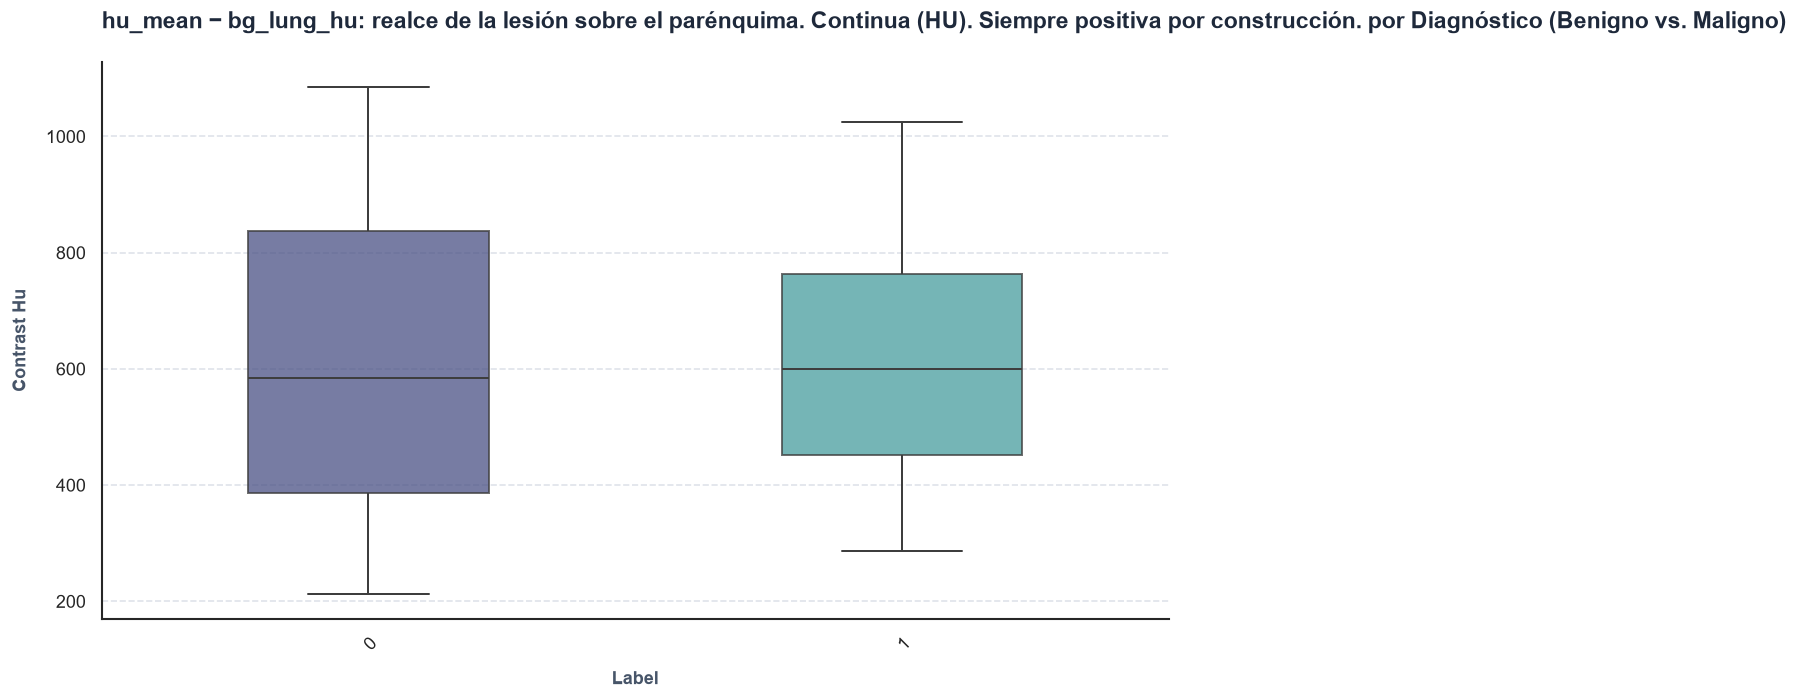

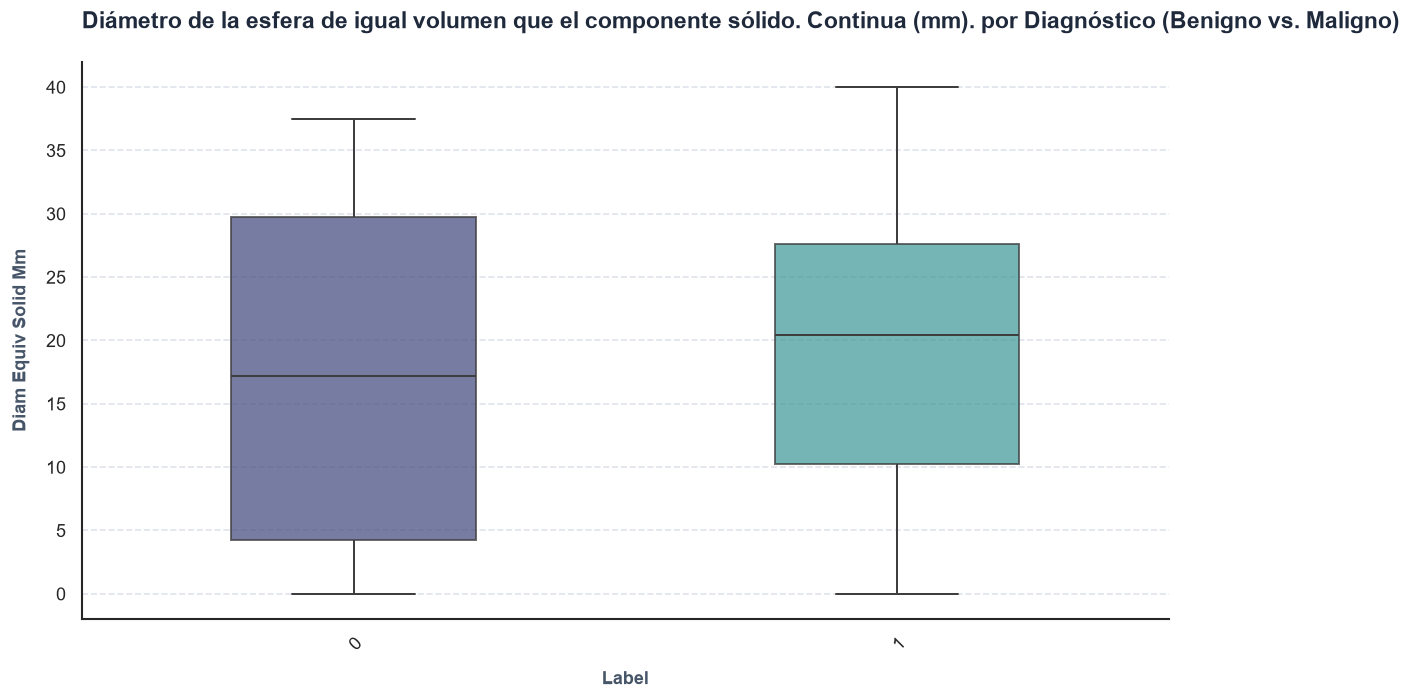

In [207]:
for col, subtitle in interesting_cols.items():
    if col not in analisis_imagenes.columns:
        print(f"Columna {col} no encontrada en el DataFrame.")
        continue
    # Un boxplot de una columna con un solo valor es una línea plana: no
    # aporta nada. Pasa con seg_ok y frac_air después del dropna.
    if analisis_imagenes[col].nunique() <= 1:
        print(f"Columna {col} es constante, se omite.")
        continue
    plot_segmented_boxplot(
        analisis_imagenes,
        cat_col="label",
        num_col=col,
        show_points=True,
        title=f"{subtitle} por Diagnóstico (Benigno vs. Maligno)",
    )

In [208]:
hypotesis_test = test_features_against_target(
    analisis_imagenes,
    target_variable="label",
    feature_variables=list(interesting_cols.keys()),
)

In [209]:
analisis_imagenes["label"].value_counts(normalize=False).to_frame(
    name="proporcion"
)

,proporcion
label,
0,5596
1,555


In [210]:
hypotesis_test[["feature", "prueba", "p_valor", "decision", "conclusion"]]

,feature,prueba,p_valor,decision,conclusion
0,patch_mean,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
1,patch_std,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
2,mean_r5mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
3,mean_r10mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
4,std_r5mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
5,std_r15mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
6,solid_frac_r10mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
7,solid_frac_r5mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
8,volume_mm3,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías
9,diam_mean_axes_mm,U de Mann-Whitney,0.000000,Se rechaza H0,Dependencia: la numérica difiere entre categorías


## Graficos de las col significativas

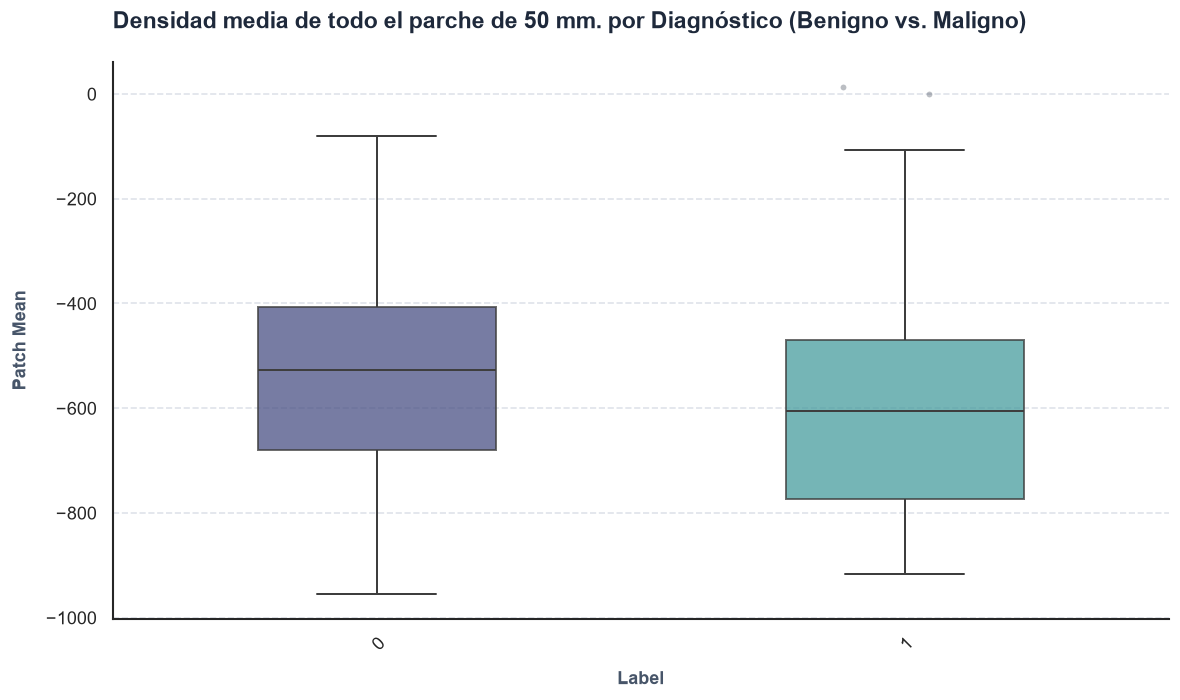

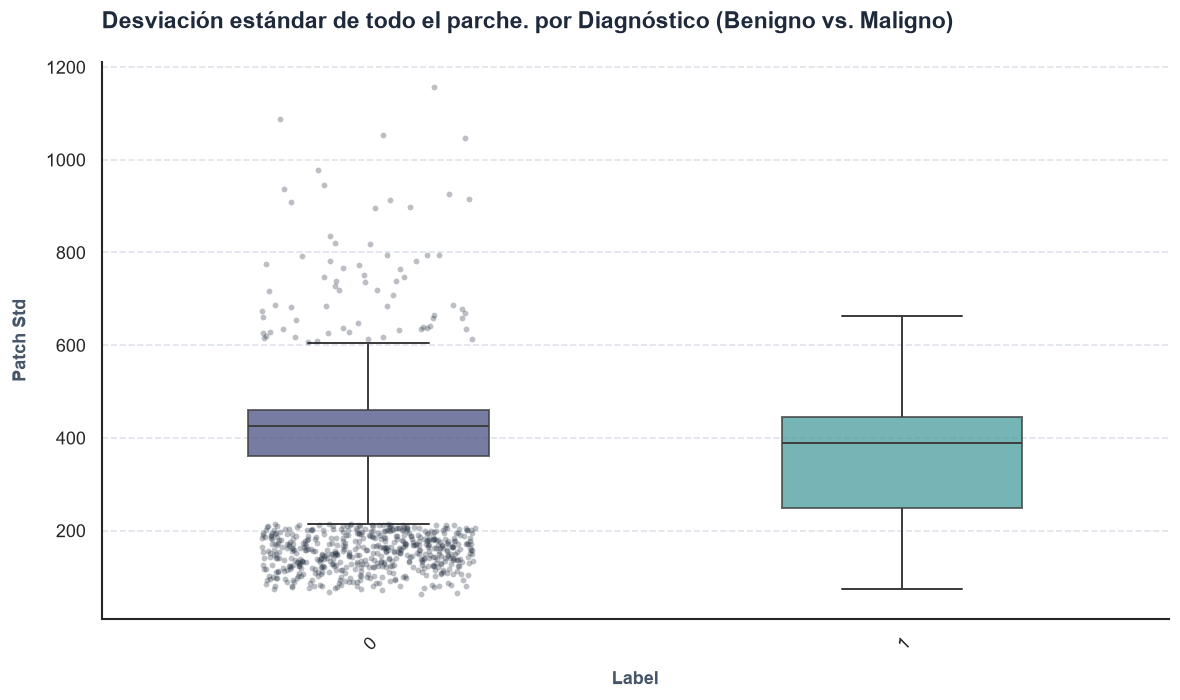

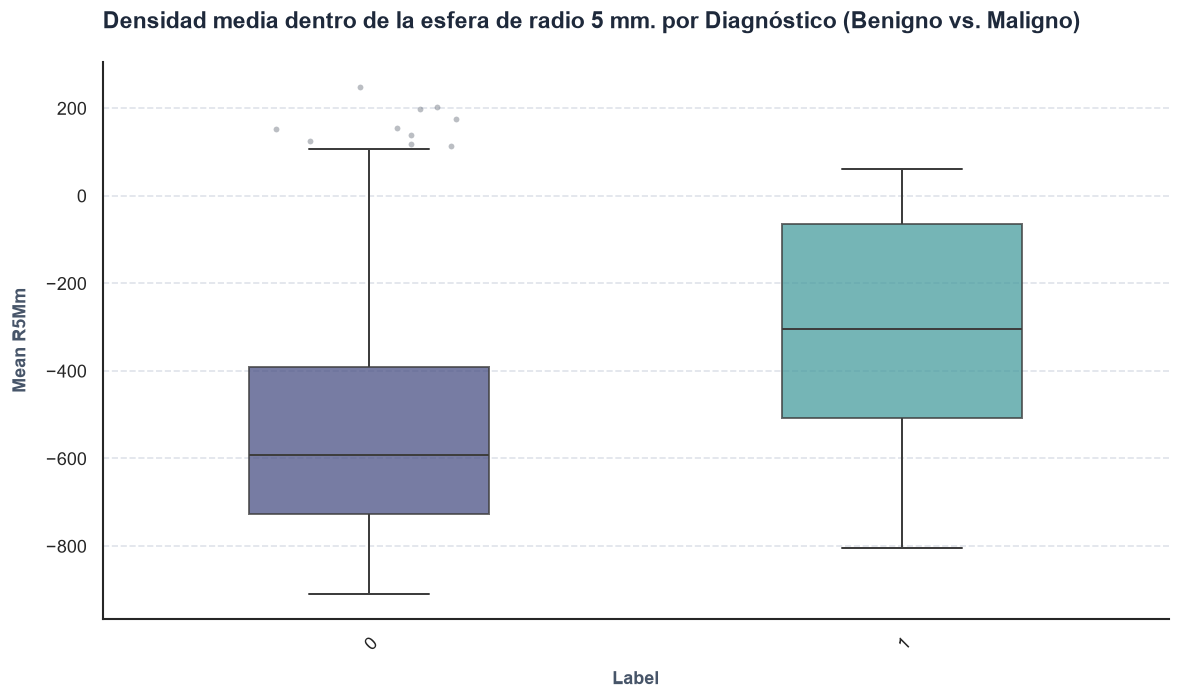

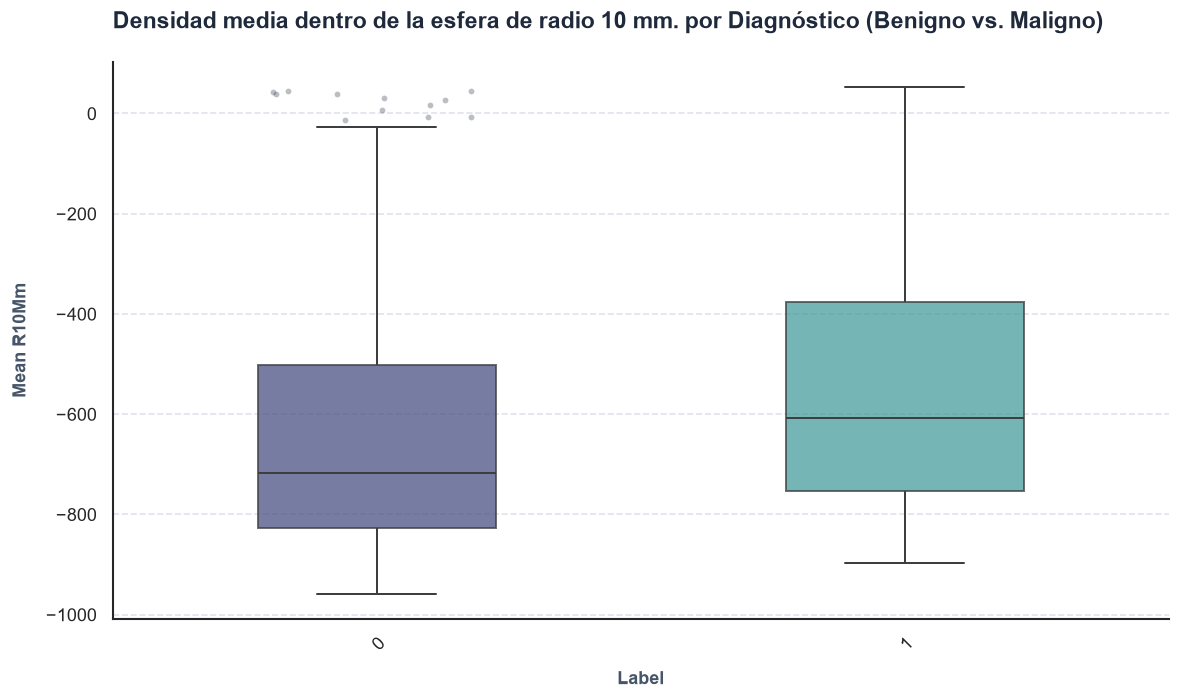

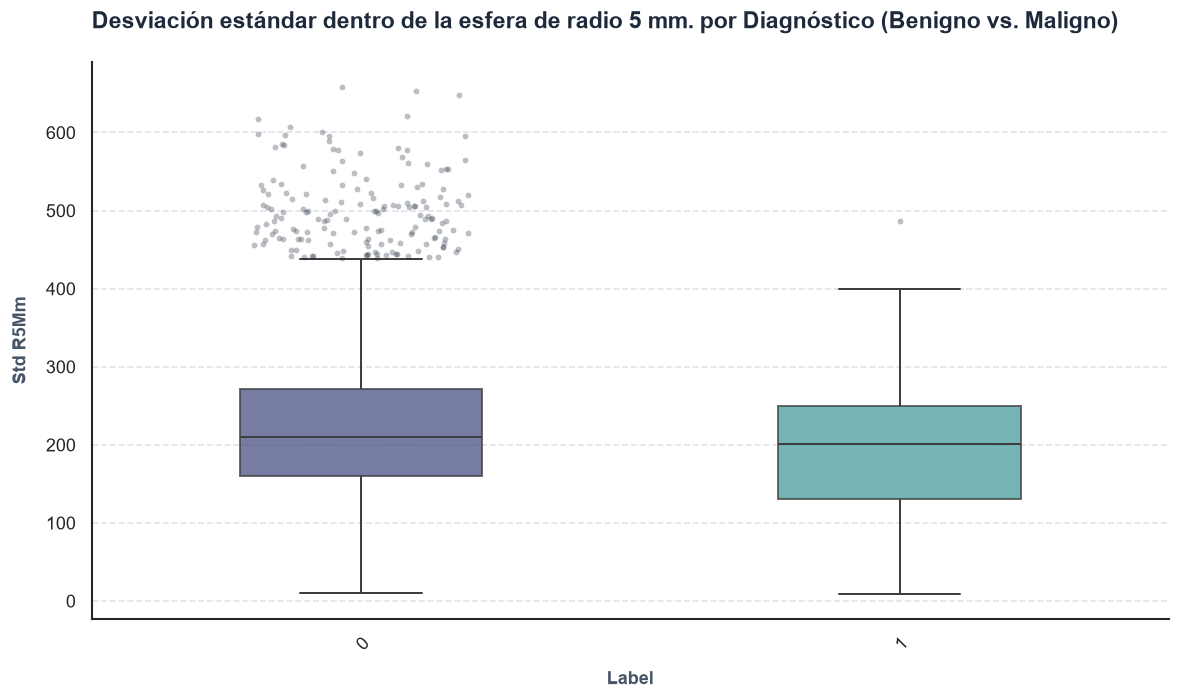

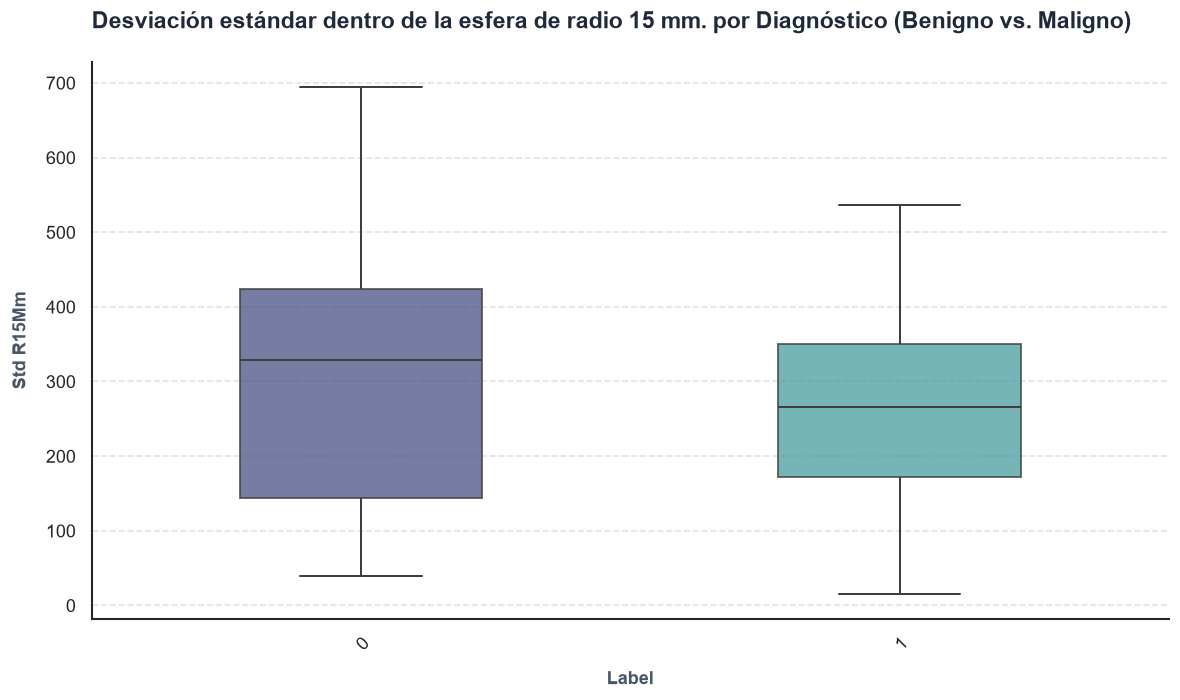

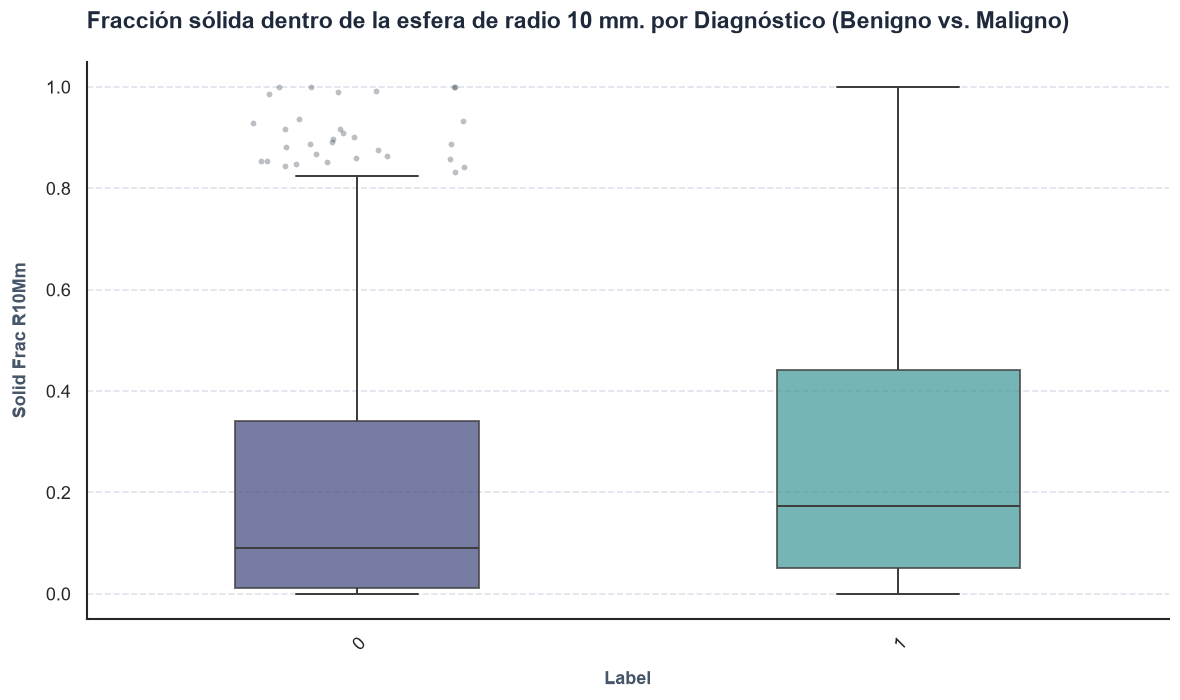

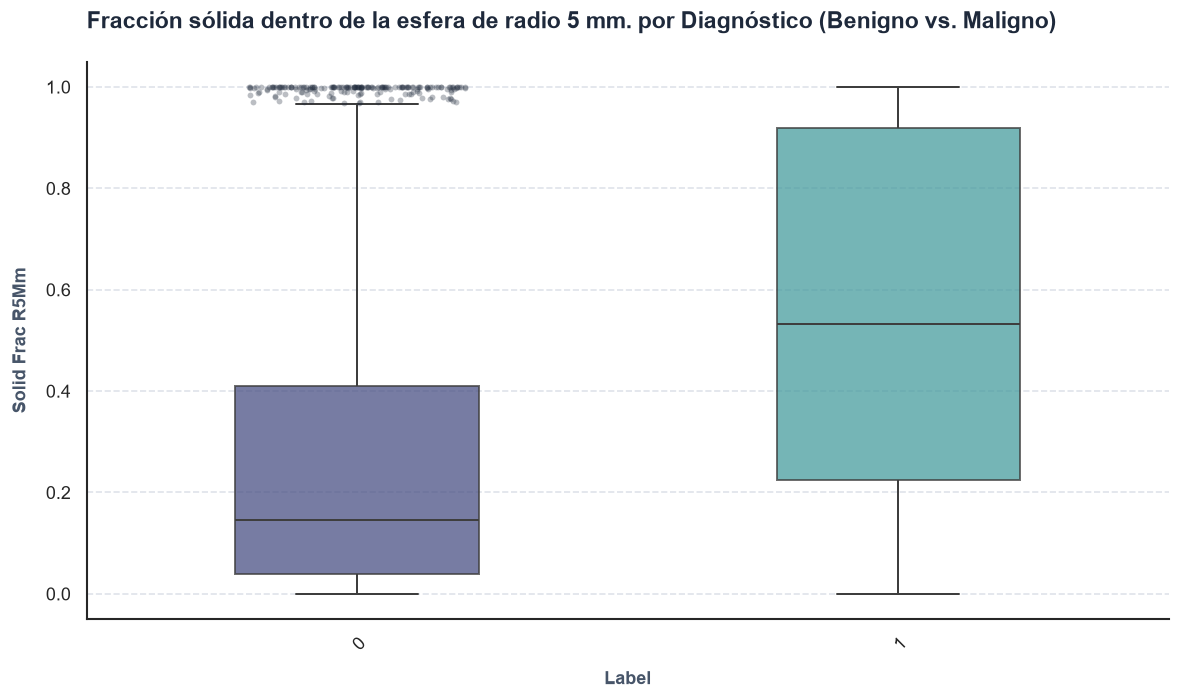

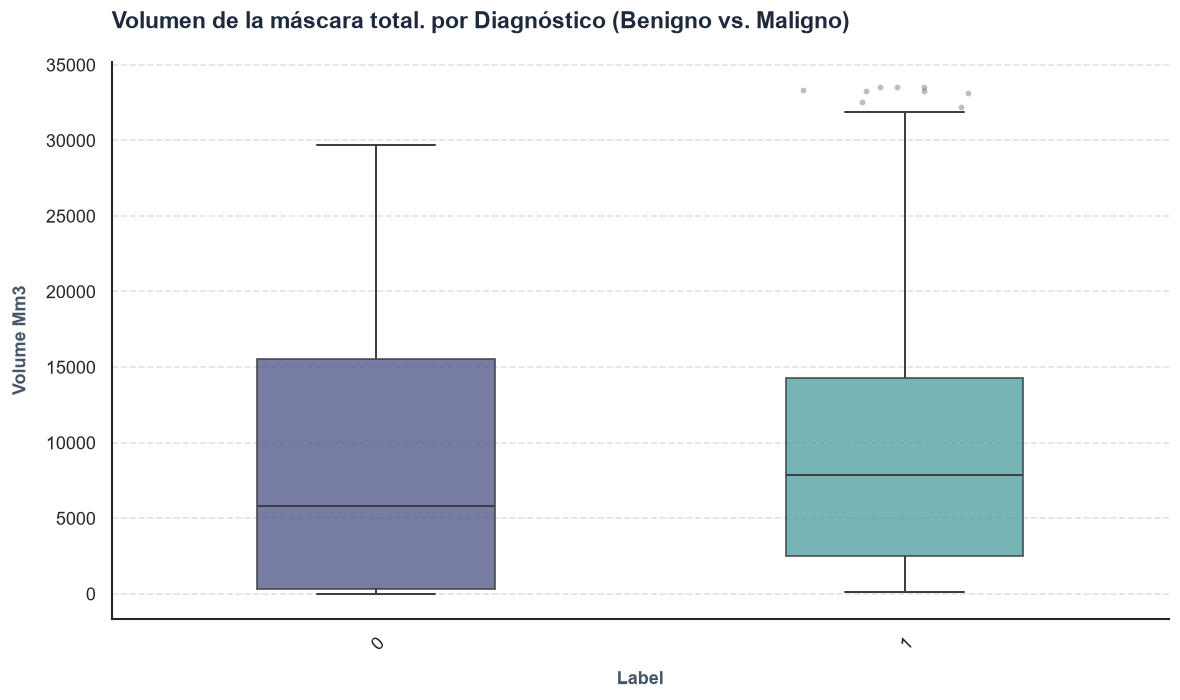

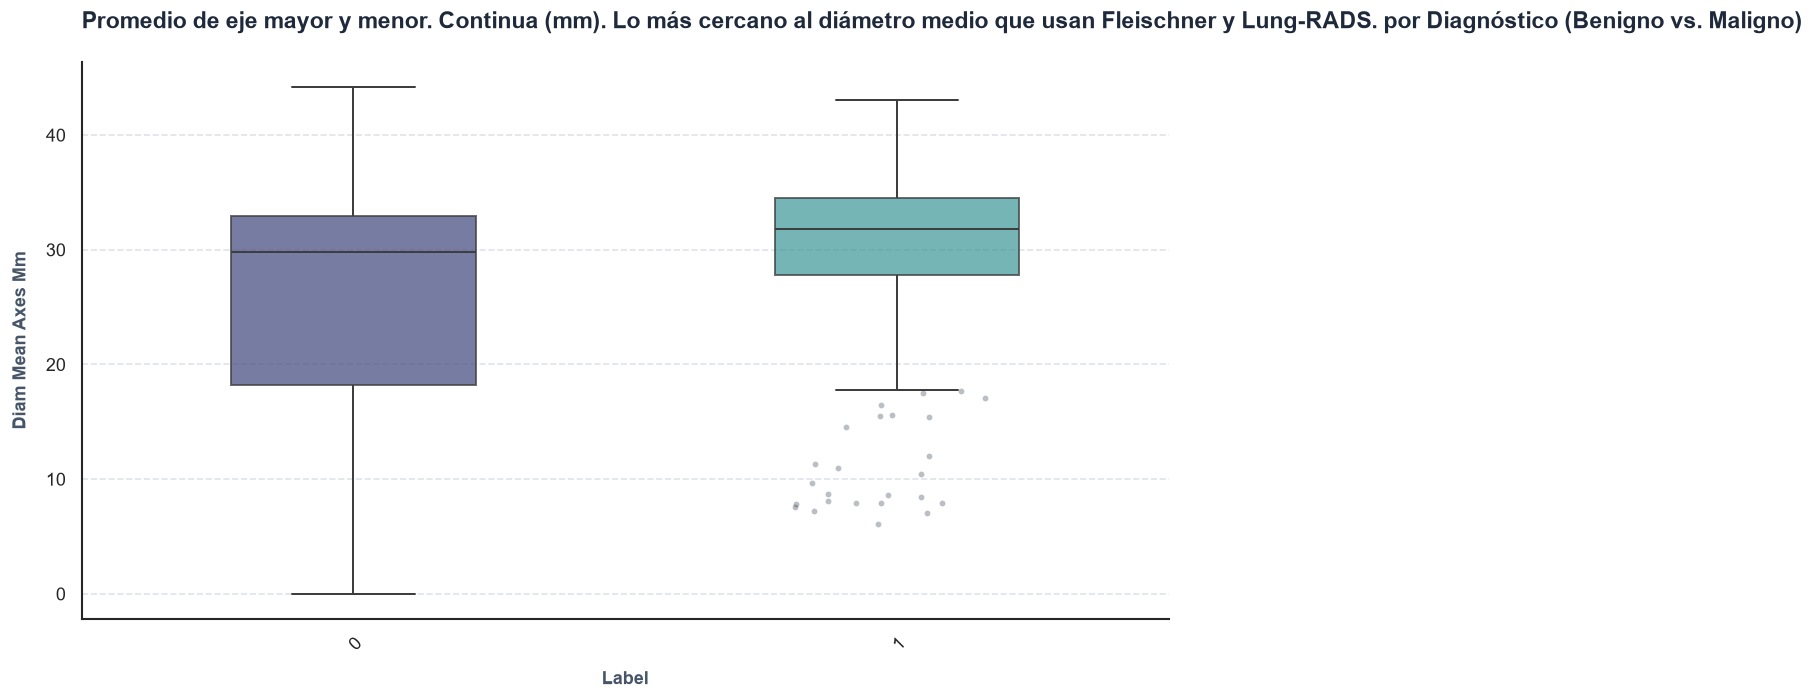

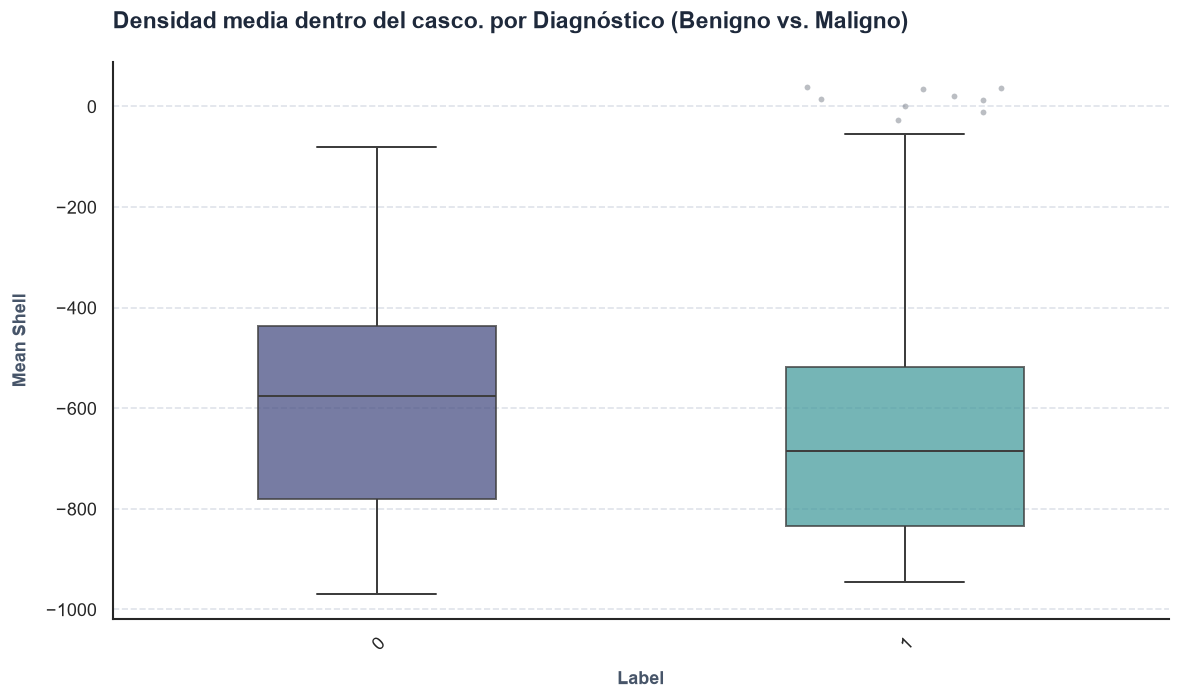

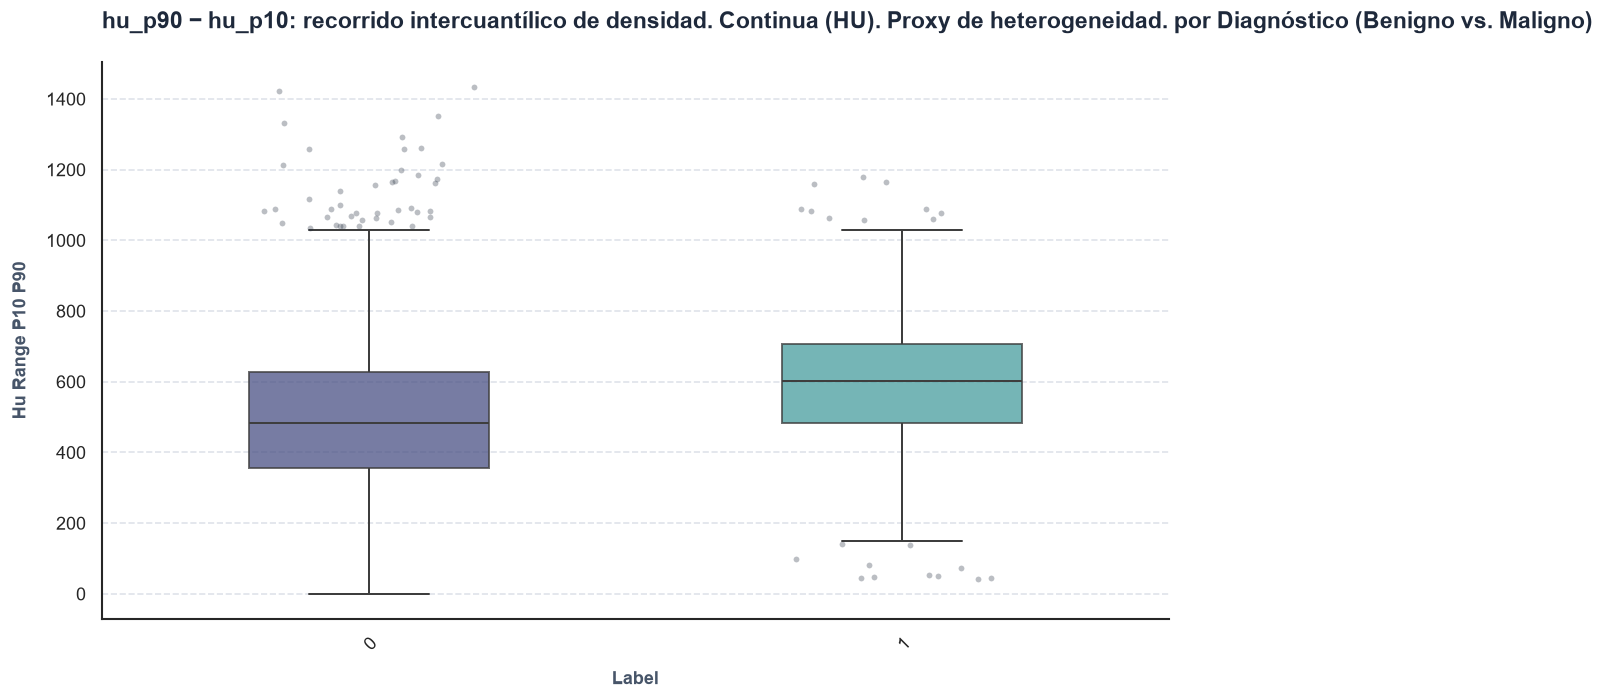

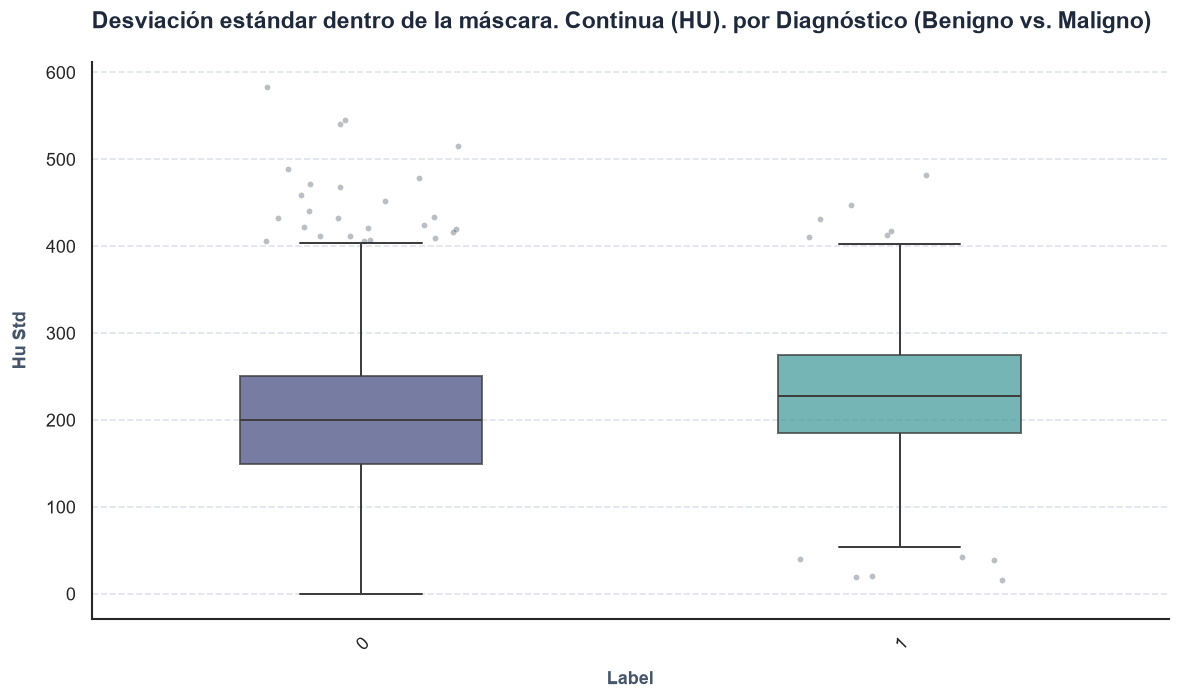

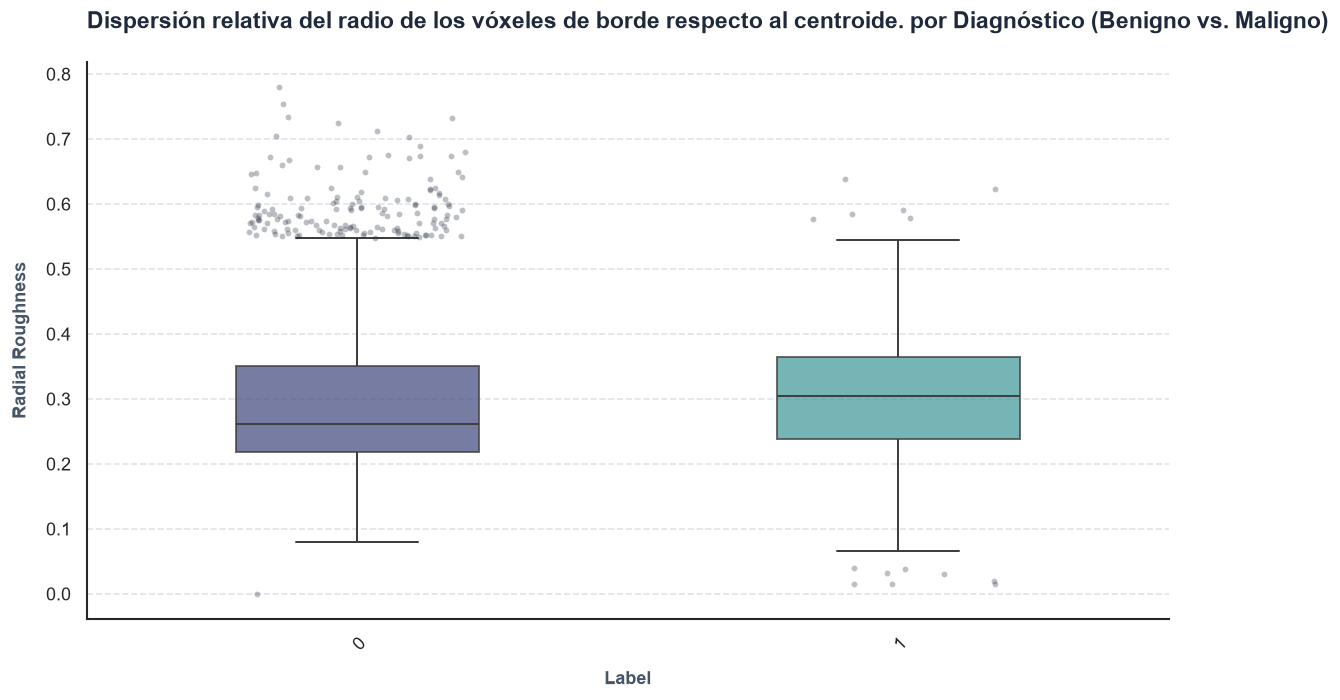

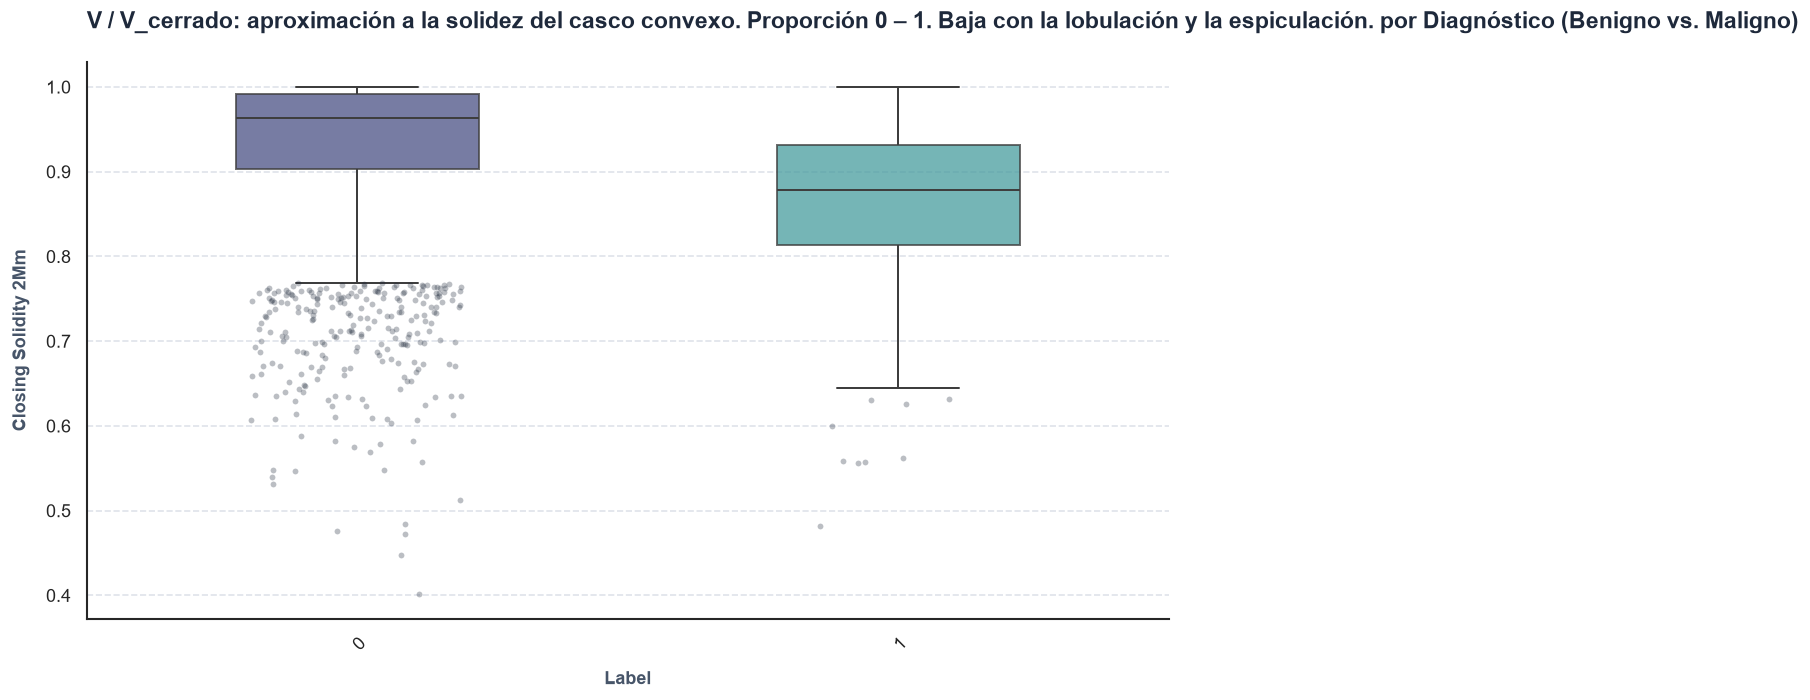

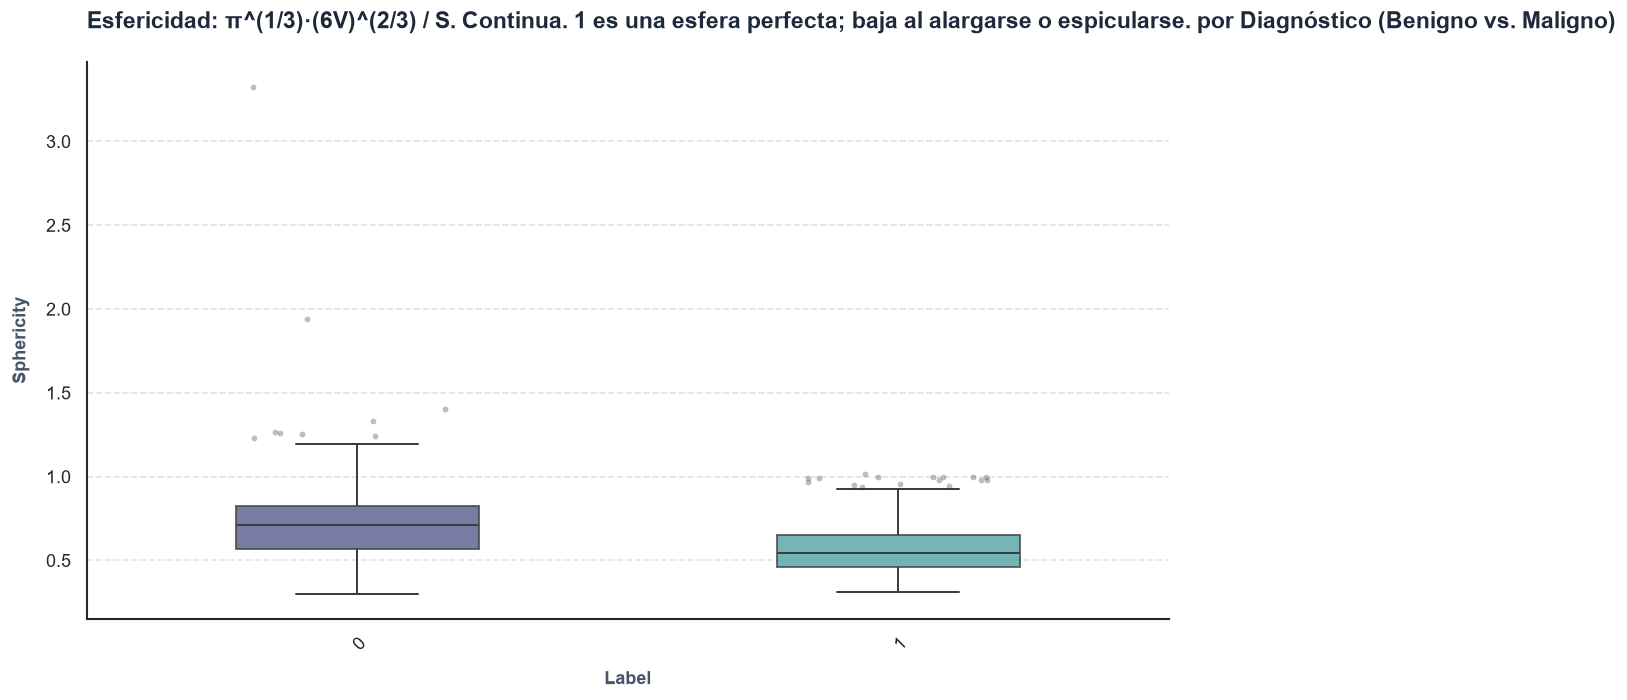

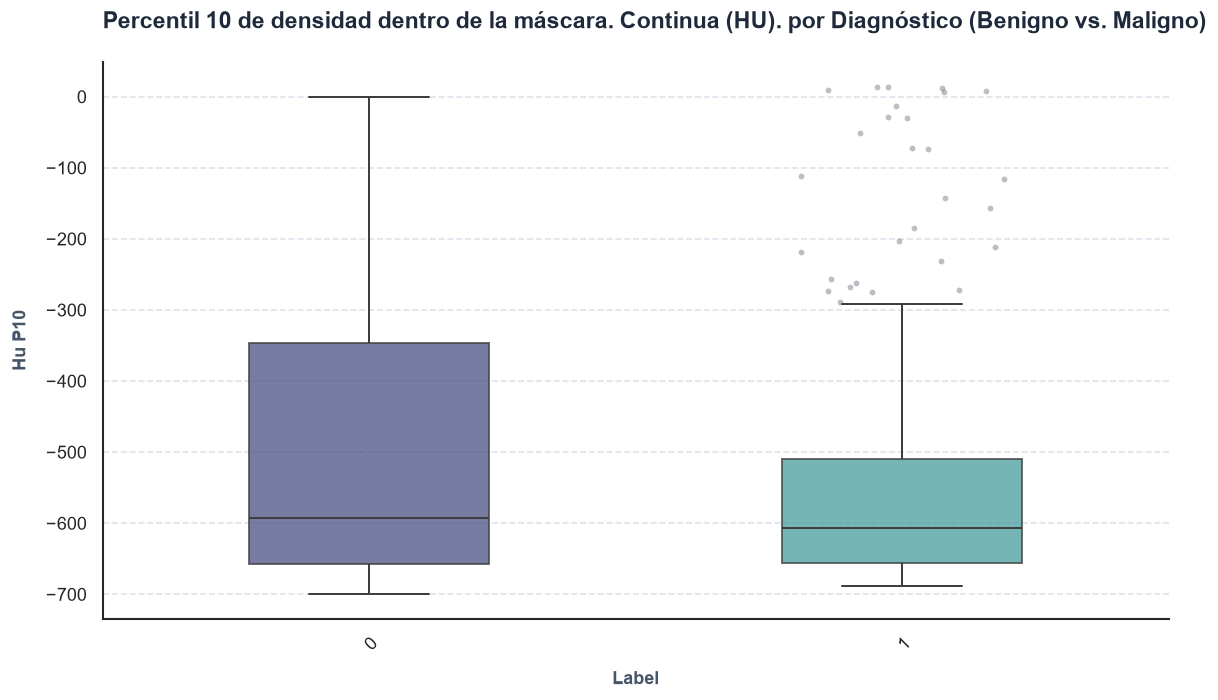

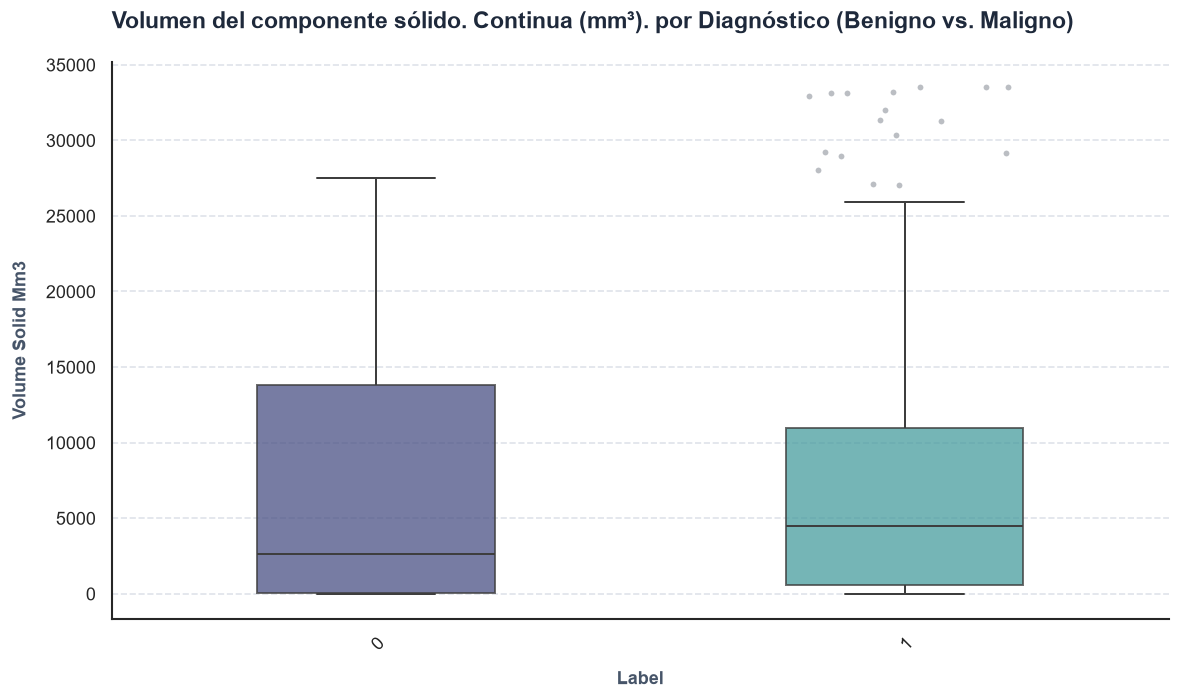

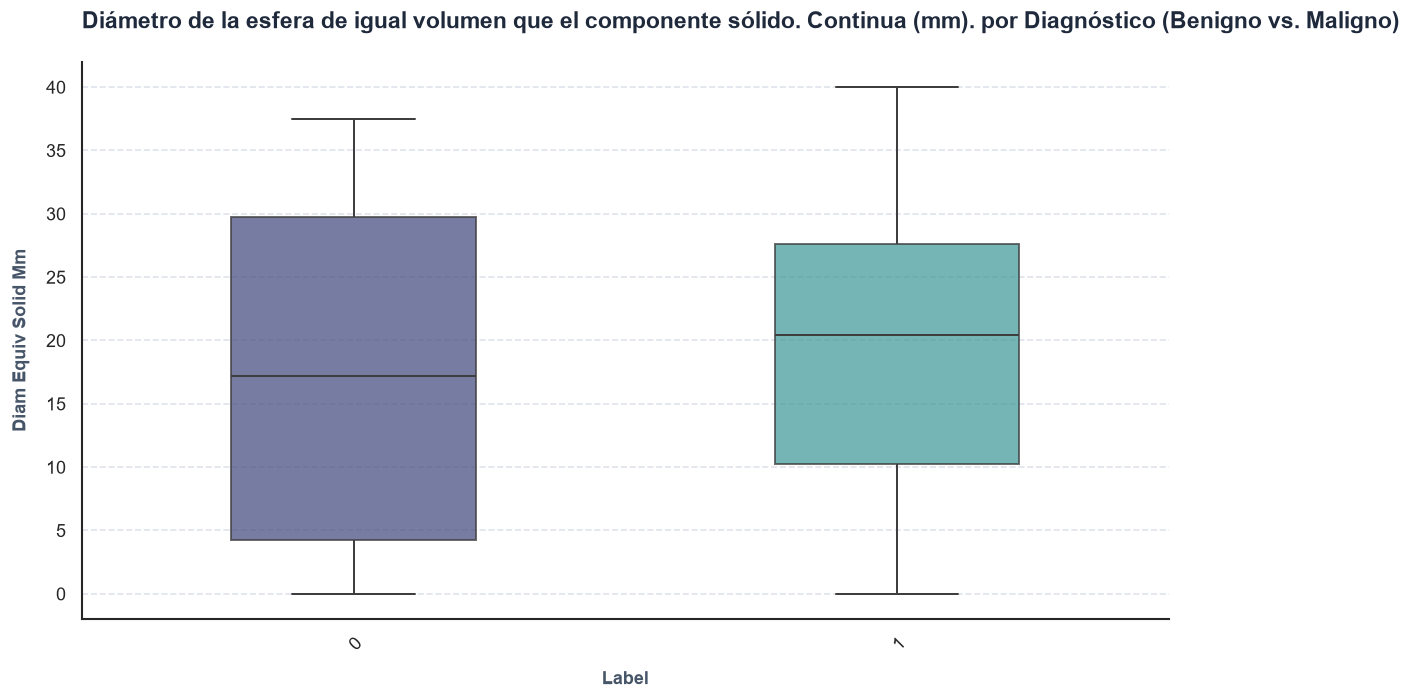

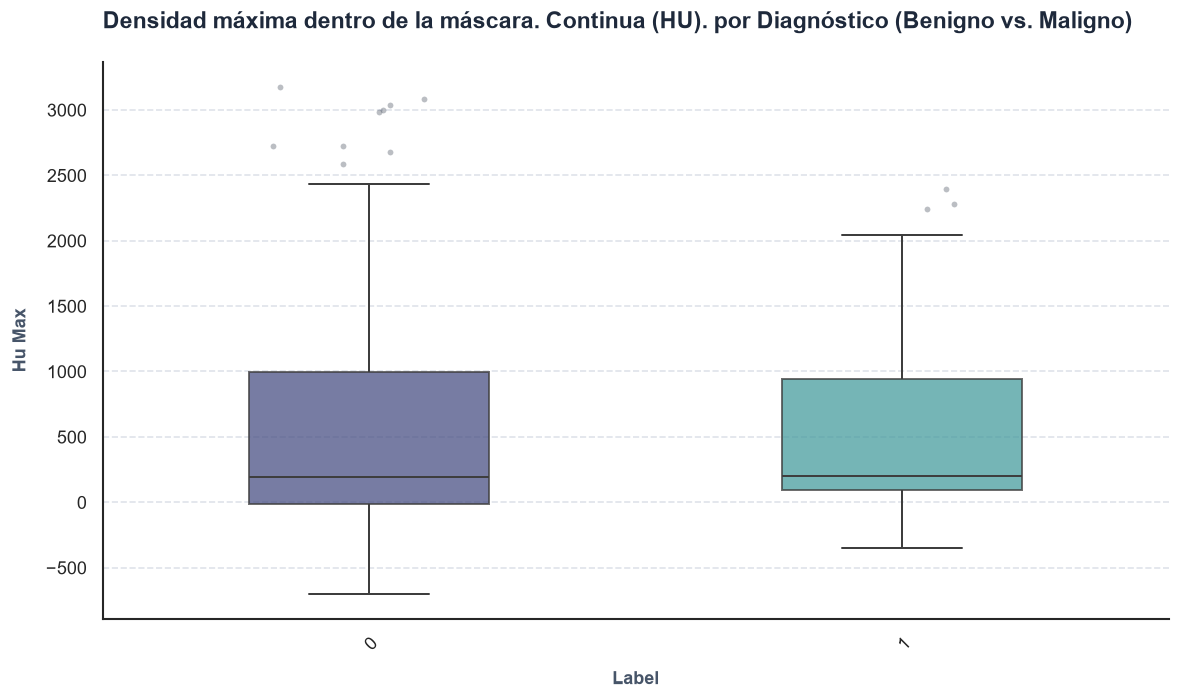

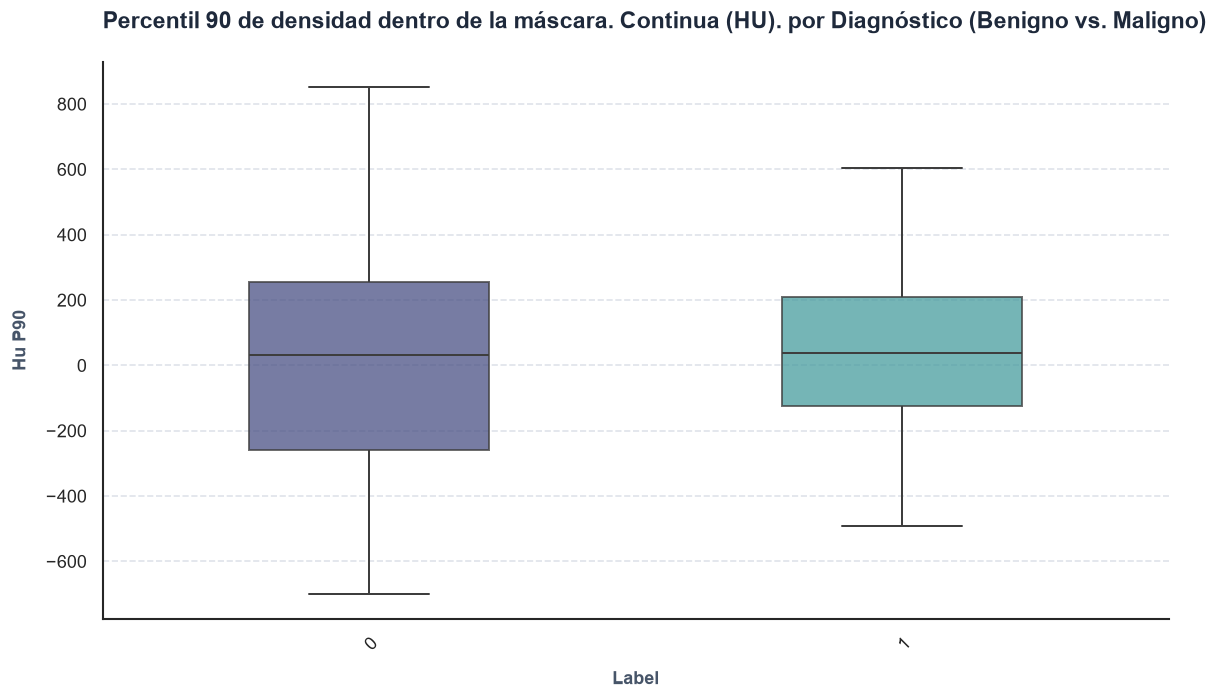

In [211]:
sig_cols = hypotesis_test[hypotesis_test["decision"] == "Se rechaza H0"][
    "feature"
].tolist()
for col in sig_cols:
    plot_segmented_boxplot(
        analisis_imagenes,
        cat_col="label",
        num_col=col,
        show_points=True,
        title=f"{interesting_cols.get(col, col)} por Diagnóstico (Benigno vs. Maligno)",  #  noqa: E501
    )

Tanto las pruebas de hipótesis como la evidencia gráfica respaldan que los parámetros médicos utilizados como indicadores de malignidad son consistentes. Las pruebas de hipótesis mostraron diferencias estadísticamente significativas entre nódulos benignos y malignos en indicadores de densidad (como la densidad media del parche y la densidad media en las esferas de delimitación), también lo hicieron métricas de forma como la esfericidad (*sphericity*, cuya gráfica muestra valores claramente menores en el grupo maligno) y la solidez de cierre (`closing_solidity_2mm`), y por último confirmaron capacidad discriminatoria en múltiples métricas de tamaño como el volumen del nódulo y el diámetro promedio de los ejes mayor y menor (métrica similar a la recomendada por el manual Lung-RADS).

Aunque todas las pruebas rechazaron $H_0$, los resultados de la prueba U de Mann-Whitney deben interpretarse con precaución debido al fuerte desbalance de clases ($5596$ vs. $555$, si bien esto no invalida la prueba pues la muestra es lo suficientemente grande si se afecta la representatividad de la poblacion que tiene el grupo minoritario). Al respaldar la evidencia estadística con diagramas de caja para evitar reportar variables cuya varianza sea extrema en la clase minoritaria, las variables más robustas para discriminar los grupos resultaron ser:

- **Densidad media del parche de 50 mm:** Muestra una clara densidad menor en los nódulos malignos.
- **Densidad media dentro de la esfera de radio 5 mm:** Muestra que si bien los parches malignos son menos densos, el centro de los nódulos malignos es en promedio más denso.
- **Volumen de la máscara del nódulo:** La clase maligna muestra menor variabilidad (IQR más estrecho) y valores consistentemente más altos, lo que indica mayor volumen en tumores malignos.
- **Promedio de los ejes mayor y menor:** Los nódulos malignos presentan diámetros promedio significativamente mayores.
- **Esfericidad (*sphericity*):** Menor en el grupo maligno, lo cual concuerda con la presencia de bordes espiculados o irregulares.
- **Solidez de cierre (`closing_solidity_2mm` = $V / V_{\text{cerrado}}$):** Menor solidez en nódulos malignos, actuando como un indicador indirecto de mayor espiculación (mide irregularidad o concavidades superficiales).

In [ ]:
# Explorador interactivo de la máscara de un nódulo.
# Reproduce para UN nódulo el mismo camino que nodule_morphometry: parche
# isótropo de 80^3 a 0.625 mm y segmentación por umbral local.
import domain_utils.medical_criteria as mc

aid = "100570_1_19990102"  # cambia el AnnotationID para ver otro nódulo

df_nodulo = pd.read_csv(config.LUNA25_LABELS)
df_nodulo = df_nodulo[df_nodulo["AnnotationID"] == aid].reset_index(drop=True)
assert len(df_nodulo) == 1, f"AnnotationID {aid!r} no está en el CSV"

device = get_device()
loader_nodulo = build_dataloader(
    config.NODULE_BLOCKS_ROOT,
    df_nodulo,
    batch_size=1,
    num_workers=0,
    device=device,
    expected_shape=mc.BLOCK_SHAPE,
)
extractor_seg = PatchExtractor(
    size_px=mc.SEG_SIZE_PX,
    size_mm=mc.SEG_SIZE_MM,
    mode="3D",
    padding_mode="border",
).to(device)

# rejilla de distancias radiales en mm, igual que en nodule_morphometry
vs = mc.SEG_SIZE_MM / mc.SEG_SIZE_PX
ax_mm = (
    torch.arange(mc.SEG_SIZE_PX, device=device, dtype=torch.float32)
    - (mc.SEG_SIZE_PX - 1) / 2
) * vs
rr = torch.stack(torch.meshgrid(ax_mm, ax_mm, ax_mm, indexing="ij"), -1)
rr = rr.norm(dim=-1)

batch_nodulo = next(iter(loader_nodulo)).to(device)
with torch.no_grad():
    patch = extractor_seg(
        batch_nodulo.image,
        batch_nodulo.spacing,
        batch_nodulo.transform,
        batch_nodulo.center_vox,
    )
    hu = patch[:, 0]  # (1, 80, 80, 80) en HU
    total, solid, bg, thr, converged, leak, empty = mc.segment_nodule(
        hu, rr, vs
    )

print(
    f"{aid}: {int(total.sum())} vóxeles, fuga {float(leak[0]):.1%}, "
    f"fondo {float(bg[0]):.0f} HU, umbral {float(thr[0]):.0f} HU"
)
explore_mask(hu, total, spacing=vs, solid_mask=solid, title=f"Nódulo {aid}")

100570_1_19990102: 65274 vóxeles, fuga 9.4%, fondo -908 HU, umbral -700 HU


# Seleccion caracteristicas

In [213]:
analisis_imagenes.shape

(6151, 61)

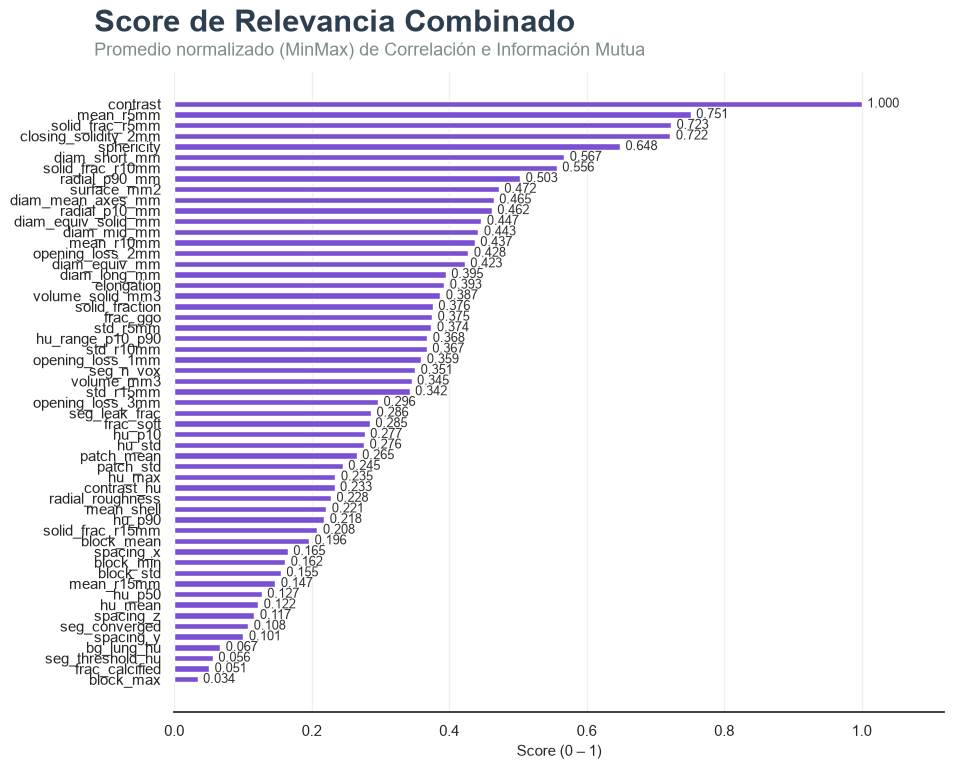

In [ ]:
df_score = analizar_relevancia_caracteristicas(
    analisis_imagenes.drop(
        columns=['seg_ok', 'frac_air', 'AnnotationID', 'seg_seed_forced', 'PatientID']
        ),
    target="label"
    )

In [215]:
analisis_imagenes['label'] # esta sera la variable de respuesta.

0       1
1       1
2       1
3       1
4       1
       ..
6158    0
6159    0
6160    0
6161    0
6162    0
Name: label, Length: 6151, dtype: int64

In [220]:
feature_cols = analisis_imagenes.columns.to_list()
feature_cols.remove('label')

In [221]:
vif_resume = vif_table(
    analisis_imagenes,
    'label',
    feature_cols,
    config.PICKLE_DIR / "vif_excec.pkl"
)

d:\Externado\Cuarto semestre\Health tech\health_tech_lung_cancer\utils\vif_resume.py:162: UserWarning: The design matrix is poorly conditioned (condition number=1.40e+16). VIF calculations may be numerically unstable.
  variance_inflation_factor(valores, i) for i in range(x.shape[1])


Aviso: 3 columna(s) de varianza cero, sin VIF definido: seg_seed_forced, frac_air, seg_ok
Aviso: la matriz de diseño tiene rango 54 de 57: 3 columna(s) son combinación lineal exacta de otras. Los VIF enormes son ruido numérico, no una medida de colinealidad. Empieza por revisar: spacing_x, spacing_y, frac_ggo, contrast, mean_r5mm


In [222]:
vif_resume

,Variable,VIF,descartada,alto
0,spacing_x,1.000800e+15,None,True
1,spacing_y,1.000800e+15,None,True
2,frac_ggo,2.573486e+14,None,True
3,contrast,2.094698e+14,None,True
4,mean_r5mm,1.876500e+14,None,True
5,hu_p90,1.801440e+14,None,True
6,hu_mean,9.790434e+13,None,True
7,contrast_hu,9.191020e+13,None,True
8,hu_range_p10_p90,8.339999e+13,None,True
9,diam_long_mm,3.491163e+13,None,True


Dado que muchas de las variables dan la misma informacion pero en otras unidades (muchas son solo combinaciones lineales), se utillizo la informacion mutua y la correlacion con la label, esto con el fin de determinar cuales son las mejores variables para alimentar la regresion logistica.

Se usa regresion logistica y no regresion lineal dado que el problema es de naturaleza clasificatoria, es decir una regresion lineal no seria capaz de dar las labels, solo numeros estimados, la logistica si da la salida deseada.

Dicho esto las variables seleccionadas con dicho criterio y basandonos en que cada una represente un indicador clave son:

* contrast (mean_r5mm − mean_shell: realce del núcleo sobre su entorno.)
* sphericity (Esfericidad: π^(1/3)·(6V)^(2/3) / S)
* diam_short_mm (diametro del eje menor del elipsoide equivalente)


In [231]:
final_df = analisis_imagenes[['contrast', 'sphericity', 'diam_short_mm', 'label']]

In [233]:
feature_cols = ['contrast', 'sphericity', 'diam_short_mm']

In [232]:
final_df

,contrast,sphericity,diam_short_mm,label
0,719.735500,0.533696,27.394093,1
1,609.496800,0.516463,17.651148,1
2,814.827900,0.501234,21.181112,1
3,124.272950,0.511245,26.756090,1
4,796.625900,0.476908,18.257704,1
...,...,...,...,...
6158,-222.343750,0.541446,9.613651,0
6159,-61.328033,0.815469,24.418835,0
6160,-144.203800,0.811841,23.848475,0
6161,-49.792510,0.827260,21.269580,0


In [234]:
vif_resume_final = vif_table(
    final_df,
    'label',
    feature_cols,
    config.PICKLE_DIR / "vif_excec_final.pkl"
)

In [235]:
vif_resume_final

,Variable,VIF,descartada,alto
0,sphericity,1.651057,None,False
1,diam_short_mm,1.384175,None,False
2,contrast,1.249872,None,False


# Modelos Base Line

In [247]:
X_final = final_df.drop(columns="label")
y_final = final_df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)


def reporte_modelo(modelo, columnas, nombre):
    """Ajusta en train y reporta sobre test."""
    modelo.fit(X_train[columnas], y_train)
    pred = modelo.predict(X_test[columnas])
    proba = modelo.predict_proba(X_test[columnas])

    # R2 de McFadden: 1 - LL(modelo) / LL(modelo nulo). El modelo nulo
    # predice la tasa base del TRAIN, para no mirar el test al construir
    # la referencia.
    ll_modelo = -log_loss(y_test, proba, normalize=False)
    base = np.full(len(y_test), y_train.mean())
    ll_nulo = -log_loss(y_test, np.c_[1 - base, base], normalize=False)

    # AUC sobre la probabilidad de la clase 1, no sobre la prediccion
    auc = roc_auc_score(y_test, proba[:, 1])

    print(
        f"{nombre}   R2 McFadden = {1 - ll_modelo / ll_nulo:.4f}"
        f"   AUC = {auc:.4f}"
    )
    print(classification_report(y_test, pred, zero_division=0))
    print(
        pd.DataFrame(
            confusion_matrix(y_test, pred),
            index=["real 0", "real 1"],
            columns=["pred 0", "pred 1"],
        )
    )
    return modelo

In [248]:
modelo_dummy = reporte_modelo(
    DummyClassifier(), list(X_final.columns), "dummy_classifier"
)

dummy_classifier   R2 McFadden = 0.0000   AUC = 0.5000
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1120
           1       0.00      0.00      0.00       111

    accuracy                           0.91      1231
   macro avg       0.45      0.50      0.48      1231
weighted avg       0.83      0.91      0.87      1231

        pred 0  pred 1
real 0    1120       0
real 1     111       0


In [249]:
modelo_contrast = reporte_modelo(
    LogisticRegression(), ["contrast"], "contrast"
)

contrast   R2 McFadden = 0.1376   AUC = 0.7880
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1120
           1       0.38      0.05      0.08       111

    accuracy                           0.91      1231
   macro avg       0.65      0.52      0.52      1231
weighted avg       0.87      0.91      0.87      1231

        pred 0  pred 1
real 0    1112       8
real 1     106       5


In [250]:
modelo_sphericity = reporte_modelo(
    LogisticRegression(), ["sphericity"], "sphericity"
)

sphericity   R2 McFadden = 0.1017   AUC = 0.7498
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1120
           1       0.00      0.00      0.00       111

    accuracy                           0.91      1231
   macro avg       0.45      0.50      0.48      1231
weighted avg       0.83      0.91      0.87      1231

        pred 0  pred 1
real 0    1120       0
real 1     111       0


In [251]:
modelo_diam = reporte_modelo(
    LogisticRegression(), ["diam_short_mm"], "diam_short_mm"
)

diam_short_mm   R2 McFadden = 0.0584   AUC = 0.6877
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      1120
           1       0.00      0.00      0.00       111

    accuracy                           0.91      1231
   macro avg       0.45      0.50      0.48      1231
weighted avg       0.83      0.91      0.87      1231

        pred 0  pred 1
real 0    1120       0
real 1     111       0


In [252]:
modelo_completo = reporte_modelo(
    LogisticRegression(), list(X_final.columns), "todas las variables"
)

todas las variables   R2 McFadden = 0.1794   AUC = 0.8198
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1120
           1       0.30      0.03      0.05       111

    accuracy                           0.91      1231
   macro avg       0.61      0.51      0.50      1231
weighted avg       0.86      0.91      0.87      1231

        pred 0  pred 1
real 0    1113       7
real 1     108       3


El modelo que se creara posteriormente (la red neuronal) tendra que superar el recall de 0.03 y la precision de 0.30. Si bien el AUC reportado (0.8198) puede parecer muy bueno e incluso cercano al reportado en el paper, es importante recordar que esta metrica se vuelve engañosa es decir esta inflada por el FPR (por el gran volumen de VN siempre parecerá bajo), por lo tanto esta no se tomara en consideración como objetivo para que el modelo supere.

In [259]:
coef_completo = modelo_completo.coef_[0]
desv_train = X_train.std().to_numpy()

# AOR = exp(coeficiente). "Ajustado" porque cada uno se estima con las
# otras variables dentro del modelo. La columna por desviacion estandar
# hace comparables entre si variables con unidades muy distintas.
aor_completo = pd.DataFrame(
    {
        "variable": X_final.columns,
        "coeficiente": coef_completo,
        "AOR": np.exp(coef_completo),
    }
).sort_values("AOR", ascending=False).reset_index(drop=True)

aor_completo.round(4)

,variable,coeficiente,AOR
0,diam_short_mm,0.0495,1.0507
1,contrast,0.0034,1.0034
2,sphericity,-1.3736,0.2532


Los coeficientes ($\beta$) representan el cambio en el logit (log-odds) de que un nódulo sea maligno por cada incremento unitario en la variable, manteniendo las demás constantes. El **AOR** (Adjusted Odds Ratio, $e^{\beta}$) cuantifica la variación proporcional en la razón de probabilidades (*odds*) de malignidad.

* **`diam_short_mm` ($\beta = 0.0495$, $\text{AOR} = 1.0507$):**
  * **Interpretación:** Por cada milímetro adicional en el diámetro corto del nódulo, la probabilidad relativa (*odds*) de que sea maligno se incrementa en un **5.07%** ($\text{AOR} - 1 = 0.0507$), manteniendo fijas las demás variables radiómicas. Funciona como un factor de riesgo.

* **`contrast` ($\beta = 0.0034$, $\text{AOR} = 1.0034$):**
  * **Interpretación:** Por cada unidad que aumenta el contraste, las *odds* de malignidad aumentan un **0.34%**. El efecto directo es leve por unidad, manteniendo fijas las demás variables radiómicas.

* **`sphericity` ($\beta = -1.3736$, $\text{AOR} = 0.2532$):**
  * **Interpretación:** Un mayor grado de esfericidad actúa como un factor protector. Por cada incremento de 1 unidad en la esfericidad (de 0 a 1), las *odds* de que el nódulo sea maligno se reducen un **74.68%** ($1 - 0.2532 = 0.7468$). Es decir, un nódulo más esférico tiene solo el **25.32%** de la probabilidad relativa de ser maligno en comparación con uno menos esférico (los nódulos malignos tienden a presentar formas irregulares o espiculadas), manteniendo fijas las demás variables radiómicas.

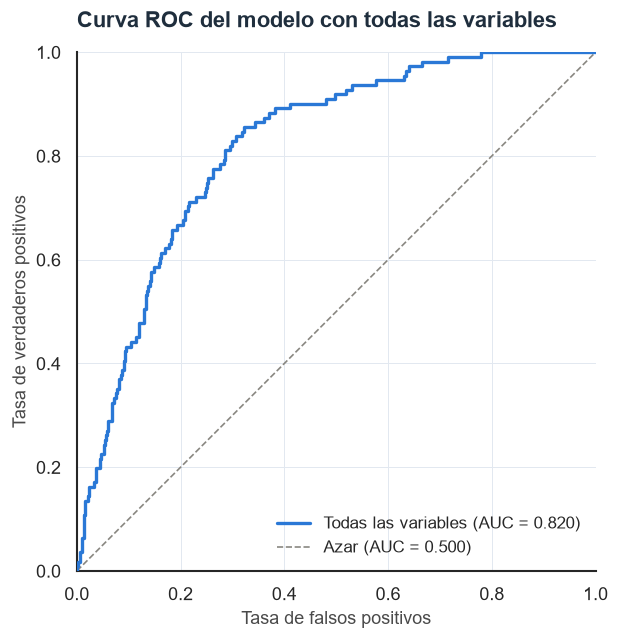

In [254]:
proba_completo = modelo_completo.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_completo)
auc_completo = roc_auc_score(y_test, proba_completo)

fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=120)
ax.plot(
    fpr,
    tpr,
    color="#2a78d6",
    lw=2,
    zorder=3,
    label=f"Todas las variables (AUC = {auc_completo:.3f})",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="#898781",
    lw=1,
    ls="--",
    zorder=2,
    label="Azar (AUC = 0.500)",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel("Tasa de falsos positivos", fontsize=11, color="#4A4A4A")
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=11, color="#4A4A4A")
ax.set_title(
    "Curva ROC del modelo con todas las variables",
    fontsize=13,
    color="#1F2E3D",
    fontweight="bold",
    loc="left",
    pad=15,
)
ax.grid(True, color="#E2E8F0", lw=0.6)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

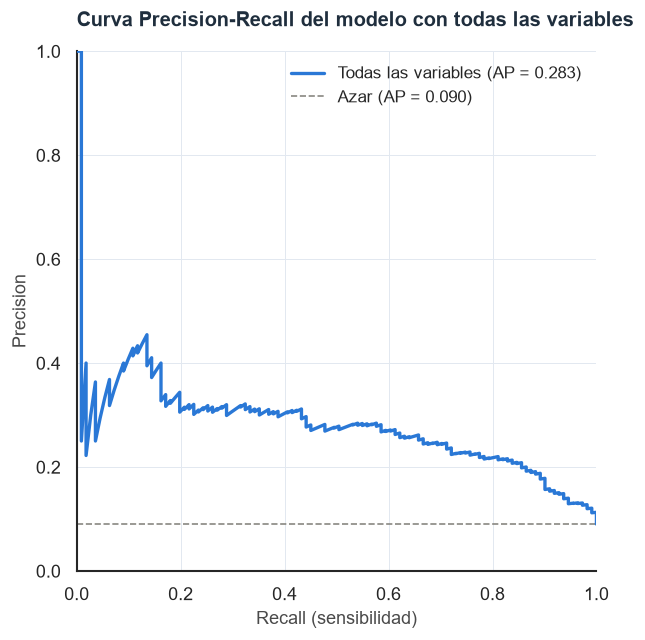

In [257]:
precision, recall, _ = precision_recall_curve(y_test, proba_completo)
ap_completo = average_precision_score(y_test, proba_completo)
tasa_base = y_test.mean()

fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=120)
ax.plot(
    recall,
    precision,
    color="#2a78d6",
    lw=2,
    zorder=3,
    label=f"Todas las variables (AP = {ap_completo:.3f})",
)
ax.axhline(
    tasa_base,
    color="#898781",
    lw=1,
    ls="--",
    zorder=2,
    label=f"Azar (AP = {tasa_base:.3f})",
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_xlabel("Recall (sensibilidad)", fontsize=11, color="#4A4A4A")
ax.set_ylabel("Precision", fontsize=11, color="#4A4A4A")
ax.set_title(
    "Curva Precision-Recall del modelo con todas las variables",
    fontsize=12,
    color="#1F2E3D",
    fontweight="bold",
    loc="left",
    pad=15,
)
ax.grid(True, color="#E2E8F0", lw=0.6)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(loc="upper right", frameon=False, fontsize=10)
plt.tight_layout()
plt.show()